### 셀 → .py 모듈 등록 코드

In [ ]:
# === 셀 매직 정의: 각 셀을 실제 모듈로 등록한다 ===
# 사용법: 셀 첫 줄에 `%%module <모듈명> <src 기준 경로>`.
# 셀을 수정하고 재실행하면 sys.modules 가 교체되므로,
# 그 모듈을 import 하는 하위 셀들을 다시 실행하면 수정본이 반영된다.
import json as _json
import sys as _sys
import types as _types
from pathlib import Path

from IPython.core.magic import register_cell_magic

REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
# NB_PATH = REPO_ROOT / "test" / "src_all_in_one.ipynb"


@register_cell_magic("module")
def _module_magic(line, cell):
    """
    %%module <모듈명> <src 기준 경로>
    셀 내용을 실제 Python 모듈처럼 등록
    예) ㅈㅏ회
    %%module agent.nodes agent/nodes.py
    VALUE = 10
    def hello():
        return VALUE

    from agent.nodes import hello
    hello()  # 10
    
    """
    name, relpath = line.split()

    # 실제 파일을 import하는 대신 메모리상 모듈 객체 생성
    mod = _types.ModuleType(name)
    mod.__file__ = str(REPO_ROOT / "src" / relpath) # 실제 소스 파일이 있을 것으로 간주하는 경로
    _sys.modules[name] = mod

    # 부모 패키지 등록 (agent.nodes -> agent)
    ## 파일 시스템에 실제 __init__.py가 없어도 namespace package처럼 동작하도록 구성
    parts = name.split(".")
    for i in range(1, len(parts)):
        pkg = ".".join(parts[:i])
        parent = _sys.modules.setdefault(pkg, _types.ModuleType(pkg))
        setattr(parent, parts[i], _sys.modules.get(name) if i == len(parts) - 1 else _sys.modules.setdefault(".".join(parts[:i + 1]), _types.ModuleType(".".join(parts[:i + 1]))))
    
    # 셀 코드 실행
    ##  셀 문자열을 Python 코드로 컴파일한 뒤, 새로 만든 모듈의 namespace에서 실행
    ##  셀 안에서 정의한 변수와 함수가 모두 해당 모듈의 멤버가 됨
    exec(
        compile(cell, mod.__file__, "exec"), 
        mod.__dict__)
    print(f"registered: {name}")



man_path = REPO_ROOT / "artifacts" / "oxigraph" / "manifest.json"
man = _json.loads(man_path.read_text(encoding="utf-8"))
assert man["cutoff"] == "2026-08-24", (
    f"store cutoff={man['cutoff']} — 2026-08-24 재빌드 필요 "
    "(kb.build_graph 의 CUTOFF 를 08-24 로 바꿔 build(); 기존 store 는 백업 후)")
print("store:", f"{man['triple_count']:,} triples, cutoff", man["cutoff"],
      "| excluded_future:", man["excluded_future_nodes"])

store: 1,628,311 triples, cutoff 2026-08-24 | excluded_future: 0


### local DB 연결 설정

In [5]:
### local DB 연결 설정
import psycopg

conn = psycopg.connect(
    host="127.0.0.1",
    port=5432,
    user="postgres",
    password="postgres",
    dbname="mafest",
)

with conn.cursor() as cur:
    cur.execute("SELECT current_database(), version();")
    print("DB 연결확인 :", "\n", cur.fetchone(),"\n")

# conn.close()
# table 확인
with conn.cursor() as cur:
    cur.execute("""
        SELECT table_name
        FROM information_schema.tables
        WHERE table_schema = 'public'
        ORDER BY table_name;
    """)
    print("table 연결확인 :", "\n", [row[0] for row in cur.fetchall()],"\n")

# 데이터와 벡터 컬럼을 확인
with conn.cursor() as cur:
    cur.execute("""
        SELECT table_name, column_name, data_type
        FROM information_schema.columns
        WHERE table_name IN ('bond_schema_terms', 'schema_terms_all')
        ORDER BY table_name, ordinal_position;
    """)
    print("데이터와 벡터 컬럼 확인 :", "\n" + "\n".join([row[0] + ", " + row[1] + ", " + row[2] for row in cur.fetchall()]))

DB 연결확인 : 
 ('mafest', 'PostgreSQL 18.6 (Ubuntu 18.6-0ubuntu0.26.04.1) on x86_64-pc-linux-gnu, compiled by gcc (Ubuntu 15.2.0-16ubuntu1) 15.2.0, 64-bit') 

table 연결확인 : 
 ['bond_schema_terms', 'schema_terms_all'] 

데이터와 벡터 컬럼 확인 : 
bond_schema_terms, term_uri, text
bond_schema_terms, label, text
bond_schema_terms, comment, text
bond_schema_terms, alt_labels, ARRAY
bond_schema_terms, content, text
bond_schema_terms, embedding, USER-DEFINED
schema_terms_all, term_uri, text
schema_terms_all, label, text
schema_terms_all, comment, text
schema_terms_all, alt_labels, ARRAY
schema_terms_all, content, text
schema_terms_all, embedding, USER-DEFINED


# Agent Test



### [1. 구현 목표]

- 사용자 질문을 온톨로지 구조에 맞는 SPARQL로 변환하고, 실행 전에 속성·방향·domain/range를 검증한다.
- 예시 질문: 에코프로와 연결된 자회사 관계를 알려줘. 관계 기준일과 출처도 함께 보여줘.
- ETF 수익률·순자산·총보수처럼 정렬이 필요한 수치는 Graph에서 찾은 상품코드를 RDB로 전달해 처리한다.

---

### [2. 전체 실행 구조]

```text
사용자 질문
  ↓
Query Frame 추출
  - task, entity, relation, ordering 분리
  ↓
TBox Schema Grounding
  - 관련 class 후보 선별
  - domain/range를 포함한 property 조회
  - 1~2 hop schema fragment 생성
  ↓
Entity Resolution
  - organizationName / rdfs:label / skos:altLabel 완전일치
  - 법인격·검증된 약칭 정규화
  - DART corpCode 기반 URI 확정
  ↓
GraphLogicalPlan 생성
  - node class
  - edge predicate
  - subject/object 방향
  - 출력 property
  ↓
정적 Type Check
  - 존재하지 않는 class·predicate 거부
  - domain/range 위반 거부
  - 방향이 뒤집힌 edge 거부
  - schema fragment 밖 속성 거부
  ↓
Self-correction
  - 검사 오류를 HyperCLOVA X에 반환
  - 최대 3회 수정
  ↓
SPARQL Compiler
  - 검증된 plan만 SPARQL로 변환
  - 관계 기준일·sourceId·supportedBy 자동 추가
  - SELECT 전용 및 cutoff 2026-08-24 강제
  ↓
pyoxigraph 실행
  ↓
Evidence 검증
  - asOf
  - sourceId
  - 근거 문서 URI·제목
  ↓
Graph 결과
  ├─ 관계 조회 → graph_only
  └─ ETF 코드 추출 → RDB IN 조건 → 수익률·AUM 등 정렬

## 환경설정/LLM 불러오기

### `src/config.py`

In [6]:
%%module config config.py
# -*- coding: utf-8 -*-
"""경로·모델 상수. 채권 MVP 범위."""
from pathlib import Path

# config.py 는 src/ 안에 있다. .parent = src/, 한 번 더 올려야 저장소 루트다.
# 한 번만 올리면 ARTIFACTS 가 src/artifacts 를 새로 만들며 조용히 캐시를 잃는다.
ROOT = Path(__file__).resolve().parent.parent

# 지시서는 ontology/bond.ttl 하나를 가정하지만 이 저장소의 스키마는 common + 도메인 4로 갈려 있다.
# 테스트 질문의 '위험등급'(fp:RiskGrade·fp:riskGradeLevel)은 common.ttl에만 있어서
# bond_kr.ttl만 인덱싱하면 4문항 중 1문항을 못 답한다. 둘 다 넣는다.
BOND_TTL_PATHS = [ROOT / "ontology" / "bond_kr.ttl", ROOT / "ontology" / "common.ttl"]

ARTIFACTS = ROOT / "artifacts"

# 스키마 벡터 인덱스는 PostgreSQL + pgvector 에 둔다(FAISS 에서 이전, 2026-08-22).
# 이전 근거는 vectordb_test/results/1_pgvector_test_report.md — cosine 점수가
# FAISS(정규화 후 IndexFlatIP)와 최대 오차 5.03e-07 로 일치해 임계값을 그대로 쓴다.
# 비밀번호를 포함하므로 DSN 을 로그에 찍지 않는다. 접속 정보는 환경변수로 덮을 수 있다.
import os
# Azure Data API
# 현재 공개 테스트 API는 임시 주소다. 운영에서는 환경변수로 반드시 덮어쓴다.
FINANCIAL_DATA_API_URL = os.environ.get(
    "FINANCIAL_DATA_API_URL",
    "http://40.82.145.44:8000",
)
FINANCIAL_DATA_RELEASE_ID = os.environ.get(
    "FINANCIAL_DATA_RELEASE_ID",
    "financial-products-2026-08-24@"
    "ddb3d994a4a5115a75bed7efa9c4cd0f6655f95b0a49f3b0e3c01b2bf8301a38",
)
DATA_API_TIMEOUT_SECONDS = float(
    os.environ.get("DATA_API_TIMEOUT_SECONDS", "10")
)

# Direct PostgreSQL connection.
# Existing rdb/bond_schema tools still use this configuration.
BOND_DB = {
    "host": os.environ.get("PGHOST", "127.0.0.1"),
    "port": os.environ.get("PGPORT", "5432"),
    "user": os.environ.get("PGUSER", "postgres"),
    "password": os.environ.get("PGPASSWORD", "postgres"),
    "dbname": os.environ.get("PGDATABASE", "mafest"),
}
# 유닉스 소켓은 peer 인증에 걸린다. host 를 명시해 TCP 로 붙는다.
BOND_DSN = " ".join(f"{k}={v}" for k, v in BOND_DB.items())
BOND_TABLE = "bond_schema_terms"
EMBED_DIM = 1024

BOND_TOP_K = 5
# cosine 점수 하한. 실측상 0.36~0.38대는 무관한 용어(자회사 관계 등)가 섞인다.
# 빈약한 근거를 주면 모델이 일반 지식으로 메워 근거 없는 단정이 나온다.
BOND_SCORE_FLOOR = 0.45

EMBEDDING_MODEL = "bge-m3"        # 1024차원, cosine (CLOVA Studio)
# 1단계 Query Frame 추출. HCX-005·HCX-DASH-002 와 대표 4문항으로 비교해 정했다 —
# 스키마 준수 4/4 vs 2/4 vs 1/4. DASH-002 의 속도 이점은 프롬프트가 길어지면서
# 사라졌다(출력 토큰이 지연을 지배한다). 근거: vectordb_test/4_query_frame_v1/4_result_query_frame_v1.md
FRAME_MODEL = "HCX-007"
ANSWER_MODEL = "HCX-005"          # 답변 생성
CHAT_TIMEOUT_SECONDS = 13           # API tail stall은 재시도 없이 ABSTAIN해 15초 E2E를 지킨다

CLOVA_HOST = "https://clovastudio.stream.ntruss.com"

# --- 콘텐츠 벡터 인덱스 (검증: EXP-20260828-vector-01) ---
CONTENT_TABLE = "vec.document_chunk"
CONTENT_TOP_K = 3                   # V01~V08 검증 시 top_k=3, 정답 문서 전부 top-1
CONTENT_SCORE_FLOOR = 0.45          # bge-m3 cosine — 무관 질의(V08)가 0.43으로 정상 차단됨
PDF_DEMO_DIR = ROOT / "data" / "pdf_demo"


registered: config


### `src/clova.py`

In [7]:
%%module clova clova.py
# -*- coding: utf-8 -*-
"""CLOVA Studio 클라이언트 — 채팅과 임베딩.

콘솔 샘플 코드와 다른 점 셋 (실측으로 확인):
  1. Accept를 application/json 으로. text/event-stream 이면 SSE라 반환값으로 못 쓴다.
  2. 추론 모델(HCX-007)은 maxTokens 를 거부한다. maxCompletionTokens 를 쓴다
     — 값 범위 문제가 아니라 파라미터명이 다르다(maxTokens=4096도 40001).
  3. HCX-007에서 structured outputs 를 쓰려면 thinking 을 명시적으로 꺼야 한다.
     기본 ON 이라 responseFormat 과 충돌한다. "off"는 무효값이고 "none"만 받는다.
"""
import json
import sys

import requests

from config import CHAT_TIMEOUT_SECONDS, CLOVA_HOST, EMBEDDING_MODEL, ROOT

REASONING_MODELS = {"HCX-007"}


def load_key() -> str:
    """.env의 clova 키. 값은 절대 로그에 남기지 않는다."""
    env = ROOT / ".env"
    if not env.exists():
        sys.exit(f"FAIL  .env 없음: {env}")
    for line in env.read_text(encoding="utf-8").splitlines():
        k, _, v = line.partition("=")
        if k.strip() == "clova":
            key = v.strip().strip('"').strip("'")
            if not key:
                sys.exit("FAIL  .env의 clova 값이 비어 있음")
            return key if key.startswith("Bearer ") else f"Bearer {key}"
    sys.exit("FAIL  .env에 clova 항목 없음")


_KEY = None


def key() -> str:
    global _KEY
    if _KEY is None:
        _KEY = load_key()
    return _KEY


def chat(model, system, user, max_tokens=1024, response_format=None, temperature=0.1):
    body = {
        "messages": [
            {"role": "system", "content": [{"type": "text", "text": system}]},
            {"role": "user", "content": [{"type": "text", "text": user}]},
        ],
        "topP": 0.8, "temperature": temperature, "repetitionPenalty": 1.1,
        "stop": [], "seed": 0,
    }
    if model in REASONING_MODELS:
        body["maxCompletionTokens"] = max_tokens
        if response_format:
            body["thinking"] = {"effort": "none"}
    else:
        body["maxTokens"] = max_tokens
        body["topK"] = 0
        body["includeAiFilters"] = True
    if response_format:
        body["responseFormat"] = response_format

    r = requests.post(f"{CLOVA_HOST}/v3/chat-completions/{model}",
                      headers={"Authorization": key(),
                               "Content-Type": "application/json; charset=utf-8",
                               "Accept": "application/json"},
                      json=body, timeout=CHAT_TIMEOUT_SECONDS)
    if r.status_code != 200:
        # 본문을 삼키면 원인을 못 찾는다. 40001 메시지에 어느 파라미터인지 들어 있다.
        raise RuntimeError(f"HTTP {r.status_code} — {r.text[:220]}")
    data = r.json()
    code = (data.get("status") or {}).get("code")
    if code not in (None, "20000"):
        raise RuntimeError(f"status {code} — {(data.get('status') or {}).get('message')}")
    content = (data.get("result") or {}).get("message", {}).get("content")
    if isinstance(content, list):   # v3는 입력이 배열이라 출력도 배열로 오는 경우가 있다
        content = "".join(p.get("text", "") for p in content if isinstance(p, dict))
    if not isinstance(content, str):
        raise RuntimeError(f"content 형태 불명: {type(content)}")
    return content


def parse_json_loose(text: str) -> dict:
    """모델이 코드펜스나 설명을 붙여도 JSON 객체만 뽑는다."""
    s = text.strip()
    if s.startswith("```"):
        s = s.split("```")[1] if "```" in s[3:] else s[3:]
        s = s.removeprefix("json").strip()
    a, b = s.find("{"), s.rfind("}")
    if a == -1 or b == -1:
        raise json.JSONDecodeError("객체를 못 찾음", s, 0)
    return json.loads(s[a:b + 1])


_EMB = None


def _embedder():
    global _EMB
    if _EMB is None:
        from langchain_naver import ClovaXEmbeddings
        _EMB = ClovaXEmbeddings(model=EMBEDDING_MODEL,
                                api_key=key().removeprefix("Bearer ").strip())
    return _EMB


def _embed_raw(text: str) -> list[float]:
    """캐시를 거치지 않는 실제 API 호출. 이 함수만 embed_query를 부른다.

    embed_many가 이걸 부르고 embed는 embed_many에 위임한다. 셋 중 하나라도
    서로를 부르면 무한 재귀가 된다 — 실제로 embed_many가 embed를 부르던 시절
    캐시 미스에서 RecursionError가 났다.
    """
    return _embedder().embed_query(text)


def embed(text: str) -> list[float]:
    """단건 임베딩. embed_many에 위임해 디스크 캐시를 공유한다.

    직접 embed_query를 부르면 캐시를 지나치므로, 같은 질문이 반복될 때마다
    API를 다시 때리고 간격도 없어 연속 호출 시 429에 걸린다.
    임베딩은 같은 텍스트·모델이면 결정적이라 캐시해도 값이 달라지지 않는다.
    """
    return embed_many([text], pause=0.0, progress=False)[0]


def embed_many(texts: list[str], pause: float = 1.2, progress: bool = True) -> list[list[float]]:
    """여러 건 임베딩. 분당 쿼터가 있어 간격을 두고, 결과는 디스크에 캐시한다.

    - langchain의 embed_documents는 지연 없이 연속 호출해 429(rate exceeded)를 맞는다.
      실측상 약 60건 연속이면 차단되므로 기본 간격을 1.2s(≈50건/분)로 둔다.
    - 캐시가 없으면 중간에 실패할 때 앞서 성공한 호출이 통째로 버려진다.
      TTL 주석은 앞으로 계속 손볼 예정이라 재빌드가 반복된다.
    """
    import hashlib
    import time as _t

    from config import ARTIFACTS
    ARTIFACTS.mkdir(exist_ok=True)
    cache_path = ARTIFACTS / "embed_cache.json"
    cache = {}
    if cache_path.exists():
        try:
            cache = json.loads(cache_path.read_text(encoding="utf-8"))
        except Exception:
            cache = {}      # 깨진 캐시는 조용히 버린다. 다시 만들면 그만이다.

    def kk(t):
        return hashlib.sha1(f"{EMBEDDING_MODEL}\x00{t}".encode()).hexdigest()

    out, new_hits, api_calls = [], 0, 0
    for i, t in enumerate(texts):
        h = kk(t)
        if h in cache:
            out.append(cache[h])
            continue
        for attempt in range(7):
            try:
                v = _embed_raw(t)      # embed() 를 부르면 여기로 되돌아와 무한 재귀가 된다
                break
            except Exception as e:
                if "429" not in str(e) and "42901" not in str(e):
                    raise
                wait = min(2 ** attempt, 65)      # 분 단위 쿼터라 최대 65s까지 기다린다
                if progress:
                    print(f"  429 — {wait}s 대기 ({i+1}/{len(texts)})", flush=True)
                _t.sleep(wait)
        else:
            cache_path.write_text(json.dumps(cache, ensure_ascii=False), encoding="utf-8")
            raise RuntimeError(f"429 재시도 7회 실패: {i}번째 (여기까지는 캐시에 저장됨)")
        out.append(v)
        cache[h] = v
        new_hits += 1
        api_calls += 1
        if new_hits % 20 == 0:      # 중간 저장 — 크래시해도 진행분이 남는다
            cache_path.write_text(json.dumps(cache, ensure_ascii=False), encoding="utf-8")
        if progress and (i + 1) % 25 == 0:
            print(f"  {i+1}/{len(texts)}  (API 호출 {api_calls})", flush=True)
        _t.sleep(pause)

    cache_path.write_text(json.dumps(cache, ensure_ascii=False), encoding="utf-8")
    if progress:
        print(f"  임베딩 완료 — API 호출 {api_calls}건 / 캐시 재사용 {len(texts)-api_calls}건")
    return out


if __name__ == "__main__":
    # 자기검사: embed / embed_many / _embed_raw 의 호출 고리가 닫히지 않았는지 본다.
    # 캐시 적중 경로에서는 재귀가 드러나지 않으므로 반드시 '캐시에 없는' 문장을 쓴다.
    # (실제로 embed_many 가 embed 를 부르던 시절 RecursionError 가 났고,
    #  회귀 테스트 72건이 전부 캐시 적중이라 그 버그를 못 잡았다.)
    import uuid
    probe = f"clova 자기검사 {uuid.uuid4()}"
    v = embed(probe)
    assert len(v) == 1024, f"차원 이상: {len(v)}"
    assert embed(probe) == v, "같은 문장인데 결과가 다르다 — 캐시가 안 먹는다"
    print(f"clova 자기검사 PASS — 캐시미스 경로 dim={len(v)}, 재호출 일치")


registered: clova


## lagggragh 세팅

### `src/agent/state.py`

In [8]:
%%module agent.state agent/state.py
# -*- coding: utf-8 -*-
"""RDB vertical slice의 LangGraph State."""
from typing import TypedDict


class State(TypedDict):
    question_id: str
    question: str
    intent: dict          # 1단계 Query Frame (agent/query_frame.py, 14필드)
    metadata_context: dict  # verified binding으로 grounding된 LogicalPlan 후보
    plan: dict            # 물리 SQL 문자열이 없는 LogicalPlan
    route: dict           # query_type enum + 최대 3단계 constrained execution plan
    results: dict         # rows/columns/evidence/abstain
    evidence: list        # 최종 응답에 노출할 source/as_of 근거
    abstain: dict | None  # 결정적 validator의 실패 사유
    trace: list           # 노드가 남기는 관측 기록. 주최측 규격의 think_trace 로 나간다
    answer: str


registered: agent.state


### `src/agent/prompt.py`

In [9]:
%%module agent.prompt agent/prompt.py
# -*- coding: utf-8 -*-
"""Query Frame 추출과 검증 대상 감사에 사용하는 시스템 프롬프트."""

FRAME_SYSTEM = """너는 금융상품 질의를 의미 단위로 분해한다. 지정된 JSON 객체 하나만 출력한다. 설명·코드펜스 금지.

너는 데이터베이스도 온톨로지도 보지 않는다. 따라서:
- fp: 로 시작하는 용어나 영문 컬럼명(crd_grd, du_last_aum 등)을 절대 만들지 마라.
- 사용자가 쓴 한국어 표현을 그대로 보존한다. "신용등급"을 "ratingRank" 로 바꾸지 마라.
- 질문에 없는 것을 채우지 마라. 없으면 빈 배열이거나 null 이다.

[domain_candidates]
bond_kr 국내채권 / etf_kr 국내ETF / etf_gl 해외·미국상장ETF / fund_pub 국내공모펀드
해당 가능성이 있는 것 전부 넣는다. 두 도메인을 함께 묻는 질의가 있고, 확실하지 않으면 복수로 둔다.
KODEX·TIGER·ACE·SOL·PLUS·RISE 같은 국내 운용사 브랜드로 시작하면, 이름에 미국·중국·글로벌 같은
해외 지수가 들어 있어도 국내 상장 상품이라 etf_kr 이다. etf_gl 은 VOO·QQQ 처럼 티커로 부르는 해외 상장분이다.
질의가 상품군을 특정하지 않고 "ETF" 라고만 하면 etf_kr 과 etf_gl 을 둘 다 넣는다.

[task] 위에서부터 훑어 먼저 맞는 것 하나
  recommendation 기준을 사용자가 정하지 않고 "추천"·"좋은"·"괜찮은" 을 요구한다
  relation       상품과 다른 개체(기업·자회사·편입종목·테마·지수) 사이 연결을 따라가야 한다
  comparison     둘 이상을 나란히 놓고 비교·중복도·차이를 요구한다
  explanation    사실 조회가 아니라 이유·구조·동향 설명을 요구한다
  filter_rank    조건으로 거르고 정렬하거나 상위 N 을 요구한다
  lookup         지목한 상품 하나의 속성값을 조회한다

[targets] 찾는 대상의 상품군 표현. "회사채" "국내 ETF" "공모펀드". 고유명은 여기 넣지 않는다.
  질문이 상품군을 말하지 않고 상품 하나만 지목했어도, 그 상품이 속한 종류를 적는다.
  ★ targets 에는 상품 종류만 담는다. 그 상품을 걸러내는 성질(투자지역·투자자산·운용전략·복제방식·
    레버리지·테마)은 targets 가 아니라 constraints 다. 상품군 앞에 수식어가 여러 개 붙어 있으면
    하나로 뭉치지 말고 수식어마다 constraint 를 하나씩 만든다.

[entities] 질의에 나온 고유명을 원문 그대로 자른다.
  role  product(상품명·티커) share_class(펀드 클래스) company issuer index theme manager ticker model
  match_mode  exact 가 기본. 사용자가 "비슷한"·"관련" 이라고 명시했을 때만 partial.

[requested_fields] 보여달라고 한 속성을 자연어 그대로. "발행사" "신용등급" "1년 수익률"

[constraints] 대상을 거르는 조건. 조건 하나가 항목 하나.
  raw              질문에서 잘라온 원문
  field_text       무엇에 대한 조건인지, 사용자의 말로. "신용등급" "순자산" "총보수"
                   ★ 사용자가 쓴 표현을 그대로 옮긴다. 뜻이 비슷한 다른 말로 바꾸지 마라
                     ("환매 가능한" 을 "거래 가능 여부" 로 바꾸는 식은 뒤 단계에서 다른 컬럼을 잡는다).
  operator         >= <= > < == != in contains exists
  value_text       비교값이 문자·범주면 여기. "A+" "회사채" "미국"
  value_num        비교값이 숫자면 여기. 숫자만 넣고 단위는 unit 으로 뺀다.
  unit             "년" "원" "조 원" "%" "달러" 등 사용자가 쓴 단위. 없으면 null.
  kind             quantitative 수치 / categorical 범주 / boolean 여부 / qualitative 주관·모호
  grounding_status 조건이 그대로 데이터에 걸리면 resolved. 조금이라도 해석이 필요하면 unresolved.

  ★ operator 는 사용자가 말한 축 기준으로 적는다.
    "A+ 이상"          → field_text 신용등급, operator ">=",  value_text "A+"
    "듀레이션 4년 미만"  → field_text 듀레이션, operator "<",  value_num 4, unit "년"
    "순자산 2조 원 이상" → field_text 순자산,   operator ">=", value_num 2, unit "조 원"
    "총보수 0.20% 이하"  → field_text 총보수,   operator "<=", value_num 0.20, unit "%"
    등급은 숫자가 작을수록 좋다는 식의 내부 규칙을 알고 있어도 부호를 뒤집지 마라.

  ★ 모호한 말은 풀지 마라.
    "안전한" → {"raw":"안전한","field_text":"안전한","operator":"exists","value_text":null,
                "value_num":null,"unit":null,"kind":"qualitative","grounding_status":"unresolved"}
    여기서 "신용등급 >= AAA" 로 바꾸면 틀린 답이다. 무엇이 안전인지는 다음 단계가 정한다.

[relations] 따라가야 하는 관계 경로.
  raw 원문 / path 개체 이름을 순서대로. ["ETF","편입증권","기업"]  ["기업","자회사","편입종목","ETF"]
  path 의 개체 이름도 한국어로 쓴다. parent_company 같은 영문 식별자를 만들지 마라.

[ordering] field_text 는 사용자의 말, direction 은 asc/desc.
  방향을 말하지 않은 "…순으로"·"…순으로 정리해줘" 는 desc 다 — 큰 값이 먼저다.
  asc 는 "낮은 순"·"적은 순"·"작은 순"·"저렴한 순"처럼 명시했을 때만이다.

[limit] "상위 10개"→10, "5개"→5, "가장 큰 상품"→1. 없으면 null. 임의로 만들지 마라.

[temporal]
  kind  latest_snapshot 최신 갱신일 기준(기본값. "현재"·"최신"도 여기)
        as_of  특정 날짜를 지목했다 / period 기간 구간("최근 6개월") / future 기준일보다 뒤("2027년")
  raw·as_of_text·window_text 는 해당 원문. 없으면 null.

[computation] 단순 조회·필터를 넘어 계산이 필요할 때만.
  overlap_ratio 중복도·중복률 / concentration 집중도 / dedup 중복 제거
  compare 항목 비교 / count 개수 / rank 순위
  "비교해줘"·"차이를 설명해줘"·"어느 쪽이" 가 있으면 compare 를 넣는다.
  "중복도"·"중복률"·"겹치는" 은 overlap_ratio, "중복 제거"·"중복은 빼고" 는 dedup 이다.

[evidence_requirements] 근거로 요구한 것들을 문자열로. "상품번호" "기준일" "편입내역 문서명"

[ambiguity] 데이터 컬럼으로 곧장 안 떨어지는 표현.
  underspecified_criterion 기준 없는 형용사("안전한","좋은","큰")
  ambiguous_domain 어느 상품군인지 갈린다 / ambiguous_entity 어느 상품인지 갈린다
  relation_vs_mention 실제 관계인지 단순 언급인지 구분을 요구한다
  "이름에 …가 있다는 이유만으로 확정하지 말라"는 요구는 ambiguous_entity 다.
  "실제 편입과 단순 언급을 구분하라"는 요구는 relation_vs_mention 이다.
  질문이 상품군을 특정하지 않았다는 것만으로 ambiguous_domain 을 달지는 마라.

[validation_targets] 답하기 전에 실재 여부를 확인해야 하는 것만. 평범한 조회에는 만들지 마라.
  taxonomy_value        정해진 목록이 있는 항목에 목록 밖 값을 걸었다 (등급·통화·지역·자산유형 등)
  temporal_existence    그 대상이 데이터 기준일에 이미 나와 있었는지 확인해야 한다
  entity_existence      그런 이름의 상품이 실제로 있는지 확인해야 한다
  future_value          아직 실현되지 않은 값을 요구한다
  relation_domain_range 관계의 주어·목적어 유형이 어긋난다 (상품 종류가 할 수 없는 일을 시킨다)

★ ambiguity 와 validation_targets 를 헷갈리지 마라. 둘은 반대다.
  ambiguity          말에 기준이 없다. "안전한"·"좋은"·"규모가 큰" — 무엇을 뜻하는지 사람마다 다르다.
  validation_targets 말은 명확한데 그런 값·상품·시점이 실재하지 않을 수 있다.
  등급·통화·지역처럼 정해진 목록이 있는 항목에 목록 밖으로 보이는 값이 오면, 그건 모호한 게 아니라
  존재하지 않는 값이다 — ambiguity 가 아니라 validation_targets(taxonomy_value) 로 보낸다.
  값이 진짜 있는지 없는지는 네가 판정하지 마라. "확인이 필요하다"고 표시만 하는 것이 네 일이다.

해당이 없으면 빈 배열이다. 대부분의 질의는 빈 배열이다.
  이때도 constraints·relations 는 평소대로 채운다. validation_targets 는 거기에 덧붙이는 표시다.

[limit·ordering 과 computation 의 경계] "상위 10개"·"수익률 순으로" 는 ordering 과 limit 으로 충분하다.
computation 에 rank 를 넣지 마라. computation 은 중복률·집중도·중복제거처럼 별도 연산이 필요할 때만이다.

예시 — 평가 문항이 아니라 형식을 보이기 위한 가상 질의다.
"판매 중인 특수채 중 BBB 이상이고 듀레이션이 4년 넘는 종목을 표면금리 낮은 순으로 3개 알려줘"
{"domain_candidates":["bond_kr"],"task":"filter_rank",
 "targets":[{"text":"특수채"}],"entities":[],
 "requested_fields":[{"text":"표면금리"}],
 "constraints":[
  {"raw":"판매 중인","field_text":"판매 여부","operator":"==","value_text":"판매중","value_num":null,
   "unit":null,"kind":"boolean","grounding_status":"resolved"},
  {"raw":"특수채","field_text":"채권 종류","operator":"==","value_text":"특수채","value_num":null,
   "unit":null,"kind":"categorical","grounding_status":"resolved"},
  {"raw":"BBB 이상","field_text":"신용등급","operator":">=","value_text":"BBB","value_num":null,
   "unit":null,"kind":"categorical","grounding_status":"resolved"},
  {"raw":"듀레이션이 4년 넘는","field_text":"듀레이션","operator":">","value_text":null,"value_num":4,
   "unit":"년","kind":"quantitative","grounding_status":"resolved"}],
 "relations":[],"ordering":[{"field_text":"표면금리","direction":"asc"}],"limit":3,
 "temporal":{"kind":"latest_snapshot","raw":null,"as_of_text":null,"window_text":null},
 "computation":[],"evidence_requirements":[],
 "ambiguity":[],"validation_targets":[]}"""


# 신용등급 체계와 발행 주체 규칙을 프롬프트에 명시하므로 q031·q035 결과를
# 해석할 때 이 사전 지식의 영향을 감안해야 한다.
AUDIT_SYSTEM = """너는 금융상품 질의 하나를 보고, 답하기 전에 확인이 필요한 위험이 있는지만 판정한다.
verdict 를 하나만 고른다. 지정된 JSON 객체 하나만 출력한다. 설명 금지.

normal  확인 없이 진행해도 되는 평범한 질의다. 대부분이 여기 해당한다.
        - 상품 하나를 지목해 속성(발행사·등급·만기일·수익률·보수·순자산)을 묻는다
        - 조건으로 걸러 정렬하거나 상위 N개를 뽑는다
        - 편입종목·자회사·테마·기초지수 같은 관계를 따라간다
        - 둘 이상을 비교하거나 중복도를 계산한다
        상품명·종목번호가 낯설어 보인다는 이유만으로 normal 을 벗어나지 마라. 실재하는 상품도 이름이 낯설다.

아래에 확실히 해당할 때만 normal 을 벗어난다.

taxonomy_value        정해진 목록이 있는 항목에 그 체계에 없는 값을 걸었다.
                      신용등급은 AAA 가 최상단이고 그보다 높은 등급은 없다. 위험등급은 1~6 이다.
temporal_existence    질문에 나온 모델·브랜드·기술의 이름 자체가 최근에 생긴 것 같아,
                      기준일에 이미 존재했는지 의심스럽다. 질문이 무엇을 묻든 이름이 먼저다.
entity_existence      지목한 상품명이 그럴듯하지만 실제로는 없는 이름 같다.
future_value          요구한 값의 시점이 기준일 2026-08-24 보다 뒤다. 아직 실현되지 않은 실적·확정치.
                      질문에 2026-08-24 이 적혀 있는 것은 미래가 아니다. 그건 기준 시점을 못박은
                      것이므로 future_value 가 아니다. 기준일보다 뒤의 연도·기간을 요구할 때만이다.
relation_domain_range 발행의 주어가 상품이다. ETF·펀드·채권 같은 상품이 무언가를 발행했다고 전제할 때만이다.
                      주어가 기업·기관이면 정상이다 — 기업이 채권을 발행하는 것은 당연한 일이다.
                      편입·추종·운용도 상품이 하는 정상 행위이므로 여기 해당하지 않는다.

raw 에는 그렇게 판단한 근거가 된 질문의 원문 조각을 넣는다. normal 이면 null 이다."""


registered: agent.prompt


## intent 분석

### `src/agent/query_frame.py`

In [10]:
%%module agent.query_frame agent/query_frame.py
# -*- coding: utf-8 -*-
"""1단계 Query Understanding — Semantic Query Frame v1.

자연어 질의를 SQL/Graph/Vector 가 나중에 조합할 수 있는 의미 요소 14개로 쪼갠다.
이 단계는 TBox 도 물리 스키마도 보지 않는다. 따라서 fp: URI 나 실제 컬럼명을
만들어내면 안 된다 — 그건 2·2.5단계의 일이고, 여기서 하면 근거 없는 확정이 된다.

35문항 + 모호질의 12문항 실측으로 확정했다. 근거·전체 수치는
vectordb_test/4_query_frame_v1/4_result_query_frame_v1.md 에 있다. 요약:

  구조 유효성      35/35 (보정 전 스키마 준수)
  계약 등급 슬롯    operator·unit·temporal 100% / task·limit 97.1% / value 95.0%
                   targets R 94.9% / entities P 96.4% / domain P 95.3%
  참고 등급 슬롯    constraints 75.8/78.1 · computation 50/83.3 · entity role 85.2
                   validation 유형 60/60 · relation 경로 양끝 50
  안전 속성        Premature Resolution 0/12 — 모호한 말을 근거 없이 확정하지 않는다

  ★ 참고 등급 슬롯은 Planner 가 힌트로만 써야 한다. 실제 필터·조인은 2.5단계
    metadata_context 와 대조해 다시 확인한다.

두 가지를 특히 조심한다.

1. operator 극성은 **사용자가 말한 축** 기준이다.
   "AA- 이상"  →  {field_text:"신용등급", operator:">=", value_text:"AA-"}
   gold_nl2sql.json 은 같은 조건을 crd_grd_rank <= 4 로 적는데, 그건 등급을
   1=AAA 로 뒤집어 놓은 물리 컬럼이라 부호가 반대다. 그쪽을 베끼면 안 된다.

2. 모호한 표현은 풀지 않고 보존한다.
   "안전한" → kind:"qualitative", grounding_status:"unresolved"
   여기서 신용등급 AAA 로 확정해버리면 premature grounding 이다.
"""
from __future__ import annotations

import re
import sys
from pathlib import Path

sys.path.insert(0, str(Path(__file__).resolve().parent.parent))
import clova  # noqa: E402
from agent.prompt import AUDIT_SYSTEM, FRAME_SYSTEM  # noqa: E402
from config import FRAME_MODEL  # noqa: E402

SCHEMA_VERSION = "v1"
MODEL = FRAME_MODEL

DOMAINS = ["bond_kr", "etf_kr", "etf_gl", "fund_pub"]
TASKS = ["lookup", "filter_rank", "relation", "comparison", "explanation", "recommendation"]
ENTITY_ROLES = ["product", "share_class", "company", "issuer", "index",
                "theme", "manager", "ticker", "model"]
MATCH_MODES = ["exact", "partial"]
OPERATORS = [">=", "<=", ">", "<", "==", "!=", "in", "contains", "exists"]
CONSTRAINT_KINDS = ["quantitative", "categorical", "boolean", "qualitative"]
GROUNDING = ["resolved", "unresolved"]
DIRECTIONS = ["asc", "desc"]
TEMPORAL_KINDS = ["latest_snapshot", "as_of", "period", "future"]
COMPUTATION_KINDS = ["overlap_ratio", "concentration", "dedup", "compare", "count", "rank"]
AMBIGUITY_TYPES = ["underspecified_criterion", "ambiguous_domain",
                   "ambiguous_entity", "relation_vs_mention"]
VALIDATION_TYPES = ["taxonomy_value", "temporal_existence", "entity_existence",
                    "future_value", "relation_domain_range"]

# validation_targets.type → 최종 ABSTAIN 코드. 1단계는 "무엇을 검증할지"만 뽑고
# 판정은 check_tbox / verify 노드가 한다 (agent-spec-0822.md §13).
# 긴 형식이 정본이다 — 평가 대상 문자열(expected_behavior)이자 ttl 주석 표기다.
ABSTAIN_CODE = {
    "taxonomy_value": "ABSTAIN_INVALID_TAXONOMY",
    "temporal_existence": "ABSTAIN_NOT_RELEASED_AS_OF_CUTOFF",
    "entity_existence": "ABSTAIN_ENTITY_NOT_FOUND",
    "future_value": "ABSTAIN_FUTURE_DATA",
    "relation_domain_range": "ABSTAIN_DOMAIN_MISMATCH",
}

FIELDS = ["domain_candidates", "task", "targets", "entities", "requested_fields",
          "constraints", "relations", "ordering", "limit", "temporal",
          "computation", "evidence_requirements", "ambiguity", "validation_targets"]

# P/R 통과기준이 걸리는 슬롯. requested_fields·evidence_requirements 는 자연어
# 나열이라 exact match 채점이 무의미해 채움률과 누출검사만 본다.
SCORED_SLOTS = ["domain_candidates", "task", "targets", "entities", "constraints",
                "relations", "ordering", "limit", "computation",
                "ambiguity", "validation_targets", "temporal"]


def _s(enum=None, null=False):
    """문자열 스키마. null 허용이면 type 을 배열로 주고 enum 에도 None 을 넣는다."""
    if enum:
        return {"type": ["string", "null"] if null else "string",
                "enum": enum + [None] if null else enum}
    return {"type": ["string", "null"] if null else "string"}


def _obj(props, required=None):
    return {"type": "object", "properties": props, "required": required or list(props)}


QUERY_FRAME_SCHEMA = {
    "type": "object",
    "properties": {
        "domain_candidates": {
            "type": "array", "items": {"type": "string", "enum": DOMAINS},
            "description": "해당 가능성이 있는 상품 도메인 전부. 확실하지 않으면 복수로 넣는다."},
        "task": {"type": "string", "enum": TASKS},
        "targets": {"type": "array", "items": _obj({"text": _s()}),
                    "description": "찾는 대상의 상품군 표현. 예: 회사채, 국내 ETF"},
        "entities": {"type": "array", "items": _obj(
            {"text": _s(), "role": _s(ENTITY_ROLES), "match_mode": _s(MATCH_MODES)}),
            "description": "질의에 나온 고유명. 원문 그대로."},
        "requested_fields": {"type": "array", "items": _obj({"text": _s()}),
                             "description": "보여달라고 한 속성. 자연어 그대로."},
        "constraints": {"type": "array", "items": _obj({
            "raw": _s(), "field_text": _s(), "operator": _s(OPERATORS),
            "value_text": _s(null=True), "value_num": {"type": ["number", "null"]},
            "unit": _s(null=True), "kind": _s(CONSTRAINT_KINDS),
            "grounding_status": _s(GROUNDING)})},
        "relations": {"type": "array", "items": _obj(
            {"raw": _s(), "path": {"type": "array", "items": {"type": "string"}}}),
            "description": '관계 경로. 예: ["ETF","편입증권","기업"]'},
        "ordering": {"type": "array", "items": _obj(
            {"field_text": _s(), "direction": _s(DIRECTIONS)})},
        "limit": {"type": ["integer", "null"]},
        "temporal": _obj({"kind": _s(TEMPORAL_KINDS), "raw": _s(null=True),
                          "as_of_text": _s(null=True), "window_text": _s(null=True)}),
        "computation": {"type": "array", "items": _obj(
            {"kind": _s(COMPUTATION_KINDS), "raw": _s()})},
        "evidence_requirements": {"type": "array", "items": {"type": "string"}},
        "ambiguity": {"type": "array", "items": _obj(
            {"span": _s(), "type": _s(AMBIGUITY_TYPES)})},
        "validation_targets": {"type": "array", "items": _obj({
            "type": _s(VALIDATION_TYPES), "raw": _s(), "entity": _s(null=True),
            "relation": _s(null=True), "as_of": _s(null=True)})},
    },
    "required": FIELDS,
}

RESPONSE_FORMAT = {"type": "json", "schema": QUERY_FRAME_SCHEMA}


def empty_frame() -> dict:
    """모든 질문이 같은 interface 를 갖는다. 해당 없으면 [] 또는 null."""
    return {"domain_candidates": [], "task": "lookup", "targets": [], "entities": [],
            "requested_fields": [], "constraints": [], "relations": [], "ordering": [],
            "limit": None,
            "temporal": {"kind": "latest_snapshot", "raw": None,
                         "as_of_text": None, "window_text": None},
            "computation": [], "evidence_requirements": [], "ambiguity": [],
            "validation_targets": []}


# 프롬프트로는 안 잡히는 표기 흔들림을 코드가 덮는다. 실측 사례: enum 4건 중 2건이
# "용어정의" 같은 자유 문자열로 돌아왔다(agent-bond-mvp-0822.md §6-2). 자유 문자열은
# 어느 분기 조건에도 안 맞아 기본 경로로 흘러가므로 로그를 봐도 정상처럼 보인다.
_OP_ALIAS = {"≥": ">=", "이상": ">=", "gte": ">=", "=>": ">=",
             "≤": "<=", "이하": "<=", "lte": "<=", "=<": "<=",
             "초과": ">", "gt": ">", "미만": "<", "lt": "<",
             "=": "==", "eq": "==", "같음": "==",
             "<>": "!=", "ne": "!=", "!==": "!=",
             "포함": "contains", "존재": "exists", "있음": "exists"}
_DIR_ALIAS = {"내림차순": "desc", "높은순": "desc", "높은 순": "desc", "descending": "desc",
              "오름차순": "asc", "낮은순": "asc", "낮은 순": "asc", "ascending": "asc"}

# D4 검증용. 1단계는 TBox 도 물리 스키마도 안 보므로 이런 토큰이 나오면 누출이다.
_LEAK = re.compile(r"(?:^|[\s(\[])(fp:[A-Za-z]|[a-z][a-z0-9]*(?:_[a-z0-9]+)+)")


def _enum(val, allowed, alias=None, default=None):
    """enum 값을 강제한다. 반환 (값, 고쳤으면 원본)."""
    if isinstance(val, str):
        v = val.strip()
        if v in allowed:
            return v, None
        v2 = (alias or {}).get(v) or (alias or {}).get(v.lower())
        if v2 in allowed:
            return v2, val
    return default, val


def _num(val):
    if isinstance(val, bool) or val is None:
        return None
    if isinstance(val, (int, float)):
        return val
    try:
        return float(str(val).replace(",", "").strip())
    except (TypeError, ValueError):
        return None


def guard(frame: dict) -> dict:
    """결정적 후처리. 고친 내역은 _guard 에 남겨 조용한 오라우팅을 막는다."""
    out, notes = empty_frame(), []
    if not isinstance(frame, dict):
        return {**out, "_guard": ["frame 이 dict 가 아님"]}

    doms = [d for d in frame.get("domain_candidates") or [] if d in DOMAINS]
    if len(doms) != len(frame.get("domain_candidates") or []):
        notes.append(f"domain_candidates 정리: {frame.get('domain_candidates')} → {doms}")
    out["domain_candidates"] = doms

    task, bad = _enum(frame.get("task"), TASKS, default=None)
    if task is None:
        task = "lookup"
        notes.append(f"task enum 밖: {bad!r} → lookup(잠정)")
    out["task"] = task

    out["targets"] = [{"text": str(t.get("text", "")).strip()}
                      for t in frame.get("targets") or [] if isinstance(t, dict) and t.get("text")]
    out["requested_fields"] = [
        {"text": str(t.get("text", "")).strip()}
        for t in frame.get("requested_fields") or [] if isinstance(t, dict) and t.get("text")]

    for e in frame.get("entities") or []:
        if not isinstance(e, dict) or not e.get("text"):
            continue
        role, br = _enum(e.get("role"), ENTITY_ROLES, default="product")
        mode, bm = _enum(e.get("match_mode"), MATCH_MODES, default="exact")
        if br:
            notes.append(f"entity role enum 밖: {br!r} → product")
        if bm:
            notes.append(f"entity match_mode enum 밖: {bm!r} → exact")
        out["entities"].append({"text": str(e["text"]).strip(), "role": role, "match_mode": mode})

    for c in frame.get("constraints") or []:
        if not isinstance(c, dict):
            continue
        op, bo = _enum(c.get("operator"), OPERATORS, _OP_ALIAS, default="exists")
        kind, bk = _enum(c.get("kind"), CONSTRAINT_KINDS, default="categorical")
        gs, bg = _enum(c.get("grounding_status"), GROUNDING, default="resolved")
        if bo:
            notes.append(f"operator enum 밖: {bo!r} → {op}")
        if bk:
            notes.append(f"constraint kind enum 밖: {bk!r} → categorical")
        if bg:
            notes.append(f"grounding_status enum 밖: {bg!r} → resolved")
        # qualitative 는 정의상 아직 데이터에 안 걸린다. resolved 로 왔다면 그 자체가 모순이다.
        if kind == "qualitative" and gs == "resolved":
            gs = "unresolved"
            notes.append(f"qualitative 인데 resolved: {c.get('raw')!r} → unresolved")
        # 값이 하나뿐인 in 은 == 이다. 모델이 범주 조건에 습관적으로 in 을 쓴다.
        vt = c.get("value_text")
        if op == "in" and isinstance(vt, str) and not re.search(r"[,·/]| 또는 | 및 ", vt):
            op = "=="
            notes.append(f"단일값 in → ==: {c.get('field_text')!r}={vt!r}")
        out["constraints"].append({
            "raw": str(c.get("raw") or "").strip(),
            "field_text": str(c.get("field_text") or "").strip(),
            "operator": op,
            "value_text": (str(c["value_text"]).strip() if c.get("value_text") is not None else None),
            "value_num": _num(c.get("value_num")),
            "unit": (str(c["unit"]).strip() if c.get("unit") else None),
            "kind": kind, "grounding_status": gs})

    for r in frame.get("relations") or []:
        if isinstance(r, dict) and r.get("path"):
            out["relations"].append({"raw": str(r.get("raw") or "").strip(),
                                     "path": [str(p).strip() for p in r["path"] if str(p).strip()]})

    for o in frame.get("ordering") or []:
        if not isinstance(o, dict) or not o.get("field_text"):
            continue
        d, bd = _enum(o.get("direction"), DIRECTIONS, _DIR_ALIAS, default="desc")
        if bd:
            notes.append(f"direction enum 밖: {bd!r} → desc")
        out["ordering"].append({"field_text": str(o["field_text"]).strip(), "direction": d})

    lim = _num(frame.get("limit"))
    out["limit"] = int(lim) if lim and lim > 0 else None
    if frame.get("limit") is not None and out["limit"] is None:
        notes.append(f"limit 무효: {frame.get('limit')!r} → null")

    t = frame.get("temporal") if isinstance(frame.get("temporal"), dict) else {}
    kind, bt = _enum(t.get("kind"), TEMPORAL_KINDS, default="latest_snapshot")
    if bt:
        notes.append(f"temporal kind enum 밖: {bt!r} → latest_snapshot")
    # as_of 는 날짜를 지목했다는 뜻이다. 지목한 날짜가 없거나 "현재"·"최신" 이면
    # 그건 최신 스냅샷을 말한 것이지 특정 시점이 아니다.
    _aot = str(t.get("as_of_text") or "").strip()
    if kind == "as_of" and (not _aot or not re.search(r"\d", _aot)):
        kind = "latest_snapshot"
        notes.append(f"as_of 인데 날짜 없음({_aot or '없음'}) → latest_snapshot")
    out["temporal"] = {"kind": kind,
                       "raw": (str(t["raw"]).strip() if t.get("raw") else None),
                       "as_of_text": (str(t["as_of_text"]).strip() if t.get("as_of_text") else None),
                       "window_text": (str(t["window_text"]).strip() if t.get("window_text") else None)}

    for c in frame.get("computation") or []:
        if not isinstance(c, dict):
            continue
        k, bc = _enum(c.get("kind"), COMPUTATION_KINDS, default=None)
        if k is None:
            notes.append(f"computation kind enum 밖 — 버림: {bc!r}")
            continue
        out["computation"].append({"kind": k, "raw": str(c.get("raw") or "").strip()})

    out["evidence_requirements"] = [str(x).strip() for x in frame.get("evidence_requirements") or []
                                    if str(x).strip()]

    for a in frame.get("ambiguity") or []:
        if not isinstance(a, dict) or not a.get("span"):
            continue
        ty, ba = _enum(a.get("type"), AMBIGUITY_TYPES, default="underspecified_criterion")
        if ba:
            notes.append(f"ambiguity type enum 밖: {ba!r} → underspecified_criterion")
        out["ambiguity"].append({"span": str(a["span"]).strip(), "type": ty})

    for v in frame.get("validation_targets") or []:
        if not isinstance(v, dict):
            continue
        ty, bv = _enum(v.get("type"), VALIDATION_TYPES, default=None)
        if ty is None:
            notes.append(f"validation type enum 밖 — 버림: {bv!r}")
            continue
        out["validation_targets"].append({
            "type": ty, "raw": str(v.get("raw") or "").strip(),
            "entity": (str(v["entity"]).strip() if v.get("entity") else None),
            "relation": (str(v["relation"]).strip() if v.get("relation") else None),
            "as_of": (str(v["as_of"]).strip() if v.get("as_of") else None)})

    # 지목한 상품이 없으면 lookup 일 수 없다 — 조회할 대상이 없기 때문이다.
    # 세 모델 모두 "안전한 ETF 추천해줘" 를 단순조회로 분류했다(test_langgraph.py node_guard).
    if out["task"] == "lookup" and not out["entities"]:
        notes.append("entities 없음 → lookup 기각, filter_rank")
        out["task"] = "filter_rank"
    if out["relations"] and out["task"] in ("lookup", "filter_rank"):
        notes.append(f"relations 있음 → task {out['task']} 기각, relation")
        out["task"] = "relation"

    out["_guard"] = notes
    return out


def leaks(frame: dict) -> list[str]:
    """D4 위반 — 1단계가 만들어선 안 되는 fp: URI·물리 컬럼명. enum 필드는 보지 않는다."""
    t = frame.get("temporal") or {}
    texts = ([x["text"] for x in frame.get("targets") or []]
             + [x["text"] for x in frame.get("entities") or []]
             + [x["text"] for x in frame.get("requested_fields") or []]
             + [s for c in frame.get("constraints") or []
                for s in (c.get("raw"), c.get("field_text"), c.get("value_text"), c.get("unit"))]
             + [s for r in frame.get("relations") or [] for s in [r.get("raw")] + (r.get("path") or [])]
             + [o["field_text"] for o in frame.get("ordering") or []]
             + [c.get("raw") for c in frame.get("computation") or []]
             + list(frame.get("evidence_requirements") or [])
             + [a["span"] for a in frame.get("ambiguity") or []]
             + [s for v in frame.get("validation_targets") or []
                for s in (v.get("raw"), v.get("entity"), v.get("relation"))]
             + [t.get("raw"), t.get("as_of_text"), t.get("window_text")])
    return sorted({m.group(1) for s in texts if s for m in _LEAK.finditer(" " + str(s))})


def to_conditions(frame: dict) -> list[str]:
    """3단계 Planner 계약(wanggyu/agent/state.py: decomposed_conditions: list[str]).

    Frame 을 dict 그대로 넘기기로 팀이 합의하면 이 함수만 버리면 된다.
    """
    out = [f"대상: {t['text']}" for t in frame.get("targets") or []]
    out += [f"엔티티: {e['text']} ({e['role']}, {e['match_mode']} 매칭)"
            for e in frame.get("entities") or []]
    for c in frame.get("constraints") or []:
        val = c.get("value_text") if c.get("value_text") is not None else c.get("value_num")
        unit = f" {c['unit']}" if c.get("unit") else ""
        tail = " — 기준 미확정(해석 필요)" if c["grounding_status"] == "unresolved" else ""
        expr = f"{c['field_text']} {c['operator']}" + (f" {val}{unit}" if val is not None else "")
        out.append(f"조건: {expr}  (원문: {c['raw']}){tail}")
    out += [f"관계: {' → '.join(r['path'])}" for r in frame.get("relations") or []]
    out += [f"정렬: {o['field_text']} {o['direction'].upper()}" for o in frame.get("ordering") or []]
    if frame.get("limit"):
        out.append(f"개수: 상위 {frame['limit']}건")
    tp = frame.get("temporal") or {}
    if tp.get("kind") and tp["kind"] != "latest_snapshot":
        out.append(f"시점: {tp['kind']} ({tp.get('raw') or tp.get('window_text') or tp.get('as_of_text')})")
    out += [f"계산: {c['kind']} ({c['raw']})" for c in frame.get("computation") or []]
    out += [f"요청 필드: {f['text']}" for f in frame.get("requested_fields") or []]
    out += [f"근거 요구: {e}" for e in frame.get("evidence_requirements") or []]
    out += [f"모호: '{a['span']}' — {a['type']}" for a in frame.get("ambiguity") or []]
    out += [f"검증 필요: {v['type']} ({v['raw']})" for v in frame.get("validation_targets") or []]
    return out


def extract(question: str, model: str = MODEL, max_tokens: int = 3072, use_audit: bool = False) -> dict:
    """LLM 1회 호출 → guard.

    모델이 실제로 뱉은 값은 _raw 에 남긴다. guard 가 enum 을 덮어쓰기 때문에,
    구조 유효성(영역 1)은 보정 전 원본으로 재야 의미가 있다.
    """
    note = None
    try:
        text = clova.chat(model, FRAME_SYSTEM, question, max_tokens=max_tokens,
                          response_format=RESPONSE_FORMAT, temperature=0.0)
    except RuntimeError as e:
        # 일부 모델은 중첩 스키마를 거부한다(40001). 그 경우에도 측정은 계속돼야 한다.
        if "40001" not in str(e):
            raise
        text = clova.chat(model, FRAME_SYSTEM, question, max_tokens=max_tokens, temperature=0.0)
        note = "responseFormat 거부(40001) — 프롬프트 전용으로 재시도"
    raw = clova.parse_json_loose(text)
    frame = guard(raw)
    frame["_raw"] = raw
    if note:
        frame["_guard"].append(note)
    if use_audit:
        frame["validation_targets"] = audit(question, model=model)
        frame["_guard"].append("validation_targets 는 별도 감사 호출 결과로 대체")
    return frame

# ── 검증 대상 감사 (별도 호출) ──────────────────────────────────────────────
# 분해와 감사를 한 프롬프트에 같이 시키면 서로 밀어낸다. 실측에서 트리거를 늘릴수록
# 다른 항목이 퇴행했고, 감사를 떼어내자 Validation Recall 이 1/5 → 5/5 로 올랐다.
AUDIT_SCHEMA = {
    "type": "object",
    "properties": {"verdict": {"type": "string", "enum": ["normal"] + VALIDATION_TYPES},
                   "raw": {"type": ["string", "null"]}},
    "required": ["verdict", "raw"],
}
AUDIT_FORMAT = {"type": "json", "schema": AUDIT_SCHEMA}


def audit(question: str, model: str = MODEL, max_tokens: int = 384) -> list[dict]:
    """확인이 필요한 지점 하나를 고른다. 판정(ABSTAIN)은 여기서 하지 않는다.

    normal 을 enum 의 첫 값으로 둔 이유는 실측 때문이다. validation_targets 배열만
    내게 하면 배열을 채워야 한다는 압력에 눌려 35문항 전부에 무언가를 만들었고
    (relation_domain_range 28건), 정밀도가 8.6% 까지 떨어졌다.
    "정상" 을 고를 수 있는 선택지로 명시해야 안 만든다.
    """
    text = clova.chat(model, AUDIT_SYSTEM, question, max_tokens=max_tokens,
                      response_format=AUDIT_FORMAT, temperature=0.0)
    got = clova.parse_json_loose(text)
    v = got.get("verdict")
    if v not in VALIDATION_TYPES:      # normal · null · enum 밖은 전부 "없음"
        return []
    return guard({"validation_targets": [{"type": v, "raw": got.get("raw") or ""}]})["validation_targets"]


registered: agent.query_frame


### `src/tools/schema_context.py`

In [11]:
%%module tools.schema_context tools/schema_context.py
# -*- coding: utf-8 -*-
"""질문 원문 + guarded Query Frame → verified LogicalPlan 후보.

Query Frame은 후보를 주지만 권위가 아니다. 모든 항목은 metadata binding에 다시
연결하고, 한국어 큰 수·등급 방향·단위는 결정적으로 재해석한다.
"""
from __future__ import annotations

import json
import re
from functools import lru_cache

from config import ROOT

_CLEAN = re.compile(r"[\s()\[\]{}·・,'\"’“”._/\-]")


def norm(value) -> str:
    return _CLEAN.sub("", str(value or "")).lower()


@lru_cache(maxsize=1)
def metadata() -> tuple[dict, dict, dict[str, dict]]:
    schema = json.loads((ROOT / "metadata/schema_bindings.json").read_text(encoding="utf-8"))
    rules = json.loads((ROOT / "metadata/business_rules.json").read_text(encoding="utf-8"))
    return schema, rules, {b["id"]: b for b in schema["bindings"]}


def _matches(text: str, alias: str) -> bool:
    a, t = norm(alias), norm(text)
    return bool(a and t and (a == t or a in t or t in a))


def best_binding(text: str, domain: str, usage: str) -> str | None:
    _, _, bindings = metadata()
    choices = []
    for position, b in enumerate(bindings.values()):
        if b["domain"] != domain or usage not in b["usage"]:
            continue
        for alias in b["aliases"]:
            if _matches(text, alias):
                exact = int(norm(text) == norm(alias))
                choices.append((exact, len(norm(alias)), -position, b["id"]))
    return max(choices)[3] if choices else None


def _domain(question: str, frame: dict) -> tuple[str | None, list[str]]:
    entities = frame.get("entities") or []
    if any(e.get("role") == "ticker" and re.fullmatch(r"[A-Za-z.]{1,8}", e.get("text", ""))
           for e in entities):
        return "etf_gl", []
    q = norm(question)
    if "해외etf" in q or "미국주식형etf" in q or "해외채권etf" in q:
        return "etf_gl", []
    lexical = []
    if "공모펀드" in q or "투자신탁" in q or "mmf" in q:
        lexical.append("fund_pub")
    if "국내etf" in q or "연금거래" in q:
        lexical.append("etf_kr")
    if "채권" in q or "국채" in q:
        lexical.append("bond_kr")
    candidates = list(dict.fromkeys(lexical + list(frame.get("domain_candidates") or [])))
    if len(lexical) == 1:
        return lexical[0], []
    if len(candidates) == 1:
        return candidates[0], []
    return None, [f"domain 후보를 하나로 확정할 수 없음: {candidates or '없음'}"]


def _number(raw: str, fallback) -> float | int | None:
    text = str(raw or "").replace(",", "")
    m = re.search(r"(\d+(?:\.\d+)?)\s*(천억|조|억|만)", text)
    if m:
        scale = {"만": 10_000, "억": 100_000_000, "천억": 100_000_000_000,
                 "조": 1_000_000_000_000}[m.group(2)]
        out = float(m.group(1)) * scale
        return int(out) if out.is_integer() else out
    m = re.search(r"(\d+(?:\.\d+)?)", text)
    if m and fallback is None:
        out = float(m.group(1))
        return int(out) if out.is_integer() else out
    return fallback


def _append_unique(items: list, item: dict, keys=("binding", "operator", "value")) -> None:
    sig = tuple(item.get(k) for k in keys)
    if not any(tuple(x.get(k) for k in keys) == sig for x in items):
        items.append(item)


# 08-24 배포분의 buyable_quantity는 무효고, 채권 마스터에 상장폐지 컬럼이 없어
# 만기 도래가 유일한 이탈 사유다. 판매/매수/구매 가능 표현은 전부
# '만기 미도래(remaining_days > 0)' 정의로 치환한다 (EDA_REPORT_0711 §2-1).
_BOND_SELLABLE = ("매수가능", "매수할수있는", "구매가능", "판매가능", "판매할수있는")


def _constraint(c: dict, domain: str) -> tuple[dict | None, str | None]:
    raw = c.get("raw") or ""
    if "최신" in raw and ("갱신" in raw or "기준" in raw):
        return None, None
    compact = norm(raw)
    if domain == "bond_kr" and any(x in compact for x in _BOND_SELLABLE):
        return {"binding": "bond.remaining_days", "operator": ">", "value": 0,
                "unit": "day", "raw": raw}, None
    binding_id = best_binding(c.get("field_text") or raw, domain, "filter")
    if not binding_id:
        binding_id = best_binding(raw, domain, "filter")
    if not binding_id:
        return None, f"조건 binding 미확정: {raw or c.get('field_text')}"
    _, rules, bindings = metadata()
    binding = bindings[binding_id]
    op = c.get("operator") or "=="
    value = _number(raw, c.get("value_num"))
    if value is None:
        value = c.get("value_text")

    if binding_id == "bond.rating_rank":
        rank = rules["rating_rank"].get(str(c.get("value_text") or "").upper())
        if rank is None:
            return None, f"허용되지 않은 신용등급: {c.get('value_text')}"
        value = rank
        op = {">=": "<=", ">": "<", "<=": ">=", "<": ">"}.get(op, op)
    elif binding_id == "bond.remaining_days" and c.get("unit") == "년":
        value = int(value * 365)
    elif binding_id in rules.get("categorical_values", {}):
        mapped = rules["categorical_values"][binding_id].get(str(value))
        if mapped is None:
            return None, f"허용되지 않은 범주값: {binding_id}={value}"
        value = mapped
        if binding_id == "etf_kr.trading_suspended" and op == "!=":
            op, value = "==", "0"
        else:
            op = "=="
    if op not in {"==", "!=", ">", ">=", "<", "<=", "in", "contains"}:
        return None, f"허용되지 않은 연산자: {op}"
    return {"binding": binding_id, "operator": op, "value": value,
            "unit": binding.get("unit"), "raw": raw}, None


def ground(question: str, frame: dict) -> dict:
    schema, rules, bindings = metadata()
    if frame.get("_error"):
        return {"domain": None, "entities": [], "select": [], "filters": [], "order": [],
                "limit": None, "unresolved": ["Query Frame 추출 실패"], "concepts": []}
    domain, unresolved = _domain(question, frame)
    if not domain:
        return {"domain": None, "entities": [], "select": [], "filters": [], "order": [],
                "limit": None, "unresolved": unresolved, "concepts": []}
    spec = schema["domains"][domain]
    selected = [spec["id"], spec["name"]]
    texts = [x.get("text", "") for x in frame.get("requested_fields") or []]
    texts += list(frame.get("evidence_requirements") or [])
    for text in texts:
        hit = best_binding(text, domain, "select")
        if hit and hit not in selected:
            selected.append(hit)
        nt = norm(text)
        if domain == "etf_gl" and "기준일" in nt and any(x in nt for x in ("가격", "현재가", "거래량")) \
                and "etf_gl.close_date" not in selected:
            selected.append("etf_gl.close_date")
    if domain == "etf_kr" and "etf_kr.expense_ratio" in selected \
            and "etf_kr.expense_source" not in selected:
        selected.append("etf_kr.expense_source")
    if domain == "bond_kr" and "원본등급값" in norm(question) and "온톨로지분류값" in norm(question):
        for item in ("bond.credit_rating", "bond.rating_norm"):
            if item not in selected:
                selected.append(item)
    if domain == "fund_pub" and frame.get("task") == "comparison":
        for item in ("fund.manager_code", "fund.representative_code"):
            if item not in selected:
                selected.append(item)

    filters = []
    for item in rules.get("mandatory_filters", {}).get(domain, []):
        _append_unique(filters, dict(item))
    qn = norm(question)
    purchase_redefined = domain == "bond_kr" and any(
        x in qn for x in _BOND_SELLABLE)
    if purchase_redefined:
        selected = [x for x in selected if x != "bond.buyable_quantity"]
        if frame.get("task") != "lookup":
            selected = ["bond.applied_yield" if x == "bond.buy_yield" else x
                        for x in selected]
    for target in rules.get("target_filters", []):
        if target["domain"] == domain and any(norm(p) in qn for p in target["phrases"]):
            for item in target["filters"]:
                _append_unique(filters, dict(item))

    raw_entities = frame.get("entities") or []
    entities = []
    if domain == "fund_pub" and len(raw_entities) > 1 \
            and any(e.get("role") == "share_class" for e in raw_entities):
        stem = next((e["text"] for e in raw_entities if e.get("role") != "share_class"), "")
        classes = [e["text"] for e in raw_entities if e.get("role") == "share_class"]
        entities.append({"mode": "fund_classes", "stem": stem, "classes": classes})
    elif raw_entities:
        entity = raw_entities[0]
        field = spec["name"]
        if domain == "etf_gl" and entity.get("role") == "ticker":
            field = "etf_gl.ticker"
        elif domain == "etf_kr":
            field = "etf_kr.short_name"
        entities.append({"mode": "exact", "binding": field, "value": entity.get("text", "")})

    for c in frame.get("constraints") or []:
        # 엔티티 문자열을 상품번호 constraint로 중복 생성한 모델 출력은 사용하지 않는다.
        if entities and c.get("value_text") and any(
                norm(c["value_text"]) == norm(e.get("value")) for e in entities):
            continue
        item, error = _constraint(c, domain)
        if item:
            _append_unique(filters, item)
        elif error:
            unresolved.append(error)
    if "bond.rating_rank" in selected and "bond.credit_rating" not in selected:
        selected.insert(selected.index("bond.rating_rank"), "bond.credit_rating")

    order = []
    for item in frame.get("ordering") or []:
        hit = best_binding(item.get("field_text", ""), domain, "sort")
        if hit:
            grounded_order = {"binding": hit, "direction": item.get("direction", "desc")}
            default = next((x for x in rules.get("default_order", {}).get(domain, [])
                            if x["binding"] == hit), None)
            if default and default.get("nulls"):
                grounded_order["nulls"] = default["nulls"]
            order.append(grounded_order)
        else:
            unresolved.append(f"정렬 binding 미확정: {item.get('field_text')}")
    if not order and frame.get("task") in {"filter_rank", "comparison"}:
        order = [dict(x) for x in rules.get("default_order", {}).get(domain, [])]
    elif order:
        # 같은 값일 때 결과를 결정적으로 만들기 위한 ID tie-breaker.
        if not any(x["binding"] == spec["id"] for x in order):
            order.append({"binding": spec["id"], "direction": "asc"})
    if purchase_redefined and frame.get("task") != "lookup":
        for item in order:
            if item["binding"] == "bond.buy_yield":
                item["binding"] = "bond.applied_yield"

    referenced = selected + [x.get("binding") for x in filters + order]
    concepts = list(dict.fromkeys(bindings[x]["concept_uri"] for x in referenced
                                  if x in bindings and bindings[x].get("concept_uri")))
    return {"domain": domain, "task": frame.get("task"), "entities": entities,
            "select": selected, "filters": filters, "order": order,
            "limit": frame.get("limit"), "unresolved": unresolved, "concepts": concepts,
            "as_of": rules["domain_as_of"][domain]}


registered: tools.schema_context


### `src/tools/validate.py`

In [12]:
%%module tools.validate tools/validate.py
# -*- coding: utf-8 -*-
"""근거가 있는 경우에만 ABSTAIN을 확정하는 결정적 validator."""
from __future__ import annotations

import re
from datetime import date

from tools.schema_context import metadata


def _result(code: str, reason: str, evidence: list[dict] | None = None) -> dict:
    return {"code": code, "reason": reason, "evidence": evidence or []}


def validate_query(question: str, grounded: dict) -> dict | None:
    """실행 전 검증. Query Frame audit 결과를 권위로 사용하지 않는다."""
    _, rules, _ = metadata()
    if not grounded.get("domain"):
        return _result("ABSTAIN_UNRESOLVED_QUERY", "; ".join(grounded.get("unresolved") or ["도메인 미확정"]))
    q = question.upper()
    cutoff = date.fromisoformat(rules["data_cutoff"])
    explicit_dates = [date.fromisoformat(x) for x in
                      re.findall(r"(?<!\d)(20\d{2}-\d{2}-\d{2})(?!\d)", question)]
    if any(x > cutoff for x in explicit_dates):
        return _result(
            "ABSTAIN_NOT_RELEASED_AS_OF_CUTOFF",
            f"요청 기준일이 데이터 cutoff {cutoff.isoformat()} 이후입니다.",
            [{"as_of": cutoff.isoformat(), "rule": "as_of <= data_cutoff"}],
        )
    rating = re.search(r"신용등급(?:이|은|\s)*([A-Z]{1,4}[+-]?)", q)
    if rating and rating.group(1) not in rules["rating_rank"]:
        return _result("ABSTAIN_INVALID_TAXONOMY", f"허용 신용등급에 {rating.group(1)}가 없습니다.",
                       [{"source": "ontology/common.ttl", "rule": "ratingRank 1(AAA)~19(C)"}])
    years = [int(x) for x in re.findall(r"(?<!\d)(20\d{2})년", question)]
    if years and max(years) > cutoff.year and "확정" in question:
        return _result("ABSTAIN_FUTURE_DATA", f"{max(years)}년 확정 실현값은 기준일 현재 존재하지 않습니다.",
                       [{"as_of": rules["data_cutoff"]}])
    if grounded["domain"] == "etf_gl" and "발행한 회사채" in question:
        return _result("ABSTAIN_DOMAIN_MISMATCH", "ETF는 회사채의 발행 주체가 될 수 없습니다.",
                       [{"source": "ontology/bond_kr.ttl", "rule": "issuedBy domain Bond"}])
    if grounded.get("unresolved"):
        return _result("ABSTAIN_UNRESOLVED_QUERY", "; ".join(grounded["unresolved"]))
    actual_as_of = (grounded.get("as_of") or {}).get("value")
    if actual_as_of and date.fromisoformat(actual_as_of) > cutoff:
        return _result(
            "ABSTAIN_CUTOFF_VIOLATION",
            f"{grounded['domain']} snapshot {actual_as_of}가 cutoff {cutoff} 이후입니다.",
            [{"as_of": actual_as_of, "cutoff": cutoff.isoformat()}],
        )
    return None


def validate_graph_request(question: str, frame: dict) -> dict | None:
    """Graph route 공통 cutoff·seed 검사. path 타입 검사는 Graph compiler가 맡는다."""
    _, rules, _ = metadata()
    cutoff = date.fromisoformat(rules["data_cutoff"])
    explicit_dates = [date.fromisoformat(x) for x in
                      re.findall(r"(?<!\d)(20\d{2}-\d{2}-\d{2})(?!\d)", question)]
    if any(x > cutoff for x in explicit_dates):
        return _result("ABSTAIN_NOT_RELEASED_AS_OF_CUTOFF",
                       f"요청 기준일이 데이터 cutoff {cutoff.isoformat()} 이후입니다.",
                       [{"as_of": cutoff.isoformat(), "rule": "as_of <= data_cutoff"}])
    if not any(x.get("text") for x in frame.get("entities") or []):
        return _result("ABSTAIN_ENTITY_NOT_FOUND", "Graph 탐색을 시작할 seed entity가 없습니다.")
    return None


def validate_entity_count(count: int, entity: dict) -> dict | None:
    if count:
        return None
    label = entity.get("value") or entity.get("stem") or "지정 상품"
    return _result("ABSTAIN_ENTITY_NOT_FOUND", f"완전일치 상품을 찾지 못했습니다: {label}")


def validate_rows(rows: list[dict], max_rows: int) -> dict | None:
    if len(rows) > max_rows:
        return _result("ABSTAIN_RESULT_TOO_LARGE", f"결과가 안전 상한 {max_rows:,}행을 초과했습니다.")
    return None


registered: tools.validate


### `src/tools/route.py`

In [13]:
%%module tools.route tools/route.py
# -*- coding: utf-8 -*-
"""Query Frame과 verified plan을 실행 가능한 현재 capability로 제한한다."""

from __future__ import annotations


RDB_TASKS = {"lookup", "filter_rank", "comparison"}
RDB_COMPUTATIONS = {"compare"}

QUERY_TYPES = (
    "rdb_only",
    "tbox_validate_only",
    "graph_only",
    "graph_then_rdb",
    "graph_then_rdb_vector",
    "unsupported",
)

MAX_PLAN_STEPS = 3

ROUTE_SCHEMA = {
    "type": "object",
    "properties": {
        "query_type": {
            "type": "string",
            "enum": list(QUERY_TYPES),
        },
        "execution_plan": {
            "type": "array",
            "maxItems": MAX_PLAN_STEPS,
        },
        "reason": {"type": "string"},
    },
    "required": [
        "query_type",
        "execution_plan",
        "reason",
    ],
}


def _relation_text(frame: dict) -> str:
    parts = []

    for relation in frame.get("relations") or []:
        parts.append(relation.get("raw", ""))
        parts.extend(relation.get("path") or [])

    parts.extend(
        target.get("text", "")
        for target in frame.get("targets") or []
    )

    return " ".join(parts).casefold()


def is_graph_request(frame: dict) -> bool:
    """키워드가 아니라 Query Frame의 관계 요구로 Graph 진입 여부를 결정한다."""
    if frame.get("task") == "relation":
        return True

    if frame.get("relations"):
        return True

    if any(
        target.get("type") == "relation_domain_range"
        for target in frame.get("validation_targets") or []
    ):
        return True

    # ETF·펀드 등 복수 데이터셋에 나타나는 이유를 설명하는 질문
    if (
        frame.get("task") == "explanation"
        and len(frame.get("domain_candidates") or []) > 1
        and frame.get("entities")
    ):
        return True

    return False


def _subsidiary_request(frame: dict) -> bool:
    text = _relation_text(frame)
    return "자회사" in text or "출자" in text


def _seed_company(frame: dict) -> dict | None:
    return next(
        (
            entity
            for entity in frame.get("entities") or []
            if entity.get("role") == "company"
            and entity.get("text") not in {"자회사", "회사", "기업"}
        ),
        None,
    )


def _mentions_etf(frame: dict) -> bool:
    text = _relation_text(frame).upper()

    if "ETF" in text or "상장지수" in text:
        return True

    return "etf_kr" in (frame.get("domain_candidates") or [])


def select_route(frame: dict, plan: dict) -> dict:
    """자회사 fast path를 우선 적용하고 나머지는 범용 Text2SPARQL로 보낸다."""

    def unsupported(reason: str) -> dict:
        return {
            "query_type": "unsupported",
            "execution_plan": [],
            "reason": reason,
        }

    if is_graph_request(frame):
        entities = frame.get("entities") or []

        if not entities:
            return unsupported(
                "범용 Graph 탐색을 시작할 seed entity가 없습니다."
            )

        # ------------------------------------------------------------
        # 1. 기존 자회사 fast path
        # ------------------------------------------------------------
        if _subsidiary_request(frame) and _seed_company(frame):
            relation_text = _relation_text(frame)
            reaches_etf = any(
                token in relation_text
                for token in ("etf", "편입", "상장지수")
            )

            operation = (
                "subsidiary_holding_etfs"
                if reaches_etf
                else "subsidiaries"
            )

            if frame.get("ordering") and not reaches_etf:
                return unsupported(
                    "기업 자회사 자체의 수익률은 상품 RDB 후처리 대상이 아닙니다."
                )

            query_type = (
                "graph_then_rdb"
                if reaches_etf and frame.get("ordering")
                else "graph_only"
            )

            steps = [{
                "id": "G1",
                "engine": "graph",
                "operation": operation,
                "mode": "verified_fast_path",
                "depends_on": [],
            }]

            if query_type == "graph_then_rdb":
                steps.append({
                    "id": "R1",
                    "engine": "rdb",
                    "operation": "rank_graph_etf_candidates",
                    "depends_on": ["G1"],
                })

            return {
                "query_type": query_type,
                "execution_plan": steps,
                "reason": "verified company subsidiary Graph capability",
            }

        # ------------------------------------------------------------
        # 2. 자회사 이외의 범용 Text2SPARQL
        # ------------------------------------------------------------
        if frame.get("ordering"):
            if not _mentions_etf(frame):
                return unsupported(
                    "범용 Graph 결과의 RDB 정렬은 현재 ETF 식별자 handoff만 지원합니다."
                )

            return {
                "query_type": "graph_then_rdb",
                "execution_plan": [
                    {
                        "id": "G1",
                        "engine": "graph",
                        "operation": "generic_text2sparql",
                        "mode": "schema_grounded",
                        "depends_on": [],
                    },
                    {
                        "id": "R1",
                        "engine": "rdb",
                        "operation": "rank_graph_etf_candidates",
                        "depends_on": ["G1"],
                    },
                ],
                "reason": (
                    "non-subsidiary relation request; "
                    "schema-grounded Text2SPARQL followed by ETF RDB handoff"
                ),
            }

        return {
            "query_type": "graph_only",
            "execution_plan": [{
                "id": "G1",
                "engine": "graph",
                "operation": "generic_text2sparql",
                "mode": "schema_grounded",
                "depends_on": [],
            }],
            "reason": (
                "non-subsidiary relation request; "
                "schema-grounded Text2SPARQL"
            ),
        }

    # 기존 RDB 경로
    if not plan.get("domain") or plan.get("unresolved"):
        return unsupported(
            "도메인 또는 binding이 완전히 해소되지 않았습니다."
        )

    if len(frame.get("domain_candidates") or []) != 1:
        return unsupported(
            "여러 상품 도메인을 함께 실행하는 RDB 경로는 지원하지 않습니다."
        )

    if frame.get("task") not in RDB_TASKS:
        return unsupported(
            f"현재 RDB가 지원하지 않는 task입니다: {frame.get('task')}"
        )

    computation_kinds = {
        item.get("kind")
        for item in frame.get("computation") or []
    }

    if not computation_kinds <= RDB_COMPUTATIONS:
        unsupported_kinds = sorted(
            computation_kinds - RDB_COMPUTATIONS
        )
        return unsupported(
            f"현재 지원하지 않는 계산입니다: {unsupported_kinds}"
        )

    return {
        "query_type": "rdb_only",
        "execution_plan": [{
            "id": "A",
            "engine": "rdb",
            "depends_on": [],
        }],
        "reason": "verified single-domain RDB capability",
    }

registered: tools.route


In [14]:
# [TEST] 라우팅만 확인

from agent import query_frame
from tools.route import select_route


def make_relation_frame(
    entity_text,
    entity_role,
    relation_raw,
    path,
    domains=None,
    ordering=None,
):
    frame = query_frame.empty_frame()
    frame.update({
        "task": "relation",
        "domain_candidates": domains or [],
        "entities": [{
            "text": entity_text,
            "role": entity_role,
            "match_mode": "exact",
        }],
        "relations": [{
            "raw": relation_raw,
            "path": path,
        }],
        "ordering": ordering or [],
    })
    return frame


cases = {
    "subsidiary_fast_path": make_relation_frame(
        "에코프로",
        "company",
        "자회사 관계",
        ["기업", "자회사"],
    ),
    "product_identity_generic": make_relation_frame(
        "KODEX 200",
        "product",
        "ETF와 공모펀드의 상품 동일성 관계",
        ["ETF", "동일 상품", "공모펀드"],
        domains=["etf_kr", "fund_pub"],
    ),
    "holding_generic": make_relation_frame(
        "캠브리콘",
        "company",
        "기업이 실제 편입된 ETF",
        ["기업", "편입증권", "Holding", "ETF"],
        domains=["etf_kr", "etf_gl"],
    ),
    "theme_generic": make_relation_frame(
        "우주항공",
        "theme",
        "테마와 연결된 ETF",
        ["Theme", "ETF"],
        domains=["etf_kr"],
    ),
}

for name, frame in cases.items():
    selected = select_route(
        frame,
        {"domain": None, "unresolved": []},
    )
    print("=" * 80)
    print(name)
    print(selected)

subsidiary_fast_path
{'query_type': 'graph_only', 'execution_plan': [{'id': 'G1', 'engine': 'graph', 'operation': 'subsidiaries', 'mode': 'verified_fast_path', 'depends_on': []}], 'reason': 'verified company subsidiary Graph capability'}
product_identity_generic
{'query_type': 'graph_only', 'execution_plan': [{'id': 'G1', 'engine': 'graph', 'operation': 'generic_text2sparql', 'mode': 'schema_grounded', 'depends_on': []}], 'reason': 'non-subsidiary relation request; schema-grounded Text2SPARQL'}
holding_generic
{'query_type': 'graph_only', 'execution_plan': [{'id': 'G1', 'engine': 'graph', 'operation': 'generic_text2sparql', 'mode': 'schema_grounded', 'depends_on': []}], 'reason': 'non-subsidiary relation request; schema-grounded Text2SPARQL'}
theme_generic
{'query_type': 'graph_only', 'execution_plan': [{'id': 'G1', 'engine': 'graph', 'operation': 'generic_text2sparql', 'mode': 'schema_grounded', 'depends_on': []}], 'reason': 'non-subsidiary relation request; schema-grounded Text2SPARQ

## RDB

### `src/tools/rdb.py`

In [15]:
%%module tools.rdb tools/rdb.py
# -*- coding: utf-8 -*-
"""Verified LogicalPlan → constrained PostgreSQL SELECT → evidence rows."""
from __future__ import annotations

import re
from dataclasses import dataclass
from functools import lru_cache

import psycopg
from psycopg import sql

from config import BOND_DSN
from tools.schema_context import metadata, norm
from tools.validate import validate_entity_count, validate_rows

_OPERATORS = {"==": "=", "!=": "<>", ">": ">", ">=": ">=", "<": "<", "<=": "<="}


@dataclass
class CompiledQuery:
    query: sql.Composed
    params: list
    columns: list[str]
    evidence: list[dict]


@lru_cache(maxsize=1)
def _conn():
    return psycopg.connect(BOND_DSN, autocommit=True)


def _qtable(name: str):
    schema, table = name.split(".")
    return sql.SQL("{}.{}").format(sql.Identifier(schema), sql.Identifier(table))


def _aliases(plan: dict, used_tables: set[str]) -> dict[str, str]:
    schema, _, bindings = metadata()
    base = schema["domains"][plan["domain"]]
    out = {base["base_table"]: base["alias"]}
    for table in sorted(used_tables - set(out)):
        stem = table.rsplit(".", 1)[-1]
        candidate = "e" if stem.endswith("enriched") else stem[0]
        while candidate in out.values():
            candidate += "x"
        out[table] = candidate
    return out


def _binding_expr(binding: dict, aliases: dict[str, str]):
    return sql.SQL("{}.{}").format(sql.Identifier(aliases[binding["table"]]),
                                    sql.Identifier(binding["column"]))


def _join_keys(rule: dict) -> tuple[list[str], list[str]]:
    """08-24 복합키 join과 기존 단일키 binding을 둘 다 받는다."""
    left = rule.get("left_keys") or [rule["left_key"]]
    right = rule.get("right_keys") or [rule["right_key"]]
    if len(left) != len(right) or not left:
        raise ValueError(f"JOIN key 오류: {left} ↔ {right}")
    return left, right


def resolve_entities(conn, plan: dict) -> tuple[dict, dict | None]:
    """모호한 class 조합을 실제 canonical 상품명으로 바꾼다. 유사명 대체는 하지 않는다."""
    if not plan.get("entities"):
        return plan, None
    schema, rules, bindings = metadata()
    entity = plan["entities"][0]
    # Graph executor가 이미 검증된 canonical productCode 집합을 넘긴 경우다.
    # 다시 이름 검색을 하면 URI→RDB handoff가 깨지므로 compiler의 IN allowlist로 바로 보낸다.
    if entity["mode"] == "in":
        values = entity.get("values") or []
        if not values:
            return plan, {"code": "ABSTAIN_ENTITY_NOT_FOUND",
                          "reason": "Graph handoff entity ID가 비어 있습니다."}
        return plan, None
    if entity["mode"] == "exact":
        b = bindings[entity["binding"]]
        query = sql.SQL("SELECT count(*) FROM {} WHERE {} = %s").format(
            _qtable(b["table"]), sql.Identifier(b["column"]))
        count = conn.execute(query, [entity["value"]]).fetchone()[0]
        return plan, validate_entity_count(count, entity)
    if entity["mode"] != "fund_classes":
        return plan, {"code": "ABSTAIN_UNRESOLVED_QUERY", "reason": "지원하지 않는 entity mode"}
    table = schema["domains"]["fund_pub"]["base_table"]
    # stem/class는 후보 탐색에만 쓰고, 실제 실행은 아래에서 확정한 정식명 완전일치 IN으로 한다.
    rows = conn.execute(sql.SQL("SELECT itm_nm FROM {} WHERE itm_nm ILIKE %s").format(_qtable(table)),
                        [f"%{entity['stem']}%" ]).fetchall()
    names = []
    for class_name in entity["classes"]:
        nc = norm(class_name)
        matches = [r[0] for r in rows if norm(r[0]).endswith(nc)]
        if len(matches) != 1:
            return plan, validate_entity_count(0, {"value": f"{entity['stem']} {class_name}"})
        names.append(matches[0])
    updated = dict(plan)
    updated["entities"] = [{"mode": "in", "binding": "fund.product_name", "values": names}]
    return updated, None


def compile_plan(plan: dict) -> CompiledQuery:
    if not plan.get("domain") or plan.get("unresolved"):
        raise ValueError("미해소 LogicalPlan은 컴파일할 수 없습니다")
    schema, rules, bindings = metadata()
    domain = schema["domains"][plan["domain"]]
    referenced = list(plan["select"])
    referenced += [x["binding"] for x in plan.get("filters") or []]
    referenced += [x["binding"] for x in plan.get("order") or []]
    referenced += [x["binding"] for x in plan.get("entities") or [] if x.get("binding")]
    unknown = set(referenced) - set(bindings)
    if unknown:
        raise ValueError(f"등록되지 않은 binding: {sorted(unknown)}")
    for binding_id in plan["select"]:
        if "select" not in bindings[binding_id]["usage"]:
            raise ValueError(f"SELECT 금지 binding: {binding_id}")
    used_tables = {bindings[x]["table"] for x in referenced}
    aliases = _aliases(plan, used_tables)
    base = domain["base_table"]

    joins = []
    for table in sorted(used_tables - {base}):
        rule = next((j for j in schema["joins"]
                     if {j["left"], j["right"]} == {base, table}), None)
        if not rule:
            raise ValueError(f"허용되지 않은 JOIN: {base} ↔ {table}")
        left, right = rule["left"], rule["right"]
        left_keys, right_keys = _join_keys(rule)
        on = sql.SQL(" AND ").join(
            sql.SQL("{}.{} = {}.{}").format(
                sql.Identifier(aliases[left]), sql.Identifier(lk),
                sql.Identifier(aliases[right]), sql.Identifier(rk))
            for lk, rk in zip(left_keys, right_keys)
        )
        joins.append(sql.SQL(" JOIN {} {} ON {}").format(
            _qtable(right), sql.Identifier(aliases[right]), on))
    if len(joins) > rules["max_joins"]:
        raise ValueError("JOIN 상한 초과")

    select_exprs = [_binding_expr(bindings[x], aliases) for x in plan["select"]]
    query = sql.SQL("SELECT {} FROM {} {}").format(
        sql.SQL(",").join(select_exprs), _qtable(base), sql.Identifier(aliases[base]))
    query += sql.Composed(joins)
    params, where = [], []
    for item in plan.get("entities") or []:
        b = bindings[item["binding"]]
        expr = _binding_expr(b, aliases)
        if item["mode"] == "exact":
            where.append(sql.SQL("{} = %s").format(expr))
            params.append(item["value"])
        elif item["mode"] == "in":
            where.append(sql.SQL("{} = ANY(%s)").format(expr))
            params.append(item["values"])
        else:
            raise ValueError(f"해소되지 않은 entity mode: {item['mode']}")
    for item in plan.get("filters") or []:
        b = bindings[item["binding"]]
        if "filter" not in b["usage"]:
            raise ValueError(f"FILTER 금지 binding: {b['id']}")
        if item["operator"] not in _OPERATORS:
            raise ValueError(f"지원하지 않는 operator: {item['operator']}")
        where.append(sql.SQL("{} {} %s").format(
            _binding_expr(b, aliases), sql.SQL(_OPERATORS[item["operator"]])))
        params.append(item["value"])
    if where:
        query += sql.SQL(" WHERE ") + sql.SQL(" AND ").join(where)
    order = []
    for item in plan.get("order") or []:
        b = bindings[item["binding"]]
        if "sort" not in b["usage"]:
            raise ValueError(f"SORT 금지 binding: {b['id']}")
        direction = item.get("direction", "desc").upper()
        if direction not in {"ASC", "DESC"}:
            raise ValueError(f"정렬 방향 오류: {direction}")
        expr = sql.SQL("{} {}").format(_binding_expr(b, aliases), sql.SQL(direction))
        if item.get("nulls") in {"first", "last"}:
            expr += sql.SQL(f" NULLS {item['nulls'].upper()}")
        order.append(expr)
    if order:
        query += sql.SQL(" ORDER BY ") + sql.SQL(",").join(order)
    if plan.get("limit"):
        query += sql.SQL(" LIMIT %s")
        params.append(min(int(plan["limit"]), rules["max_rows"]))

    evidence = [{"binding": x, "label": bindings[x]["label"],
                 "source_table": bindings[x]["table"], "source_column": bindings[x]["column"],
                 "as_of": plan["as_of"]["value"], "as_of_basis": plan["as_of"]["basis"],
                 "source_kind": "organizer" if bindings[x]["table"].startswith("raw.")
                 else "derived_from_organizer"}
                for x in plan["select"]]
    return CompiledQuery(query=query, params=params,
                         columns=[bindings[x]["column"] for x in plan["select"]], evidence=evidence)


def execute(plan: dict, conn=None) -> dict:
    conn = conn or _conn()
    conn.execute(f"SET statement_timeout = {metadata()[1]['statement_timeout_ms']}")
    resolved, abstain = resolve_entities(conn, plan)
    if abstain:
        return {"rows": [], "columns": [], "evidence": [], "abstain": abstain}
    compiled = compile_plan(resolved)
    with conn.transaction():
        conn.execute("SET TRANSACTION READ ONLY")
        cur = conn.execute(compiled.query, compiled.params)
        raw = cur.fetchall()
        columns = [d.name for d in cur.description]
    rows = [dict(zip(columns, row)) for row in raw]
    abstain = validate_rows(rows, metadata()[1]["max_rows"])
    return {"rows": rows if not abstain else [], "columns": columns,
            "evidence": compiled.evidence, "abstain": abstain}


registered: tools.rdb


## Gargh DB

- graph.py / graph_plan.py 
- 파이프라인의 레이어 + 회귀 테스트 
- 통일 대상은 이 셋이 아니라 위의 graph.py 내부 구경로입니다.

- graph.py = 실행기. 읽기 전용 pyoxigraph sparql() 게이트(SELECT/ASK만 허용). 유지하되 위 죽은 코드를 걷어내면 ~430줄 → ~60줄
- graph_plan.py 
    - 역할 : 컴파일
    - LLM이 낸 GraphLogicalPlan(JSON)을 TBox 대조 검증(validate_graph_plan) → SPARQL 문자열 생성(compile_graph_plan) → RDB handoff
- agent/text2sparql.py
    - 역할 : 오케스트레이터
    - entity 해소 + schema fragment + _fast_plan(자회사 질의 결정적 plan) + LLM 생성·재시도 3회 → graph_plan으로 검증·컴파일 → graph.sparql 실행


- script/test_text2sparql.py = 이 신경로 전체의 회귀 테스트 (구형 3개 테스트 스크립트의 대체재가 바로 이 파일)

### `src/kb/ids.py`

In [16]:
%%module kb.ids kb/ids.py
# -*- coding: utf-8 -*-
"""지식그래프 엔티티 해소에 쓰는 식별자 정규화 단일 구현."""
from __future__ import annotations

import re
import unicodedata


_ORGANIZATION_ALIASES = {
    "에스케이": "SK",
    "엘지": "LG",
    "케이티": "KT",
    "지에스": "GS",
    "씨제이": "CJ",
    "에이치디": "HD",
    "에스디": "SD",
    "디비": "DB",
    "케이비": "KB",
    "엔에이치": "NH",
}
_LEGAL_FORM = re.compile(r"\(주\)|㈜|\(유\)|주식회사|유한회사")
_SEPARATORS = re.compile(r"[\s·,._\-]+")


def normalize_text(value: object) -> str:
    """표시 문자열 비교용 정규형. URI 생성에는 사용하지 않는다."""
    text = unicodedata.normalize("NFKC", str(value or "")).strip()
    return " ".join(text.split()).casefold()


def normalize_organization_name(value: object) -> str:
    """법인격·구분자와 검증된 한글 약칭 흔들림만 제거한다.

    편집거리 기반 유사명 대체는 하지 않는다. 같은 정규형이 여러 URI에 대응하면
    entity resolver가 모호성으로 중단해야 한다.
    """
    text = unicodedata.normalize("NFKC", str(value or ""))
    text = _LEGAL_FORM.sub("", text)
    text = _SEPARATORS.sub("", text)
    for source in sorted(_ORGANIZATION_ALIASES, key=len, reverse=True):
        text = text.replace(source, _ORGANIZATION_ALIASES[source])
    return text.upper()



registered: kb.ids


### `src/tools/graph.py`

In [17]:
%%module tools.graph tools/graph.py
"""읽기 전용 pyoxigraph SPARQL 게이트.

Agent 경로는 agent/text2sparql.py 가 graph_plan 으로 검증·컴파일한 질의를
여기 sparql() 하나로만 실행한다. 과거 템플릿·ecopro vertical slice 는
feature/llm-query-planner 에서 제거했다.
"""
from __future__ import annotations

import re
from functools import lru_cache

from config import ARTIFACTS

try:
    from pyoxigraph import Store
except ImportError as exc:  # pragma: no cover - 설치 안내 경로
    raise SystemExit("pyoxigraph 미설치 — python3 -m pip install -r requirements.txt") from exc

STORE_PATH = ARTIFACTS / "oxigraph"
MAX_ROWS = 10_000
_FORBIDDEN = re.compile(
    r"\b(?:ADD|CLEAR|COPY|CREATE|DELETE|DROP|INSERT|LOAD|MOVE|SERVICE|WITH)\b",
    re.IGNORECASE,
)


@lru_cache(maxsize=1)
def _store() -> Store:
    if not STORE_PATH.is_dir():
        raise RuntimeError("Graph store 미구축 — python3 src/kb/build_graph.py")
    return Store.read_only(str(STORE_PATH))


def _value(term):
    if term is None:
        return None
    return term.value


def sparql(query: str) -> bool | list[dict]:
    """SERVICE 없는 SELECT/ASK만 허용한다."""
    text = query.lstrip()
    text = re.sub(r"(?is)^(?:PREFIX\s+\w*:\s*<[^>]+>\s*)+", "", text).lstrip()
    kind = text.split(None, 1)[0].upper() if text else ""
    if kind not in {"SELECT", "ASK"} or _FORBIDDEN.search(query):
        raise ValueError("Graph query는 SERVICE 없는 SELECT/ASK만 허용합니다")
    result = _store().query(query)
    if kind == "ASK":
        return bool(result)
    variables = [v.value for v in result.variables]
    rows = []
    for solution in result:
        if len(rows) >= MAX_ROWS:
            raise ValueError(f"Graph 결과가 상한 {MAX_ROWS:,}행을 초과했습니다")
        rows.append({name: _value(solution[name]) for name in variables})
    return rows

registered: tools.graph


### `src/tools/graph_schema.py`

In [18]:
%%module tools.graph_schema tools/graph_schema.py
# -*- coding: utf-8 -*-
"""TBox class 선별과 1~2홉 schema fragment 생성.

벡터 인덱스는 재생성 가능한 ``artifacts/graph_schema_index.json``에 둔다.
인덱스가 없으면 테스트·복구용 lexical fallback을 쓰되 반환값에 selection_mode를
남겨 운영에서 임베딩 경로가 조용히 빠지지 않게 한다.
"""
from __future__ import annotations

import hashlib
import json
import math
import re
from dataclasses import dataclass
from functools import lru_cache
from pathlib import Path

from rdflib import BNode, Graph, Literal, OWL, RDF, RDFS, URIRef

from config import ARTIFACTS, ROOT
from kb.ids import normalize_text


FP = "http://mafest.ai/product#"
FP_URI = URIRef(FP)
TBOX_FILES = ("common.ttl", "bond_kr.ttl", "etf_kr.ttl", "etf_gl.ttl", "fund_pub.ttl")
SCHEMA_INDEX_PATH = ARTIFACTS / "graph_schema_index.json"
_TOKEN = re.compile(r"[0-9A-Za-z가-힣]{2,}")


def compact_uri(value: URIRef | str) -> str:
    text = str(value)
    if text.startswith(FP):
        return "fp:" + text[len(FP):]
    if text == str(RDF.type):
        return "rdf:type"
    if text == str(RDFS.label):
        return "rdfs:label"
    return f"<{text}>"


def expand_uri(value: str) -> URIRef:
    if value.startswith("fp:"):
        return URIRef(FP + value[3:])
    if value == "rdf:type":
        return RDF.type
    if value == "rdfs:label":
        return RDFS.label
    if value.startswith("<") and value.endswith(">"):
        return URIRef(value[1:-1])
    return URIRef(value)


def _label(graph: Graph, node: URIRef) -> str:
    labels = list(graph.objects(node, RDFS.label))
    korean = next((str(x) for x in labels if getattr(x, "language", None) == "ko"), None)
    return korean or (str(labels[0]) if labels else compact_uri(node))


def _comment(graph: Graph, node: URIRef) -> str:
    comments = list(graph.objects(node, RDFS.comment))
    korean = next((str(x) for x in comments if getattr(x, "language", None) == "ko"), None)
    return korean or (str(comments[0]) if comments else "")


@dataclass(frozen=True)
class PropertySignature:
    uri: str
    label: str
    kind: str
    domains: tuple[str, ...]
    ranges: tuple[str, ...]
    comment: str

    # OWL 속성 특성
    symmetric: bool
    inverse_uri: str | None

    # TBox에 선언된 원천 정보
    source_tables: tuple[str, ...]
    source_columns: tuple[str, ...]

    @property
    def curie(self) -> str:
        return compact_uri(self.uri)

@dataclass(frozen=True)
class SchemaFragment:
    seed_classes: tuple[str, ...]
    classes: tuple[str, ...]
    properties: tuple[PropertySignature, ...]
    selection_mode: str
    class_hits: tuple[dict, ...]

    @property
    def property_uris(self) -> set[str]:
        return {p.uri for p in self.properties}

    def to_prompt(self) -> str:
        lines = ["[허용 클래스]"]
        lines.extend(f"- {compact_uri(uri)}" for uri in self.classes)

        lines.append("[허용 속성: 반드시 아래의 실제 트리플 방향을 사용]")
        for prop in self.properties:
            domains = " | ".join(compact_uri(x) for x in prop.domains)
            ranges = " | ".join(compact_uri(x) for x in prop.ranges)

            flags = []
            if prop.symmetric:
                flags.append("symmetric")
            if prop.inverse_uri:
                flags.append(f"inverse={compact_uri(prop.inverse_uri)}")

            suffix = f" [{', '.join(flags)}]" if flags else ""
            lines.append(
                f"- {domains} --{prop.curie}--> {ranges}"
                f"  # {prop.label}{suffix}"
            )

        return "\n".join(lines)

    def as_dict(self) -> dict:
        return {
            "seed_classes": list(self.seed_classes),
            "classes": list(self.classes),
            "properties": [
                {
                    "uri": p.uri,
                    "curie": p.curie,
                    "label": p.label,
                    "kind": p.kind,
                    "domains": list(p.domains),
                    "ranges": list(p.ranges),
                    "symmetric": p.symmetric,
                    "inverse_uri": p.inverse_uri,
                    "source_tables": list(p.source_tables),
                    "source_columns": list(p.source_columns),
                }
                for p in self.properties
            ],
            "selection_mode": self.selection_mode,
            "class_hits": list(self.class_hits),
        }


class SchemaCatalog:
    def __init__(self, graph: Graph):
        self.graph = graph
        self.classes = {
            str(x) for x in graph.subjects(RDF.type, OWL.Class)
            if isinstance(x, URIRef)
        }
        self.properties: dict[str, PropertySignature] = {}
        for kind_node, kind in ((OWL.ObjectProperty, "object"),
                                (OWL.DatatypeProperty, "datatype")):
            for prop in graph.subjects(RDF.type, kind_node):
                if not isinstance(prop, URIRef):
                    continue
                domains = self._expanded_values(prop, RDFS.domain)
                ranges = self._expanded_values(prop, RDFS.range)

                # self.properties[str(prop)] = PropertySignature(
                #     uri=str(prop), label=_label(graph, prop), kind=kind,
                #     domains=tuple(sorted(domains)), ranges=tuple(sorted(ranges)),
                #     comment=_comment(graph, prop),
                # )
                source_table_property = URIRef(FP + "sourceTable")
                source_column_property = URIRef(FP + "sourceColumn")

                inverse = next(
                    (
                        value
                        for value in graph.objects(prop, OWL.inverseOf)
                        if isinstance(value, URIRef)
                    ),
                    None,
                )

                self.properties[str(prop)] = PropertySignature(
                    uri=str(prop),
                    label=_label(graph, prop),
                    kind=kind,
                    domains=tuple(sorted(domains)),
                    ranges=tuple(sorted(ranges)),
                    comment=_comment(graph, prop),
                    symmetric=(prop, RDF.type, OWL.SymmetricProperty) in graph,
                    inverse_uri=str(inverse) if inverse else None,
                    source_tables=tuple(
                        sorted(str(x) for x in graph.objects(prop, source_table_property))
                    ),
                    source_columns=tuple(
                        sorted(str(x) for x in graph.objects(prop, source_column_property))
                    ),
                )

    @classmethod
    def load(cls) -> "SchemaCatalog":
        graph = Graph()
        for name in TBOX_FILES:
            graph.parse((ROOT / "ontology" / name).as_posix(), format="turtle")
        return cls(graph)

    def _expand_class_expression(self, node) -> set[str]:
        if isinstance(node, URIRef):
            return {str(node)}
        if isinstance(node, BNode):
            out = set()
            for collection in self.graph.objects(node, OWL.unionOf):
                out |= {str(x) for x in self.graph.items(collection)
                        if isinstance(x, URIRef)}
            return out
        return set()

    def _expanded_values(self, subject, predicate) -> set[str]:
        out = set()
        for node in self.graph.objects(subject, predicate):
            out |= self._expand_class_expression(node)
        return out

    def is_subclass(self, child: str, parent: str) -> bool:
        if child == parent:
            return True
        todo, seen = [URIRef(child)], set()
        target = URIRef(parent)
        while todo:
            node = todo.pop()
            if node in seen:
                continue
            seen.add(node)
            for upper in self.graph.objects(node, RDFS.subClassOf):
                if upper == target:
                    return True
                if isinstance(upper, URIRef):
                    todo.append(upper)
        return False

    def compatible(self, actual: str, allowed: tuple[str, ...] | set[str]) -> bool:
        return any(self.is_subclass(actual, expected) for expected in allowed)

    def classes_overlap(self,left: set[str] | tuple[str, ...],right: set[str] | tuple[str, ...],) -> bool:
        """상위·하위 클래스 어느 쪽에서 접근해도 연결 가능성을 판정한다."""
        for a in left:
            for b in right:
                if self.is_subclass(a, b) or self.is_subclass(b, a):
                    return True
        return False

    def class_resources(self) -> list[dict]:
        rows = []
        for uri in sorted(self.classes):
            node = URIRef(uri)
            rows.append({"uri": uri, "label": _label(self.graph, node),
                         "comment": _comment(self.graph, node)})
        return rows

    def fingerprint(self) -> str:
        payload = json.dumps(self.class_resources(), ensure_ascii=False, sort_keys=True)
        return hashlib.sha256(payload.encode("utf-8")).hexdigest()

    def _lexical_hits(self, question: str, k: int) -> list[dict]:
        q = normalize_text(question)
        q_compact = q.replace(" ", "")
        q_tokens = set(_TOKEN.findall(q))
        scored = []
        aliases = {
            FP + "Company": ("기업", "회사", "모회사", "자회사", "법인"),
            FP + "SubsidiaryRelation": ("자회사", "출자", "지배", "관계"),
            FP + "ETF": ("ETF", "상장지수펀드"),
            FP + "Holding": ("편입", "보유", "구성종목"),
            FP + "Security": ("증권", "종목", "주식", "채권"),
            FP + "Document": ("출처", "근거", "문서", "공시"),
        }
        for row in self.class_resources():
            text = normalize_text(row["label"] + " " + row["comment"])
            tokens = set(_TOKEN.findall(text))
            score = 2.0 * len(q_tokens & tokens)
            label = normalize_text(row["label"]).replace(" ", "")
            if label and label in q_compact:
                score += 5.0
            score += sum(3.0 for alias in aliases.get(row["uri"], ())
                         if normalize_text(alias).replace(" ", "") in q_compact)
            if score:
                scored.append({**row, "score": round(score, 4)})
        scored.sort(key=lambda x: (-x["score"], x["uri"]))
        return scored[:k]

    def _vector_hits(self, question: str, k: int) -> list[dict] | None:
        if not SCHEMA_INDEX_PATH.is_file():
            return None
        payload = json.loads(SCHEMA_INDEX_PATH.read_text(encoding="utf-8"))
        if payload.get("tbox_fingerprint") != self.fingerprint():
            return None
        from clova import embed  # 지연 import: lexical 테스트는 API 키가 필요 없다.

        query = list(map(float, embed(question)))
        qnorm = math.sqrt(sum(x * x for x in query)) or 1.0
        hits = []
        for row in payload.get("classes") or []:
            vector = row["embedding"]
            vnorm = math.sqrt(sum(x * x for x in vector)) or 1.0
            score = sum(a * b for a, b in zip(query, vector)) / (qnorm * vnorm)
            hits.append({"uri": row["uri"], "label": row["label"],
                         "comment": row.get("comment", ""), "score": round(score, 4)})
        hits.sort(key=lambda x: (-x["score"], x["uri"]))
        return hits[:k]

    def select_fragment(self, question: str, *, seed_classes: list[str] | None = None,
                        hops: int = 2, class_k: int = 4,
                        max_classes: int = 12, max_properties: int = 36) -> SchemaFragment:
        if not 1 <= hops <= 3:
            raise ValueError("schema fragment hops는 1~3만 허용합니다")
        vector_hits = self._vector_hits(question, class_k)
        hits = vector_hits if vector_hits is not None else self._lexical_hits(question, class_k)
        base_mode = "embedding" if vector_hits is not None else "lexical_fallback"
        mode = base_mode + "+explicit" if seed_classes else base_mode
        seed_values = list(seed_classes or []) + [h["uri"] for h in hits]
        seeds = [str(expand_uri(x)) for x in seed_values]
        seeds = list(dict.fromkeys(x for x in seeds if x in self.classes))
        if not seeds:
            raise ValueError("질문과 연결할 TBox class를 찾지 못했습니다")

        selected, frontier, chosen = set(seeds), set(seeds), {}
        qnorm = normalize_text(question).replace(" ", "")
        required = {FP + name for name in (
            "hasSubsidiary", "subsidiaryCompany", "asOf", "sourceId", "supportedBy",
            "documentTitle", "documentPublisher", "documentPublishedDate", "documentQuote",
            "organizationName", "corpCode", "productCode", "productShortName",
        )}
        for _ in range(hops):
            candidates = []
            for prop in self.properties.values():

                if not (
                    self.classes_overlap(frontier, set(prop.domains))
                    or self.classes_overlap(frontier, set(prop.ranges))
                ):
                    continue

                lexical = sum(1 for token in _TOKEN.findall(normalize_text(prop.label + " " + prop.comment))
                              if token in qnorm)
                bonus = 20 if prop.uri in required else 0
                candidates.append((bonus + lexical, prop.uri, prop))


            candidates.sort(key=lambda x: (-x[0], x[1]))
            next_frontier = set()
            for _, _, prop in candidates:
                if len(chosen) >= max_properties:
                    break
                chosen[prop.uri] = prop
                next_frontier |= set(prop.domains) | set(prop.ranges)
            next_frontier -= selected
            room = max_classes - len(selected)
            frontier = set(sorted(next_frontier)[:max(0, room)])
            selected |= frontier
            if not frontier:
                break

        # 선택된 관계 노드의 datatype/evidence 속성은 마지막 hop에서 도착했더라도 포함한다.
        for prop in sorted(self.properties.values(), key=lambda x: x.uri):
            if len(chosen) >= max_properties:
                break
            if self.classes_overlap(selected, set(prop.domains)) and (prop.kind == "datatype" or prop.uri in required):
                chosen.setdefault(prop.uri, prop)
                selected |= set(prop.ranges) & self.classes

        return SchemaFragment(
            seed_classes=tuple(seeds), classes=tuple(sorted(selected)),
            properties=tuple(sorted(chosen.values(), key=lambda x: x.uri)),
            selection_mode=mode, class_hits=tuple(hits),
        )


@lru_cache(maxsize=1)
def catalog() -> SchemaCatalog:
    return SchemaCatalog.load()


registered: tools.graph_schema


### `src/tools/graph_path.py`
- TBox에서 실행 가능한 1~3홉 후보 경로를 계산하는 모듈

In [19]:
%%module tools.graph_path tools/graph_path.py

# -*- coding: utf-8 -*-
"""선별된 TBox 조각에서 실행 가능한 schema path 후보를 계산한다."""
from __future__ import annotations

import re
from dataclasses import dataclass

from kb.ids import normalize_text
from tools.graph_schema import (
    SchemaCatalog,
    SchemaFragment,
    compact_uri,
)

_TOKEN = re.compile(r"[0-9A-Za-z가-힣]{2,}")


@dataclass(frozen=True)
class PathStep:
    current_class: str
    next_class: str
    predicate: str
    traversal: str
    triple_subject_class: str
    triple_object_class: str
    symmetric: bool

    def as_dict(self) -> dict:
        return {
            "current_class": self.current_class,
            "next_class": self.next_class,
            "predicate": self.predicate,
            "traversal": self.traversal,
            "triple_subject_class": self.triple_subject_class,
            "triple_object_class": self.triple_object_class,
            "symmetric": self.symmetric,
        }


def _class_candidates(
    allowed: tuple[str, ...],
    fragment: SchemaFragment,
    catalog: SchemaCatalog,
) -> list[str]:
    """Product 같은 상위 range를 실제 ETF·PublicFund 후보로 확장한다."""
    selected = []

    for cls in fragment.classes:
        if catalog.compatible(cls, set(allowed)):
            selected.append(cls)

    if selected:
        return sorted(set(selected))

    return sorted(set(allowed))


def _property_score(question: str, label: str, comment: str) -> float:
    normalized_question = normalize_text(question)
    compact_question = normalized_question.replace(" ", "")
    question_tokens = set(_TOKEN.findall(normalized_question))

    normalized_property = normalize_text(f"{label} {comment}")
    property_tokens = set(_TOKEN.findall(normalized_property))

    score = 2.0 * len(question_tokens & property_tokens)

    label_compact = normalize_text(label).replace(" ", "")
    if label_compact and label_compact in compact_question:
        score += 8.0

    return score


def enumerate_schema_paths(
    question: str,
    source_class: str,
    fragment: SchemaFragment,
    catalog: SchemaCatalog,
    *,
    max_hops: int = 3,
    max_paths: int = 8,
) -> list[dict]:
    """source class에서 출발하는 유효한 방향·역방향 경로 후보를 반환한다."""
    if not 1 <= max_hops <= 3:
        raise ValueError("max_hops는 1~3만 허용합니다")

    object_properties = [
        prop for prop in fragment.properties
        if prop.kind == "object" and prop.domains and prop.ranges
    ]

    completed = []
    frontier = [
        {
            "current": source_class,
            "visited_classes": (source_class,),
            "used_properties": (),
            "steps": (),
            "score": 0.0,
        }
    ]

    for _ in range(max_hops):
        next_frontier = []

        for state in frontier:
            current = state["current"]

            for prop in object_properties:
                if prop.uri in state["used_properties"]:
                    continue

                property_score = _property_score(
                    question,
                    prop.label,
                    prop.comment,
                )

                # 실제 트리플 방향: current --predicate--> next
                if catalog.compatible(current, set(prop.domains)):
                    for next_class in _class_candidates(
                        prop.ranges, fragment, catalog
                    ):
                        if next_class in state["visited_classes"]:
                            continue

                        step = PathStep(
                            current_class=current,
                            next_class=next_class,
                            predicate=prop.uri,
                            traversal="forward",
                            triple_subject_class=current,
                            triple_object_class=next_class,
                            symmetric=prop.symmetric,
                        )

                        candidate = {
                            "current": next_class,
                            "visited_classes": (
                                *state["visited_classes"],
                                next_class,
                            ),
                            "used_properties": (
                                *state["used_properties"],
                                prop.uri,
                            ),
                            "steps": (*state["steps"], step),
                            "score": (
                                state["score"]
                                + property_score
                                - 0.5 * len(state["steps"])
                            ),
                        }
                        completed.append(candidate)
                        next_frontier.append(candidate)

                # 탐색은 역방향이지만 실제 트리플은
                # next --predicate--> current 형태다.
                if catalog.compatible(current, set(prop.ranges)):
                    for next_class in _class_candidates(
                        prop.domains, fragment, catalog
                    ):
                        if next_class in state["visited_classes"]:
                            continue

                        step = PathStep(
                            current_class=current,
                            next_class=next_class,
                            predicate=prop.uri,
                            traversal="reverse",
                            triple_subject_class=next_class,
                            triple_object_class=current,
                            symmetric=prop.symmetric,
                        )

                        candidate = {
                            "current": next_class,
                            "visited_classes": (
                                *state["visited_classes"],
                                next_class,
                            ),
                            "used_properties": (
                                *state["used_properties"],
                                prop.uri,
                            ),
                            "steps": (*state["steps"], step),
                            "score": (
                                state["score"]
                                + property_score
                                - 0.5 * len(state["steps"])
                            ),
                        }
                        completed.append(candidate)
                        next_frontier.append(candidate)

        frontier = next_frontier

    completed.sort(
        key=lambda item: (
            -item["score"],
            len(item["steps"]),
            tuple(step.predicate for step in item["steps"]),
        )
    )

    output = []
    seen = set()

    for item in completed:
        signature = tuple(
            (
                step.triple_subject_class,
                step.predicate,
                step.triple_object_class,
            )
            for step in item["steps"]
        )
        if signature in seen:
            continue
        seen.add(signature)

        output.append({
            "score": round(item["score"], 4),
            "target_class": item["current"],
            "steps": [step.as_dict() for step in item["steps"]],
        })

        if len(output) >= max_paths:
            break

    return output


def paths_to_prompt(paths: list[dict]) -> str:
    if not paths:
        return "[TBox 경로 후보]\n- 후보 없음"

    lines = [
        "[TBox 경로 후보]",
        "아래 경로는 탐색 후보이며, edge는 반드시 actual triple 방향으로 작성한다.",
    ]

    for index, path in enumerate(paths, start=1):
        rendered_steps = []

        for step in path["steps"]:
            subject = compact_uri(step["triple_subject_class"])
            predicate = compact_uri(step["predicate"])
            obj = compact_uri(step["triple_object_class"])
            direction = step["traversal"]

            rendered_steps.append(
                f"{subject} --{predicate}--> {obj}"
                f" (탐색={direction})"
            )

        lines.append(
            f"- path_{index}, target={compact_uri(path['target_class'])}, "
            f"score={path['score']}: "
            + " / ".join(rendered_steps)
        )

    return "\n".join(lines)

registered: tools.graph_path


In [20]:
import tools.graph_path as gp
import tools.graph_schema as gs

fragment = gs.catalog().select_fragment(
    question="KODEX 200의 발행사를 알려줘",
    seed_classes=["fp:ETF"],
    hops=2,
    max_classes=8,
    max_properties=20,
)

# 예시: 경로 후보 생성
paths = gp.enumerate_schema_paths(
    question="ETF의 운용사 정보를 알려줘",
    source_class="fp:ETF",
    fragment=fragment,
    catalog=gs.catalog(),
    max_hops=3,
    max_paths=5,
)

print(paths)
print(gp.paths_to_prompt(paths))

[]
[TBox 경로 후보]
- 후보 없음


### `src/tools/graph_entity.py`

In [21]:
%%module tools.graph_entity tools/graph_entity.py

# -*- coding: utf-8 -*-
"""Graph URI와 사용자 표기를 분리하는 exact-first entity resolver.

이 파일은 ``src/tools/graph_entity.py`` 로 그대로 옮길 수 있는 드롭인 버전이다.
2026-08-30 노트북 검증에서 드러난 4개 원인을 모두 반영했다. 근거는 전부
로컬 oxigraph store(cutoff 2026-08-24) 실측이다.

  원인 1  상품의 사용자 표기는 fp:productShortName 에 있는데 fp:productName
          (정식명)만 조회했다 → "KODEX200" 이 not_found.
  원인 2  seed 클래스 순서를 질문 본문 단어로 편향시켰다 → "KODEX200과 연결된
          공모펀드"에서 seed KODEX200 을 PublicFund 로 해소했다.
  원인 3  fp:Theme 의 rdfs:label 은 "우주항공/방산"@ko 로 언어태그가 붙어
          plain literal 완전일치가 성립하지 않는다.
  원인 4  실제 테마명이 "우주항공/방산" 이라 "우주항공" 과 완전일치가 아니다.

[안전 계약] 이 resolver 는 편집거리·임베딩 유사도를 쓰지 않는다. 후보가 2개
이상이면 ``ambiguous`` 로 멈추고 호출자에게 넘긴다. 상품명 유사명 대체는
AGENTS.md 절대규칙 위반이다("KODEX 200" 부분일치 14건, "KODEX AI로봇" 18건).
호출자가 사용자 확인 없이 실행해도 되는 상태는 ``status == "resolved"`` 뿐이다.
"""
from __future__ import annotations

import csv
import json
from functools import lru_cache

from kb.ids import normalize_organization_name, normalize_text
from tools import graph
from tools.graph_schema import FP
from config import ROOT


# ── partial(부분일치) 전용 질의 템플릿 ────────────────────────────────────────
# resolve_entity(allow_partial=True) 에서만 쓴다. %(...)s 자리는 _class_spec 이
# 돌려주는 속성명과 LIMIT 으로 채운다. 완전일치 경로는 이 템플릿을 쓰지 않고
# _exact_candidates 가 UNION 으로 직접 만든다(인덱스 조회가 되도록).
_ENTITY_QUERY = """
PREFIX fp: <http://mafest.ai/product#>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX skos: <http://www.w3.org/2004/02/skos/core#>
SELECT DISTINCT ?entity ?name ?label ?alt ?code WHERE {
  ?entity rdf:type ?actual_class .
  ?actual_class rdfs:subClassOf* fp:%(class_name)s .
  OPTIONAL { ?entity %(name_property)s ?name }
  OPTIONAL { ?entity rdfs:label ?label }
  OPTIONAL { ?entity skos:altLabel ?alt }
  OPTIONAL { ?entity %(code_property)s ?code }
}
ORDER BY ?entity ?name ?label ?alt ?code
%(window)s
"""

# ABox 인스턴스 네임스페이스. TBox 의 fp:(product#) 와 다르다.
# 예) fpi:corp-00536541, fpi:etfkr-KR7069500007, fpi:fund-KR5114601001
FPI = "http://mafest.ai/instance/"

# 정규형(공백·구분자 제거) 비교 경로를 태울 클래스.
# Company 계열은 여기 넣지 않는다 — 법인격 정규화(_company_master)라는
# 더 강한 전용 경로가 이미 있고, 두 경로가 겹치면 판정 근거가 흐려진다.
NORMALIZED_CLASSES = {
    "ETF", "ETN", "Product", "Bond", "PublicFund", "ShareClass",
    "Security", "Theme", "Industry", "Document",
}


def _class_spec(class_name: str) -> tuple[str, str]:
    """클래스 → (이름 속성, 코드 속성). 값은 SPARQL 술어 문자열이다.

    ``|`` 는 SPARQL 1.1 property path 의 대안(alternative)이다. 한 자리에 두
    술어를 넣으면 UNION 분기·변수·FILTER 절을 늘리지 않고도 두 속성을 함께
    검사할 수 있다. 이 함수 한 곳만 고치면 완전일치·정규형·부분일치 세 경로에
    모두 반영되는 이유가 이것이다.
    """
    # 기업 계열 — organizationName 이 정식 법인명, corpCode 는 DART 8자리.
    if class_name in {"Company", "Organization", "Issuer", "AssetManager"}:
        return "fp:organizationName", "fp:corpCode"

    # 상품 계열 — 사용자가 부르는 이름은 productShortName 이다.
    #   실측: fpi:etfkr-KR7069500007
    #     productShortName = "KODEX 200"
    #     productName      = "삼성 KODEX200 증권상장지수투자신탁[주식]"
    #   productName 만 보면 "KODEX200" 도 "KODEX 200" 도 못 찾는다(원인 1).
    #   store 내 productShortName 보유: PublicFund 14,716 / Product 8,960 /
    #   ETF 7,207 / ETN 65. Bond·ShareClass 는 없지만 넣어도 손해가 없다.
    if class_name in {"ETF", "ETN", "Product", "Bond", "PublicFund", "ShareClass"}:
        return "fp:productName|fp:productShortName", "fp:productCode"

    # 증권 — 종목명이 rdfs:label 에 plain literal 로 들어 있다.
    if class_name == "Security":
        return "rdfs:label", "fp:securityCode"

    # 테마 — rdfs:label 은 "우주항공/방산"@ko 처럼 언어태그가 붙어 있다(원인 3).
    #   SPARQL 에서 "우주항공/방산"@ko != "우주항공/방산" 이라 plain literal 로는
    #   완전일치가 성립하지 않는다. fp:themeName 은 언어태그 없는 plain 이라
    #   이쪽을 앞에 두어 exact 경로를 살린다. 코드 속성은 테마에 없으므로
    #   themeName 을 재사용한다(중복 OPTIONAL 은 결과에 영향이 없다).
    if class_name == "Theme":
        return "fp:themeName|rdfs:label", "fp:themeName"

    if class_name == "Industry":
        return "rdfs:label", "rdfs:label"

    if class_name == "Document":
        return "fp:documentTitle", "fp:sourceId"

    # 지원 목록 밖은 조용히 빈 결과를 내지 않고 즉시 실패시킨다.
    # resolve_frame_seed 는 이 ValueError 를 잡아 다음 클래스로 넘어간다.
    raise ValueError(f"지원하지 않는 entity class: {class_name}")


def _normalized_key(text: object) -> str:
    """정규형 비교 키. SPARQL 쪽 REPLACE(LCASE(...), "[\\s_-]+", "") 와 짝이다.

    NFKC 정규화 + casefold 는 kb.ids.normalize_text 의 단일 구현을 쓴다
    (AGENTS.md: 식별자 정규화는 src/kb/ids.py 하나만 사용).
    """
    return normalize_text(text).replace(" ", "").replace("-", "").replace("_", "")


@lru_cache(maxsize=1)
def _company_master() -> dict[str, tuple[dict, ...]]:
    """정규형 → DART code 후보. 전체 Graph scan 대신 빌드 원천의 식별키를 쓴다.

    "에스케이하이닉스(주)" 처럼 법인격·한글 약칭이 섞인 표기를 흡수하기 위한
    기업 전용 경로다. corp_name_norm 컬럼이 있으면 그대로 믿고, 없을 때만
    normalize_organization_name 으로 만든다.
    """
    path = ROOT / "data" / "enriched" / "company_master.csv"
    out: dict[str, list[dict]] = {}
    with path.open(encoding="utf-8-sig", newline="") as handle:
        for row in csv.DictReader(handle):
            normalized = (row.get("corp_name_norm")
                          or normalize_organization_name(row.get("corp_name")))
            if not normalized:
                continue
            out.setdefault(normalized, []).append({
                "uri": FPI + "corp-" + row["corp_code"].zfill(8),
                "class_uri": FP + "Company",
                "canonical_name": row.get("corp_name", ""),
                "names": (row.get("corp_name", ""),),
                "codes": (row["corp_code"].zfill(8),),
            })
    return {key: tuple(value) for key, value in out.items()}


def _existing_company_candidates(normalized: str) -> list[dict]:
    """CSV 후보 중 Graph 에 실제로 적재된 것만 남긴다.

    company_master.csv 에는 있으나 온톨로지 인스턴스로 올라오지 않은 기업이
    있다. 그대로 반환하면 존재하지 않는 URI 를 seed 로 넘겨 뒤에서 빈 결과가
    나오고, 원인이 '관계 없음' 인지 '엔티티 부재' 인지 구분되지 않는다.
    """
    candidates = []
    for item in _company_master().get(normalized, ()):
        exists = graph.sparql(f"""
PREFIX fp: <http://mafest.ai/product#>
ASK {{ <{item['uri']}> a fp:Company . }}
""")
        if exists:
            candidates.append(item)
    return candidates


def _exact_candidates(text: str, class_name: str) -> list[dict]:
    """입력 문자열 그대로의 완전일치. 정규화도 부분일치도 하지 않는다.

    UNION 4분기(이름·label·altLabel·코드)는 각각 술어+객체가 상수라 store
    인덱스를 그대로 탄다. FILTER 로 바꾸면 클래스 전체 스캔이 되므로 유지한다.
    rdf:type 은 subClassOf* 로 올려 하위 클래스(예: fp:CorporateBond ⊂ fp:Bond)도
    같은 질의로 잡는다.
    """
    name_property, code_property = _class_spec(class_name)
    # json.dumps 는 따옴표·역슬래시를 SPARQL 문자열 리터럴과 같은 규칙으로
    # 이스케이프한다. 사용자 입력이 질의 구조를 깨지 못하게 하는 지점이다.
    literal = json.dumps(text, ensure_ascii=False)
    query = f"""
PREFIX fp: <http://mafest.ai/product#>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX skos: <http://www.w3.org/2004/02/skos/core#>
SELECT DISTINCT ?entity ?name ?label ?alt ?code WHERE {{
  {{ ?entity {name_property} {literal} }}
  UNION {{ ?entity rdfs:label {literal} }}
  UNION {{ ?entity skos:altLabel {literal} }}
  UNION {{ ?entity {code_property} {literal} }}
  ?entity rdf:type ?actual_class .
  ?actual_class rdfs:subClassOf* fp:{class_name} .
  OPTIONAL {{ ?entity {name_property} ?name }}
  OPTIONAL {{ ?entity rdfs:label ?label }}
  OPTIONAL {{ ?entity skos:altLabel ?alt }}
  OPTIONAL {{ ?entity {code_property} ?code }}
}}
ORDER BY ?entity ?name ?label ?alt ?code
LIMIT 100
"""
    return _rows_to_candidates(graph.sparql(query), class_name)


def _rows_to_candidates(rows: list[dict], class_name: str) -> list[dict]:
    """행 단위 SPARQL 결과를 entity URI 단위 후보로 접는다.

    property path 대안(productName|productShortName)과 OPTIONAL 조합 때문에 한
    entity 가 여러 행으로 나온다. 여기서 URI 로 병합하므로 **모호성 판정은
    행 수가 아니라 고유 entity 수로 이뤄진다** — 이 구분이 깨지면 멀쩡한
    단일 상품이 ambiguous 로 잘못 막힌다.
    """
    entities: dict[str, dict] = {}
    for row in rows:
        item = entities.setdefault(row["entity"], {
            "uri": row["entity"],
            "class_uri": FP + class_name,
            "canonical_name": row.get("name") or row.get("label") or "",
            "names": set(),
            "codes": set(),
        })
        if row.get("name"):
            item["canonical_name"] = row["name"]
        for key in ("name", "label", "alt"):
            if row.get(key):
                item["names"].add(row[key])
        if row.get("code"):
            item["codes"].add(row["code"])
    return [{**x, "names": tuple(sorted(x["names"])), "codes": tuple(sorted(x["codes"]))}
            for x in entities.values()]


def clear_entity_cache() -> None:
    """company_master 캐시 비우기. 데이터 재빌드 후나 테스트에서 호출한다."""
    _company_master.cache_clear()


def _result(status: str, text: str, class_name: str, candidates: list[dict],
            match_mode: str | None = None) -> dict:
    """resolver 반환 규격을 한 곳에서 만든다.

    status 는 resolved / ambiguous / partial_candidates / not_found 넷이다.
    resolved 일 때만 후보 0번을 최상위로 펼쳐(uri·canonical_name 등) 호출자가
    바로 쓸 수 있게 하고, match_mode 로 어떤 규칙에 걸렸는지 남긴다.
    match_mode 는 답변 evidence 에 인용되므로 경로별로 다른 값을 써야 한다.
    """
    out = {"status": status, "text": text, "expected_class": FP + class_name,
           "candidates": candidates}
    if status == "resolved":
        out.update(candidates[0])
        out["match_mode"] = match_mode
    return out


def _segment_match(var: str, literal: str) -> str:
    """구분자('/') 경계 완전일치를 검사하는 SPARQL 식을 만든다.

    양쪽을 "/" 로 감싼 뒤 포함 여부를 본다. 정규식을 쓰지 않으므로 사용자
    입력의 특수문자가 패턴으로 해석될 여지가 없다.

        "/우주항공/방산/"  CONTAINS "/우주항공/"  → true   (세그먼트 일치)
        "/조선/해운/"      CONTAINS "/해운/"      → true
        "/코스피200/"      CONTAINS "/코스피/"    → false  (부분일치는 안 됨)

    구분자가 없는 이름에서는 "/이름/" 대 "/입력/" 비교라 평범한 완전일치와
    똑같이 동작한다. 즉 이 규칙은 완전일치를 **확장**할 뿐 느슨하게 만들지
    않는다. REPLACE 안의 "[\\\\s_-]+" 는 SPARQL 리터럴로 들어가 최종 정규식
    [\\s_-]+ 가 되며, 공백·하이픈·언더스코어를 지운다.
    """
    return (f'(BOUND(?{var}) && CONTAINS('
            f'CONCAT("/", REPLACE(LCASE(STR(?{var})), "[\\\\s_-]+", ""), "/"), '
            f'CONCAT("/", LCASE({literal}), "/")))')


def _normalized_literal_candidates(text: str, class_name: str) -> list[dict]:
    """공백·구분자를 지운 정규형의 세그먼트 완전일치 후보를 찾는다.

    편집거리도 임베딩 유사도도 아니다. 따라서 유사 상품 대체에 쓰이지 않는다.
    STR(?x) 로 감싸므로 언어태그("...@ko")가 붙은 리터럴도 여기서는 비교된다.

    비용 주의: FILTER 방식이라 해당 클래스 전체를 훑는다. 완전일치
    (_exact_candidates)가 실패했을 때만 호출하는 2차 경로로 유지한다.
    """
    name_property, code_property = _class_spec(class_name)
    literal = json.dumps(_normalized_key(text), ensure_ascii=False)
    filters = " || ".join(_segment_match(v, literal)
                          for v in ("name", "label", "alt", "code"))
    query = f"""
PREFIX fp: <http://mafest.ai/product#>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX skos: <http://www.w3.org/2004/02/skos/core#>
SELECT DISTINCT ?entity ?name ?label ?alt ?code WHERE {{
  ?entity rdf:type ?actual_class .
  ?actual_class rdfs:subClassOf* fp:{class_name} .
  OPTIONAL {{ ?entity {name_property} ?name }}
  OPTIONAL {{ ?entity rdfs:label ?label }}
  OPTIONAL {{ ?entity skos:altLabel ?alt }}
  OPTIONAL {{ ?entity {code_property} ?code }}
  FILTER( {filters} )
}}
ORDER BY ?entity
LIMIT 100
"""
    return _rows_to_candidates(graph.sparql(query), class_name)


def resolve_entity(text: str, class_name: str = "Company", *,
                   allow_partial: bool = False) -> dict:
    """표기 문자열 → Graph URI. 좁은 규칙부터 순서대로 시도한다.

    1) exact                    입력 그대로 완전일치
    2) normalized_exact         (기업 전용) 법인격·약칭 제거 후 완전일치
    3) normalized_literal_exact 공백·구분자 제거 후 완전일치
       normalized_segment_exact 위와 같되 "/" 세그먼트로 일치
    4) partial_candidates       allow_partial 일 때만, 후보 제시 전용

    어느 단계든 후보가 2개 이상이면 즉시 ambiguous 로 멈춘다. 다음 단계로
    내려가 더 느슨한 규칙으로 하나를 고르는 일은 하지 않는다.
    """
    raw = str(text or "").strip()
    if not raw:
        return _result("not_found", raw, class_name, [])

    # ── 1단계: 입력 그대로 완전일치 ─────────────────────────────────────────
    exact = _exact_candidates(raw, class_name)
    if len(exact) == 1:
        return _result("resolved", raw, class_name, exact, "exact")
    if len(exact) > 1:
        return _result("ambiguous", raw, class_name, exact)

    # ── 2단계: 기업 전용 법인격 정규화 ──────────────────────────────────────
    # "(주) 에코프로" → "에코프로". company_master 의 검증된 정규형만 쓰고
    # 편집거리는 쓰지 않는다.
    if class_name in {"Company", "Organization", "Issuer", "AssetManager"}:
        normalized_name = normalize_organization_name(raw)
        matched = _existing_company_candidates(normalized_name) if normalized_name else []
        if len(matched) == 1:
            return _result("resolved", raw, class_name, matched, "normalized_exact")
        if len(matched) > 1:
            return _result("ambiguous", raw, class_name, matched)

    # ── 3단계: 정규형 + 구분자 세그먼트 완전일치 ────────────────────────────
    if class_name in NORMALIZED_CLASSES:
        normalized = _normalized_literal_candidates(raw, class_name)
        if len(normalized) == 1:
            # 어떤 규칙에 걸렸는지 구분해 근거에 남긴다. 이름 전체가 정규형까지
            # 같으면 literal, "우주항공"→"우주항공/방산" 처럼 세그먼트로만
            # 일치하면 segment 다. 후자는 사람이 검토할 여지가 더 크다.
            key = _normalized_key(raw)
            exact_form = any(_normalized_key(n) == key for n in normalized[0]["names"])
            mode = "normalized_literal_exact" if exact_form else "normalized_segment_exact"
            return _result("resolved", raw, class_name, normalized, mode)
        if len(normalized) > 1:
            # 예: "원유" → fp:Theme_원유 와 fp:Theme_원유/가스기업 둘 다 걸린다.
            return _result("ambiguous", raw, class_name, normalized)

    # ── 4단계: 부분일치(후보 제시 전용) ─────────────────────────────────────
    # 단일 후보여도 resolved 로 승격하지 않는다. 호출자가 사용자에게 확인해야
    # 한다. "KODEX" 로 14건이 걸리는 상황을 자동 확정하면 오답이 된다.
    if allow_partial:
        name_property, code_property = _class_spec(class_name)
        literal = json.dumps(raw, ensure_ascii=False)
        query = _ENTITY_QUERY.replace("}\nORDER BY", f"""
  FILTER(
    (BOUND(?name) && CONTAINS(LCASE(STR(?name)), LCASE({literal}))) ||
    (BOUND(?label) && CONTAINS(LCASE(STR(?label)), LCASE({literal}))) ||
    (BOUND(?alt) && CONTAINS(LCASE(STR(?alt)), LCASE({literal}))) ||
    (BOUND(?code) && CONTAINS(LCASE(STR(?code)), LCASE({literal})))
  )
}}
ORDER BY""") % {
            "class_name": class_name,
            "name_property": name_property,
            "code_property": code_property,
            "window": "LIMIT 20",
        }
        partial = _rows_to_candidates(graph.sparql(query), class_name)
        if partial:
            return _result("partial_candidates", raw, class_name, partial[:20])

    return _result("not_found", raw, class_name, [])


# ── 범용 seed resolver ──────────────────────────────────────────────────────
# role → 시도할 클래스 순서. 완전일치 기반이라 순서는 대개 성능에만 영향을
# 주지만, **같은 표기가 여러 클래스에 실재할 때는 결과를 바꾼다**.
#   실측: "KODEX200" 은 fpi:etfkr-KR7069500007(ETF) 와
#         fpi:fund-KR5114601001(PublicFund) 양쪽에 있다.
#   상장 통칭으로 부르는 표기이므로 product role 에서는 ETF 를 앞에 둔다.
_ROLE_CLASS_ORDER = {
    "company": ("Company", "Security", "Organization"),
    "issuer": ("Issuer", "Company", "Organization"),
    "manager": ("AssetManager", "Organization"),
    "product": ("ETF", "PublicFund", "Bond", "ETN", "Product"),
    "share_class": ("ShareClass", "PublicFund"),
    "ticker": ("ETF", "ETN", "Security", "Product"),
    "theme": ("Theme",),
    "index": ("Security",),
}


def _ordered_classes(role: str) -> tuple[str, ...]:
    """seed 로 시도할 클래스 순서. **entity 의 role 로만** 정한다.

    질문 본문의 상품군 단어를 여기 섞지 않는다. "공모펀드"·"ETF" 같은 말은
    찾으려는 **대상(target)** 이지 seed 엔티티의 클래스가 아니기 때문이다.
    질문 텍스트로 순서를 편향시키면 이렇게 어긋난다(원인 2, 실측):

        "KODEX200과 연결된 공모펀드를 찾아줘"
          → 질문에 "공모펀드" 가 있다는 이유로 PublicFund 를 먼저 시도
          → seed KODEX200 이 fund-KR5114601001 로 해소됨 (ETF 여야 한다)

        "우주항공 테마와 연결된 ETF를 찾아줘"
          → role 이 theme 인데 질문에 "ETF" 가 있어 ETF 부터 조회
          → 테마명이 어느 ETF 약칭과 겹치면 seed 자체가 뒤바뀐다
    """
    return _ROLE_CLASS_ORDER.get(role, ("Product", "Company"))


def resolve_frame_seed(question: str, frame: dict) -> dict:
    """Query Frame 의 복수 entity/class 후보에서 실행 가능한 seed 를 확정한다.

    ``question`` 은 호출부 호환과 로깅을 위해 남겨 둔 인자다. 클래스 순서
    결정에는 쓰지 않는다(_ordered_classes 주석 참고).

    반환의 ``attempts`` 에는 시도한 (text, role, class, status) 를 전부 남긴다.
    실패했을 때 '엔티티가 없다' 인지 '클래스를 잘못 골랐다' 인지 구분하려면
    이 기록이 필요하다.
    """
    attempts: list[dict] = []
    entities = [e for e in frame.get("entities") or [] if e.get("text")]

    for entity in entities:
        text = str(entity["text"]).strip()
        role = entity.get("role") or "product"

        for class_name in _ordered_classes(role):
            try:
                resolved = resolve_entity(text, class_name)
            except ValueError:
                # 지원하지 않는 클래스는 건너뛴다(_class_spec 이 던진다).
                continue

            attempts.append({
                "text": text,
                "role": role,
                "class_name": class_name,
                "status": resolved["status"],
                "candidate_count": len(resolved.get("candidates") or []),
            })

            if resolved["status"] == "resolved":
                return {"status": "resolved", "entity": resolved,
                        "source_entity": entity, "attempts": attempts}

            if resolved["status"] == "ambiguous":
                # 상위 클래스로 넓혀 임의로 하나를 고르지 않는다. 모호성은
                # 그대로 호출자에게 올려 사용자 확인을 받게 한다.
                return {"status": "ambiguous", "entity": resolved,
                        "source_entity": entity, "attempts": attempts}

    return {"status": "not_found", "entity": None,
            "source_entity": None, "attempts": attempts}


if __name__ == "__main__":
    # 실행: PYTHONPATH=src python3 test/agent_test/Gragh-test/graph_entity.py
    # 로컬 oxigraph store(artifacts/oxigraph)와 company_master.csv 가 필요하다.
    def frame(text: str, role: str) -> dict:
        return {"entities": [{"text": text, "role": role}]}

    CASES = [
        # (입력, 클래스, 기대 status, 기대 match_mode)
        ("에코프로", "Company", "resolved", "exact"),
        ("(주) 에코프로", "Company", "resolved", "normalized_exact"),
        ("KODEX200", "ETF", "resolved", "normalized_literal_exact"),
        ("KODEX 200", "ETF", "resolved", "exact"),
        ("우주항공", "Theme", "resolved", "normalized_segment_exact"),
        ("우주항공/방산", "Theme", "resolved", "exact"),
        # "원유" 는 fp:Theme_원유 와 fp:Theme_원유/가스기업 양쪽의 세그먼트에
        # 걸리지만, 1단계 exact(themeName "원유")가 먼저 확정한다.
        # 완전일치가 세그먼트 일치를 이기는 것이 의도된 순서다.
        ("원유", "Theme", "resolved", "exact"),
        ("코스피", "Theme", "not_found", None),         # 코스피200 에 부분일치 금지
        ("LVDS", "ETF", "ambiguous", None),            # 같은 약칭 ETF 2종 — 1단계에서 중단
        ("교보증권 (CP)", "Security", "ambiguous", None),  # 정규형 단계에서 34종 중단
        ("존재하지않는상품XYZ", "ETF", "not_found", None),
    ]
    failures = []
    for text, cls, want_status, want_mode in CASES:
        got = resolve_entity(text, cls)
        ok = got["status"] == want_status and (
            want_mode is None or got.get("match_mode") == want_mode)
        print(f"{'PASS' if ok else 'FAIL'}  {text:16} {cls:11} "
              f"{got['status']:18} {got.get('match_mode') or '-'}")
        if not ok:
            failures.append((text, cls, want_status, want_mode, got["status"],
                             got.get("match_mode")))

    # seed 확정 — 질문 본문 단어가 클래스 선택을 흔들지 않는지 확인한다.
    SEEDS = [
        ("KODEX200과 연결된 공모펀드를 찾아줘", frame("KODEX200", "product"), "ETF"),
        ("우주항공 테마와 연결된 ETF를 찾아줘", frame("우주항공", "theme"), "Theme"),
    ]
    for question, fr, want_class in SEEDS:
        seed = resolve_frame_seed(question, fr)
        cls = (seed["entity"] or {}).get("class_uri", "")
        ok = seed["status"] == "resolved" and cls.endswith("#" + want_class)
        print(f"{'PASS' if ok else 'FAIL'}  seed  {question[:28]:30} "
              f"{seed['status']:12} {cls.split('#')[-1] or '-'} "
              f"{(seed['entity'] or {}).get('match_mode') or '-'}")
        if not ok:
            failures.append((question, want_class, "resolved", None,
                             seed["status"], cls))

    print(f"\n{len(CASES) + len(SEEDS) - len(failures)}/"
          f"{len(CASES) + len(SEEDS)} PASS")
    for f in failures:
        print("  FAIL", f)
    raise SystemExit(1 if failures else 0)


registered: tools.graph_entity


In [22]:
# [TEST] 엔티티 해소 =========================
#  Query Frame의 복수 entity/class 후보에서 실행 가능한 seed를 확정

from tools.graph_entity import resolve_frame_seed

tests = [
    (
        "KODEX200과 연결된 공모펀드를 찾아줘",
        make_relation_frame(
            "KODEX200",
            "product",
            "동일 상품 관계",
            ["ETF", "동일 상품", "공모펀드"],
            domains=["etf_kr", "fund_pub"],
        ),
    ),
    (
        "우주항공 테마와 연결된 ETF를 찾아줘",
        make_relation_frame(
            "우주항공",
            "theme",
            "테마 연관 관계",
            ["Theme", "ETF"],
            domains=["etf_kr"],
        ),
    ),
]

for question, frame in tests:
    print("=" * 80)
    print(question)
    print(resolve_frame_seed(question, frame))


## 기대출력 ===============================
'''
실제 store 기준
┌──────────────────────┬────────────┬───────────────────────────────────────────────────────┐
│         입력         │   클래스   │                         결과                          │
├──────────────────────┼────────────┼───────────────────────────────────────────────────────┤
│ 우주항공             │ Theme      │ resolved 1개 → Theme_우주항공/방산                    │
├──────────────────────┼────────────┼───────────────────────────────────────────────────────┤
│ 우주항공/방산        │ Theme      │ resolved 1개 (동일)                                   │
├──────────────────────┼────────────┼───────────────────────────────────────────────────────┤
│ 원유                 │ Theme      │ ambiguous 2개 (원유, 원유/가스기업) — 임의 확정 안 함 │
├──────────────────────┼────────────┼───────────────────────────────────────────────────────┤
│ 코스피               │ Theme      │ not_found — 코스피200에 부분일치하지 않음             │
├──────────────────────┼────────────┼───────────────────────────────────────────────────────┤
│ KODEX200 / KODEX 200 │ ETF        │ resolved → etfkr-KR7069500007                         │
├──────────────────────┼────────────┼───────────────────────────────────────────────────────┤
│ KODEX200             │ PublicFund │ resolved → fund-KR5114601001                          │
├──────────────────────┼────────────┼───────────────────────────────────────────────────────┤
│ 삼성전자             │ Security   │ resolved → sec-005930                                 │
└──────────────────────┴────────────┴───────────────────────────────────────────────────────┘
'''

KODEX200과 연결된 공모펀드를 찾아줘
{'status': 'resolved', 'entity': {'status': 'resolved', 'text': 'KODEX200', 'expected_class': 'http://mafest.ai/product#ETF', 'candidates': [{'uri': 'http://mafest.ai/instance/etfkr-KR7069500007', 'class_uri': 'http://mafest.ai/product#ETF', 'canonical_name': 'KODEX 200', 'names': ('KODEX 200', '삼성 KODEX200 증권상장지수투자신탁[주식]'), 'codes': ('KR7069500007',)}], 'uri': 'http://mafest.ai/instance/etfkr-KR7069500007', 'class_uri': 'http://mafest.ai/product#ETF', 'canonical_name': 'KODEX 200', 'names': ('KODEX 200', '삼성 KODEX200 증권상장지수투자신탁[주식]'), 'codes': ('KR7069500007',), 'match_mode': 'normalized_literal_exact'}, 'source_entity': {'text': 'KODEX200', 'role': 'product', 'match_mode': 'exact'}, 'attempts': [{'text': 'KODEX200', 'role': 'product', 'class_name': 'ETF', 'status': 'resolved', 'candidate_count': 1}]}
우주항공 테마와 연결된 ETF를 찾아줘
{'status': 'resolved', 'entity': {'status': 'resolved', 'text': '우주항공', 'expected_class': 'http://mafest.ai/product#Theme', 'candidates': [{

'\n실제 store 기준\n┌──────────────────────┬────────────┬───────────────────────────────────────────────────────┐\n│         입력         │   클래스   │                         결과                          │\n├──────────────────────┼────────────┼───────────────────────────────────────────────────────┤\n│ 우주항공             │ Theme      │ resolved 1개 → Theme_우주항공/방산                    │\n├──────────────────────┼────────────┼───────────────────────────────────────────────────────┤\n│ 우주항공/방산        │ Theme      │ resolved 1개 (동일)                                   │\n├──────────────────────┼────────────┼───────────────────────────────────────────────────────┤\n│ 원유                 │ Theme      │ ambiguous 2개 (원유, 원유/가스기업) — 임의 확정 안 함 │\n├──────────────────────┼────────────┼───────────────────────────────────────────────────────┤\n│ 코스피               │ Theme      │ not_found — 코스피200에 부분일치하지 않음             │\n├──────────────────────┼────────────┼───────────────────────────────────────────────────────┤

### `src/tools/graph_plan.py`

In [23]:
%%module tools.graph_plan tools/graph_plan.py
# -*- coding: utf-8 -*-
"""타입이 있는 GraphLogicalPlan 검증·SPARQL 컴파일·RDB handoff."""
from __future__ import annotations

import re
from collections import defaultdict, deque
from dataclasses import dataclass

from rdflib import Literal, URIRef

from tools import rdb
from tools.graph_schema import FP, SchemaCatalog, SchemaFragment, compact_uri, expand_uri
from tools.schema_context import metadata, norm


DATA_CUTOFF = "2026-08-24"
MAX_GRAPH_STEPS = 8
MAX_QUERY_LIMIT = 500
_ID = re.compile(r"^[A-Za-z][A-Za-z0-9_]{0,39}$")
_EVIDENCE_CLASSES = {
    FP + "Holding", FP + "MetricSnapshot", FP + "SubsidiaryRelation", FP + "Risk",
}
_EVIDENCE_PROPERTIES = {
    "as_of": FP + "asOf",
    "source": FP + "sourceId",
    "document": FP + "supportedBy",
    "document_title": FP + "documentTitle",
    "document_publisher": FP + "documentPublisher",
    "document_date": FP + "documentPublishedDate",
    "document_quote": FP + "documentQuote",
}


@dataclass(frozen=True)
class PlanValidation:
    errors: tuple[str, ...]

    @property
    def ok(self) -> bool:
        return not self.errors

    def as_dict(self) -> dict:
        return {"status": "PASS" if self.ok else "ABSTAIN", "errors": list(self.errors)}


@dataclass(frozen=True)
class CompiledGraphQuery:
    sparql: str
    columns: tuple[str, ...]
    evidence_columns: tuple[str, ...]


def _uri(value: str) -> str:
    return str(expand_uri(str(value)))


def _term(uri: str) -> str:
    if not uri.startswith(("http://", "https://")) or ">" in uri:
        raise ValueError(f"안전하지 않은 URI: {uri!r}")
    return URIRef(uri).n3()


def _node_map(plan: dict) -> dict[str, str]:
    return {str(node.get("id")): _uri(node.get("class_uri", ""))
            for node in plan.get("nodes") or [] if isinstance(node, dict)}


def validate_graph_plan(plan: dict, entity: dict, fragment: SchemaFragment,
                        catalog: SchemaCatalog) -> PlanValidation:
    errors = []
    if not isinstance(plan, dict):
        return PlanValidation(("GraphLogicalPlan이 JSON object가 아닙니다",))
    nodes = plan.get("nodes") or []
    edges = plan.get("edges") or []
    outputs = plan.get("outputs") or []
    if not nodes:
        errors.append("nodes가 비어 있습니다")
    if not edges:
        errors.append("edges가 비어 있습니다")
    if len(edges) > MAX_GRAPH_STEPS:
        errors.append(f"Graph edge 상한 {MAX_GRAPH_STEPS}개 초과")

    ids, node_types = [], {}
    for node in nodes:
        node_id = str(node.get("id", ""))
        if not _ID.fullmatch(node_id):
            errors.append(f"허용하지 않는 node id: {node_id!r}")
            continue
        if node_id in ids:
            errors.append(f"중복 node id: {node_id}")
        ids.append(node_id)
        cls = _uri(node.get("class_uri", ""))
        if cls not in catalog.classes:
            errors.append(f"존재하지 않는 class: {compact_uri(cls)}")
        elif cls not in set(fragment.classes):
            errors.append(f"schema fragment 밖 class: {compact_uri(cls)}")
        node_types[node_id] = cls
    if "seed" not in node_types:
        errors.append("해소된 엔티티를 묶을 seed node가 없습니다")
    elif entity.get("class_uri") and not catalog.compatible(
            entity["class_uri"], {node_types["seed"]}):
        errors.append("seed class와 해소된 엔티티 class가 호환되지 않습니다: "
                      f"{compact_uri(entity['class_uri'])} != {compact_uri(node_types['seed'])}")

    allowed_properties = fragment.property_uris
    adjacency = defaultdict(set)
    for edge in edges:
        subject, obj = edge.get("subject"), edge.get("object")
        predicate = _uri(edge.get("predicate", ""))
        if subject not in node_types or obj not in node_types:
            errors.append(f"edge가 미등록 node를 참조합니다: {subject} -> {obj}")
            continue
        signature = catalog.properties.get(predicate)
        if not signature:
            errors.append(f"존재하지 않는 predicate: {compact_uri(predicate)}")
            continue
        if predicate not in allowed_properties:
            errors.append(f"schema fragment 밖 predicate: {compact_uri(predicate)}")
        if signature.kind != "object":
            errors.append(f"edge predicate는 ObjectProperty여야 합니다: {compact_uri(predicate)}")
            continue
        if not catalog.compatible(node_types[subject], set(signature.domains)):
            errors.append(
                f"domain 위반: {subject}({compact_uri(node_types[subject])}) --"
                f"{compact_uri(predicate)}-->; 허용 domain="
                f"{[compact_uri(x) for x in signature.domains]}"
            )
        if not catalog.compatible(node_types[obj], set(signature.ranges)):
            errors.append(
                f"range 위반: --{compact_uri(predicate)}--> "
                f"{obj}({compact_uri(node_types[obj])}); 허용 range="
                f"{[compact_uri(x) for x in signature.ranges]}"
            )
        adjacency[subject].add(obj)
        adjacency[obj].add(subject)

    if "seed" in node_types:
        reached, queue = {"seed"}, deque(["seed"])
        while queue:
            current = queue.popleft()
            for nxt in adjacency[current] - reached:
                reached.add(nxt)
                queue.append(nxt)
        disconnected = sorted(set(node_types) - reached)
        if disconnected:
            errors.append(f"seed와 연결되지 않은 node: {disconnected}")

    aliases = set(node_types)
    for output in outputs:
        node_id = output.get("node")
        alias = str(output.get("alias", ""))
        predicate = _uri(output.get("property", ""))
        if node_id not in node_types:
            errors.append(f"output이 미등록 node를 참조합니다: {node_id}")
            continue
        if not _ID.fullmatch(alias):
            errors.append(f"허용하지 않는 output alias: {alias!r}")
        elif alias in aliases:
            errors.append(f"중복 output alias: {alias}")
        aliases.add(alias)
        signature = catalog.properties.get(predicate)
        if not signature:
            errors.append(f"존재하지 않는 output property: {compact_uri(predicate)}")
            continue
        if predicate not in allowed_properties:
            errors.append(f"schema fragment 밖 output property: {compact_uri(predicate)}")
        if signature.kind != "datatype":
            errors.append(f"output property는 DatatypeProperty여야 합니다: {compact_uri(predicate)}")
        elif not catalog.compatible(node_types[node_id], set(signature.domains)):
            errors.append(f"output domain 위반: {node_id}({compact_uri(node_types[node_id])}) "
                          f"--{compact_uri(predicate)}")

    limit = plan.get("limit", 100)
    if isinstance(limit, bool) or not isinstance(limit, int) or not 1 <= limit <= MAX_QUERY_LIMIT:
        errors.append(f"limit은 1~{MAX_QUERY_LIMIT} 정수여야 합니다")
    return PlanValidation(tuple(dict.fromkeys(errors)))


def compile_graph_plan(plan: dict, entity: dict, fragment: SchemaFragment,
                       catalog: SchemaCatalog) -> CompiledGraphQuery:
    validation = validate_graph_plan(plan, entity, fragment, catalog)
    if not validation.ok:
        raise ValueError("; ".join(validation.errors))
    node_types = _node_map(plan)
    seed_uri = entity["uri"]
    select_vars, where, evidence_vars = [], [], []

    seed_variable = False
    codes = entity.get("codes") or []
    seed_class = entity.get("class_uri", "")
    canonical_name = entity.get("canonical_name")
    if canonical_name and seed_class.endswith(("Company", "Organization", "Issuer", "AssetManager")):
        # 이 값은 사용자 문자열이 아니라 entity resolver가 유일 URI에 대해 확정한
        # canonical organizationName이다. 이 Store에서는 해당 literal index가 URI/code
        # seed보다 훨씬 빠르다(에코프로 실측 약 2~3초 vs 15초 이상).
        where.append(f"?seed {_term(FP + 'organizationName')} {Literal(canonical_name).n3()} .")
        where.append(f"?seed a {_term(seed_class)} .")
        seed_variable = True
    elif codes:
        if seed_class.endswith("Security"):
            identifier_property = FP + "securityCode"
        else:
            identifier_property = FP + "productCode"
        where.append(f"?seed {_term(identifier_property)} {Literal(codes[0]).n3()} .")
        seed_variable = True

    def ref(node_id: str) -> str:
        if node_id == "seed":
            return "?seed" if seed_variable else _term(seed_uri)
        return f"?{node_id}"

    # 타입은 plan validator가 TBox로 검사한다. 모든 변수에 rdf:type 조인을 넣으면
    # Oxigraph가 넓은 class scan부터 시작할 수 있다. ETN 혼입을 막아야 하는 상품
    # 경계만 실행 쿼리에도 명시하고, seed는 해소된 URI 자체를 사용한다.
    runtime_type_gate = {FP + "ETF", FP + "ETN", FP + "PublicFund", FP + "Bond"}
    for node_id, cls in node_types.items():
        if node_id != "seed" and cls in runtime_type_gate:
            where.append(f"{ref(node_id)} a {_term(cls)} .")

    for edge in plan["edges"]:
        subject = ref(edge["subject"])
        obj = ref(edge["object"])
        predicate_uri = _uri(edge["predicate"])
        predicate = _term(predicate_uri)

        signature = catalog.properties[predicate_uri]

        if signature.symmetric:
            where.append(
                "{ "
                f"{subject} {predicate} {obj} . "
                "} UNION { "
                f"{obj} {predicate} {subject} . "
                "}"
            )
        else:
            where.append(
                f"{subject} {predicate} {obj} ."
            )

    output_nodes = []
    for output in plan.get("outputs") or []:
        node_id, alias = output["node"], output["alias"]
        predicate = _term(_uri(output["property"]))
        triple = f"{ref(node_id)} {predicate} ?{alias} ."
        where.append(f"OPTIONAL {{ {triple} }}" if output.get("optional") else triple)
        if node_id not in output_nodes:
            output_nodes.append(node_id)
        select_vars.append(alias)

    # 관계·스냅샷 노드는 출처 계약을 LLM 출력과 무관하게 강제한다.
    for node_id, cls in node_types.items():
        if cls not in _EVIDENCE_CLASSES:
            continue
        prefix = node_id
        aliases = {key: f"{prefix}_{key}" for key in _EVIDENCE_PROPERTIES}
        where.extend([
            f"OPTIONAL {{ {ref(node_id)} {_term(_EVIDENCE_PROPERTIES['as_of'])} "
            f"?{aliases['as_of']} . }}",
            f"OPTIONAL {{ {ref(node_id)} {_term(_EVIDENCE_PROPERTIES['source'])} "
            f"?{aliases['source']} . }}",
            f"OPTIONAL {{ {ref(node_id)} {_term(_EVIDENCE_PROPERTIES['document'])} "
            f"?{aliases['document']} . ?{aliases['document']} "
            f"{_term(_EVIDENCE_PROPERTIES['document_title'])} ?{aliases['document_title']} . }}",
            f"FILTER (!BOUND(?{aliases['as_of']}) || ?{aliases['as_of']} <= "
            f"\"{DATA_CUTOFF}\"^^<http://www.w3.org/2001/XMLSchema#date>)",
        ])
        # publisher/date/quote는 근거 상세 화면에서 relation_document URI로 지연 조회한다.
        # 답변 경로는 관계 기준일·sourceId·문서 제목까지만 가져와 15초 예산을 지킨다.
        evidence_vars.extend(aliases[key] for key in
                             ("as_of", "source", "document", "document_title"))

    projected = select_vars + evidence_vars
    projected = list(dict.fromkeys(projected))
    # ABox validator가 evidence relation 1:1을 보장한다. 긴 문서 literal까지 DISTINCT
    # 정렬하면 Oxigraph 지연이 커지므로 중복 제거는 handoff ID 단계에서 수행한다.
    query = "SELECT " + " ".join(f"?{x}" for x in projected) + " WHERE {\n  "
    query += "\n  ".join(where)
    query += f"\n}}\nLIMIT {plan.get('limit', 100)}"
    return CompiledGraphQuery(query, tuple(projected), tuple(evidence_vars))


def subsidiary_relation_plan(limit: int = 100) -> dict:
    return {
        "nodes": [
            {"id": "seed", "class_uri": "fp:Company"},
            {"id": "relation", "class_uri": "fp:SubsidiaryRelation"},
            {"id": "child", "class_uri": "fp:Company"},
        ],
        "edges": [
            {"subject": "seed", "predicate": "fp:hasSubsidiary", "object": "relation"},
            {"subject": "relation", "predicate": "fp:subsidiaryCompany", "object": "child"},
        ],
        "outputs": [
            {"node": "child", "property": "fp:organizationName", "alias": "child_name"},
            {"node": "child", "property": "fp:corpCode", "alias": "child_corp_code", "optional": True},
            {"node": "relation", "property": "fp:ownershipPct", "alias": "ownership_pct", "optional": True},
        ],
        "limit": min(max(int(limit), 1), MAX_QUERY_LIMIT),
    }


def subsidiary_holding_etf_plan(limit: int = 500) -> dict:
    return {
        "nodes": [
            {"id": "seed", "class_uri": "fp:Company"},
            {"id": "relation", "class_uri": "fp:SubsidiaryRelation"},
            {"id": "child", "class_uri": "fp:Company"},
            {"id": "security", "class_uri": "fp:Security"},
            {"id": "holding", "class_uri": "fp:Holding"},
            {"id": "etf", "class_uri": "fp:ETF"},
        ],
        "edges": [
            {"subject": "seed", "predicate": "fp:hasSubsidiary", "object": "relation"},
            {"subject": "relation", "predicate": "fp:subsidiaryCompany", "object": "child"},
            {"subject": "security", "predicate": "fp:issuedByCompany", "object": "child"},
            {"subject": "holding", "predicate": "fp:holdingSecurity", "object": "security"},
            {"subject": "etf", "predicate": "fp:hasHolding", "object": "holding"},
        ],
        "outputs": [
            {"node": "child", "property": "fp:organizationName", "alias": "child_name"},
            {"node": "etf", "property": "fp:productCode", "alias": "etf_code"},
            {"node": "etf", "property": "fp:productShortName", "alias": "etf_name"},
            {"node": "holding", "property": "fp:weight", "alias": "weight", "optional": True},
        ],
        "limit": min(max(int(limit), 1), MAX_QUERY_LIMIT),
    }


_ETF_ORDER_BINDINGS = {
    "1개월수익률": "etf_kr.return_1m",
    "3개월수익률": "etf_kr.return_3m",
    "6개월수익률": "etf_kr.return_6m",
    "순자산": "etf_kr.net_assets",
    "aum": "etf_kr.net_assets",
    "총보수": "etf_kr.expense_ratio",
}


def _order_binding(text: str) -> str | None:
    key = norm(text).replace(" ", "")
    exact = _ETF_ORDER_BINDINGS.get(key)
    if exact:
        return exact
    return next((binding for phrase, binding in _ETF_ORDER_BINDINGS.items()
                 if phrase in key), None)


def build_etf_rdb_handoff(rows: list[dict], ordering_text: str, *,
                          direction: str = "desc", limit: int | None = None) -> dict:
    """Graph의 ETF 코드 집합을 물리 컬럼 없는 verified LogicalPlan으로 변환한다."""
    codes = list(dict.fromkeys(str(row.get("etf_code")) for row in rows if row.get("etf_code")))
    if not codes:
        raise ValueError("Graph 결과에 RDB로 넘길 etf_code가 없습니다")
    order_binding = _order_binding(ordering_text)
    if not order_binding:
        raise ValueError(f"지원하지 않는 ETF 정렬 필드: {ordering_text}")
    if direction not in {"asc", "desc"}:
        raise ValueError(f"정렬 방향 오류: {direction}")
    schema, rules, _ = metadata()
    select = ["etf_kr.product_code", "etf_kr.short_name", order_binding]
    if order_binding == "etf_kr.expense_ratio":
        select.append("etf_kr.expense_source")
    return {
        "domain": "etf_kr", "task": "filter_rank",
        "entities": [{"mode": "in", "binding": "etf_kr.product_code", "values": codes}],
        "select": select,
        "filters": [dict(x) for x in rules.get("mandatory_filters", {}).get("etf_kr", [])],
        "order": [
            {"binding": order_binding, "direction": direction, "nulls": "last"},
            {"binding": "etf_kr.product_code", "direction": "asc"},
        ],
        "limit": limit,
        "unresolved": [],
        "concepts": [],
        "as_of": rules["domain_as_of"]["etf_kr"],
        "handoff": {"source_engine": "graph", "entity_count": len(codes),
                    "id_binding": "etf_kr.product_code"},
    }


def execute_etf_rdb_handoff(rows: list[dict], ordering_text: str, *,
                            direction: str = "desc", limit: int | None = None,
                            conn=None) -> dict:
    plan = build_etf_rdb_handoff(rows, ordering_text, direction=direction, limit=limit)
    return rdb.execute(plan, conn=conn)


registered: tools.graph_plan


### `src/agent/text2sparql.py`

In [24]:
%%module agent.text2sparql agent/text2sparql.py


# -*- coding: utf-8 -*-
"""질문 → schema-grounded GraphLogicalPlan → SPARQL → 선택적 RDB 후처리."""
from __future__ import annotations

import json
from collections.abc import Callable

import clova
from agent import query_frame
from config import FRAME_MODEL
from tools import graph
from tools.graph_entity import resolve_frame_seed
from tools.graph_path import enumerate_schema_paths, paths_to_prompt
from tools.graph_plan import (build_etf_rdb_handoff, compile_graph_plan,
                              execute_etf_rdb_handoff, subsidiary_holding_etf_plan,
                              subsidiary_relation_plan, validate_graph_plan)
from tools.graph_schema import FP, SchemaFragment, catalog, compact_uri


GRAPH_MODEL = FRAME_MODEL  # 절대 규칙: HyperCLOVA X만 사용한다.
MAX_CORRECTIONS = 3

GRAPH_PLAN_SYSTEM = """너는 금융상품 지식그래프용 GraphLogicalPlan만 생성한다.
지정된 JSON object 하나만 출력하고 설명·SPARQL·코드펜스를 출력하지 마라.

규칙:
1. class_uri와 predicate/property는 schema fragment의 값만 복사한다.
2. edge는 가능하면 제공된 TBox 경로 후보 중 하나를 사용한다.
3. seed는 URI로 해소된 엔티티다. 문자열 FILTER를 만들지 않는다.
4. edge의 subject/object는 실제 RDF 트리플의 domain → range 방향으로 작성한다.
5. 질문의 탐색 방향과 실제 트리플 방향이 다르면 실제 트리플 방향을 따른다.
6. 대칭 속성도 새로운 술어를 만들지 말고 선언된 속성을 그대로 사용한다.
7. 존재하지 않는 역속성을 임의로 만들지 않는다.
8. 출처·기준일·근거문서는 코드가 자동 부착하므로 지어내지 않는다.
9. 질문에 없는 관계를 추가하지 않는다.
10. 결과가 ETF이고 RDB 정렬이 필요하면 fp:productCode를 alias=etf_code로 출력한다.
11. 상품번호·종목번호처럼 요청된 식별자는 optional=false로 출력한다.
12. 모호하면 술어를 추측하지 말고 제공된 경로 중 최소 경로를 선택한다.
"""


def _response_format(fragment: SchemaFragment) -> dict:
    classes = [compact_uri(x) for x in fragment.classes]
    object_properties = [compact_uri(x.uri) for x in fragment.properties if x.kind == "object"]
    datatype_properties = [compact_uri(x.uri) for x in fragment.properties if x.kind == "datatype"]
    schema = {
        "type": "object",
        "properties": {
            "nodes": {"type": "array", "maxItems": 9, "items": {
                "type": "object",
                "properties": {
                    "id": {"type": "string"},
                    "class_uri": {"type": "string", "enum": classes},
                },
                "required": ["id", "class_uri"],
            }},
            "edges": {"type": "array", "maxItems": 8, "items": {
                "type": "object",
                "properties": {
                    "subject": {"type": "string"},
                    "predicate": {"type": "string", "enum": object_properties},
                    "object": {"type": "string"},
                },
                "required": ["subject", "predicate", "object"],
            }},
            "outputs": {"type": "array", "maxItems": 12, "items": {
                "type": "object",
                "properties": {
                    "node": {"type": "string"},
                    "property": {"type": "string", "enum": datatype_properties},
                    "alias": {"type": "string"},
                    "optional": {"type": "boolean"},
                },
                "required": ["node", "property", "alias", "optional"],
            }},
            "limit": {"type": "integer"},
        },
        "required": ["nodes", "edges", "outputs", "limit"],
    }
    return {"type": "json", "schema": schema}


def _schema_search_text(question: str, frame: dict) -> str:
    parts = [question]
    parts.extend(x.get("text", "") for x in frame.get("requested_fields") or [])
    parts.extend(x.get("field_text", "") for x in frame.get("constraints") or [])
    parts.extend(x.get("raw", "") for x in frame.get("relations") or [])
    return "\n".join(x for x in parts if x)

def _schema_seed_classes(frame: dict, resolved: dict) -> list[str]:
    """질문의 상품군·관계 표현을 TBox class seed로만 변환한다."""
    classes = [resolved["class_uri"]]

    texts = []

    texts.extend(
        target.get("text", "")
        for target in frame.get("targets") or []
    )
    texts.extend(
        relation.get("raw", "")
        for relation in frame.get("relations") or []
    )

    for relation in frame.get("relations") or []:
        texts.extend(relation.get("path") or [])

    text = " ".join(texts).casefold()

    class_aliases = {
        "fp:ETF": ("etf", "상장지수"),
        "fp:PublicFund": ("공모펀드", "펀드"),
        "fp:ShareClass": ("클래스", "share class"),
        "fp:Bond": ("채권",),
        "fp:Company": ("기업", "회사", "발행기업"),
        "fp:Security": ("편입증권", "편입종목", "증권", "종목"),
        "fp:Holding": ("편입", "보유", "구성종목"),
        "fp:Theme": ("테마",),
        "fp:Industry": ("산업", "업종"),
        "fp:Document": ("문서", "근거", "출처", "인용"),
    }

    for class_uri, aliases in class_aliases.items():
        if any(alias.casefold() in text for alias in aliases):
            classes.append(class_uri)

    return list(dict.fromkeys(classes))

def _entity(frame: dict) -> tuple[str, str] | None:
    priority = ("company", "issuer", "product", "ticker")
    for role in priority:
        hit = next((x for x in frame.get("entities") or [] if x.get("role") == role), None)
        if hit:
            class_name = {"company": "Company", "issuer": "Issuer",
                          "product": "Product", "ticker": "ETF"}[role]
            return hit["text"], class_name
    return None


def _fast_plan(question: str, frame: dict) -> tuple[dict | None, list[str]]:
    relation_text = " ".join(
        [question] + [x.get("raw", "") for x in frame.get("relations") or []]
    ).casefold()
    limit = frame.get("limit") or 100
    if "자회사" not in relation_text and "출자" not in relation_text:
        return None, []
    if "etf" in relation_text or "편입" in relation_text or "상장지수" in relation_text:
        return subsidiary_holding_etf_plan(limit=max(limit, 100)), [
            "fp:Company", "fp:SubsidiaryRelation", "fp:Security", "fp:Holding",
            "fp:ETF", "fp:Document",
        ]
    return subsidiary_relation_plan(limit=limit), [
        "fp:Company", "fp:SubsidiaryRelation", "fp:Document",
    ]


def _generate(
    question: str,
    entity: dict,
    fragment: SchemaFragment,
    previous_plan: dict | None,
    errors: list[str],
) -> dict:
    graph_catalog = catalog()

    paths = enumerate_schema_paths(
        question,
        entity["class_uri"],
        fragment,
        graph_catalog,
        max_hops=3,
        max_paths=8,
    )

    path_prompt = paths_to_prompt(paths)

    feedback = ""
    if previous_plan is not None:
        feedback = (
            "\n[직전 plan]\n"
            + json.dumps(previous_plan, ensure_ascii=False)
            + "\n[검사기 오류]\n- "
            + "\n- ".join(errors)
            + "\n오류를 모두 고친 새 plan을 출력하라."
            + " 술어를 지어내지 마라.\n"
        )

    user = (
        f"[질문]\n{question}\n\n"
        f"[해소된 seed]\n"
        f"URI=<{entity['uri']}> "
        f"class={compact_uri(entity['class_uri'])}\n\n"
        f"{fragment.to_prompt()}\n\n"
        f"{path_prompt}\n"
        f"{feedback}"
    )

    text = clova.chat(
        GRAPH_MODEL,
        GRAPH_PLAN_SYSTEM,
        user,
        max_tokens=2048,
        response_format=_response_format(fragment),
        temperature=0.0,
    )

    return clova.parse_json_loose(text)

def _schema_edge_evidence(
    plan: dict,
    graph_catalog,
) -> list[dict]:
    """직접 관계의 sourceTable/sourceColumn을 TBox evidence로 노출한다."""
    evidence = []
    seen = set()

    for edge_no, edge in enumerate(plan.get("edges") or []):
        predicate = str(edge.get("predicate") or "")
        predicate_uri = (
            FP + predicate[3:]
            if predicate.startswith("fp:")
            else predicate
        )

        signature = graph_catalog.properties.get(predicate_uri)
        if not signature:
            continue

        key = (
            predicate_uri,
            signature.source_tables,
            signature.source_columns,
        )
        if key in seen:
            continue
        seen.add(key)

        evidence.append({
            "kind": "tbox_relation_source",
            "edge": edge_no,
            "predicate": compact_uri(predicate_uri),
            "label": signature.label,
            "source_tables": list(signature.source_tables),
            "source_columns": list(signature.source_columns),
        })

    return evidence


def _evidence(rows: list[dict], evidence_columns: tuple[str, ...]) -> list[dict]:
    out = []
    for row_no, row in enumerate(rows):
        item = {key: row.get(key) for key in evidence_columns if row.get(key) is not None}
        if item:
            out.append({"row": row_no, **item})
    return out


def _ordering(frame: dict) -> tuple[str, str] | None:
    items = frame.get("ordering") or []
    if not items:
        return None
    return items[0].get("field_text", ""), items[0].get("direction", "desc")


def run(
    question: str,
    *,
    frame: dict | None = None,
    generator: Callable[
        [
            str,
            dict,
            SchemaFragment,
            dict | None,
            list[str],
        ],
        dict,
    ] | None = None,
    execute_rdb: bool = True,
    rdb_conn=None,
    max_corrections: int = MAX_CORRECTIONS,
) -> dict:
    """안전한 Text2SPARQL 실행기.

    자회사 질의는 verified fast path를 사용한다.
    그 외 관계 질의는 schema-grounded GraphLogicalPlan을 생성한다.
    """
    trace = []

    # ------------------------------------------------------------
    # 1. Query Frame
    # ------------------------------------------------------------
    try:
        frame = frame or query_frame.extract(
            question,
            use_audit=False,
        )
    except Exception as exc:
        return {
            "status": "abstain_intent_failed",
            "rows": [],
            "evidence": [],
            "trace": [
                f"intent 실패: {type(exc).__name__}: {exc}"
            ],
        }

    # ------------------------------------------------------------
    # 2. 범용 seed entity resolution
    # ------------------------------------------------------------
    seed_resolution = resolve_frame_seed(
        question,
        frame,
    )

    attempts_text = ", ".join(
        (
            f"{item['text']}:"
            f"{item['class_name']}="
            f"{item['status']}"
        )
        for item in seed_resolution.get("attempts") or []
    )

    trace.append(
        f"entity attempts: {attempts_text or '후보 없음'}"
    )

    if seed_resolution["status"] != "resolved":
        return {
            "status": (
                "abstain_entity_"
                + seed_resolution["status"]
            ),
            "rows": [],
            "entity": seed_resolution.get("entity"),
            "entity_resolution": seed_resolution,
            "evidence": [],
            "trace": trace,
        }

    resolved = seed_resolution["entity"]

    trace.append(
        f"entity: {resolved.get('text')} -> resolved "
        f"({compact_uri(resolved['class_uri'])}, "
        f"mode={resolved.get('match_mode')})"
    )

    # ------------------------------------------------------------
    # 3. 자회사 fast path 또는 범용 GraphLogicalPlan
    # ------------------------------------------------------------
    plan, fast_path_seeds = _fast_plan(
        question,
        frame,
    )

    schema_text = _schema_search_text(
        question,
        frame,
    )

    schema_seeds = (
        fast_path_seeds
        if fast_path_seeds
        else _schema_seed_classes(frame, resolved)
    )

    try:
        fragment = catalog().select_fragment(
            schema_text,
            seed_classes=schema_seeds,
            hops=2,
            max_classes=18,
            max_properties=60,
        )
    except Exception as exc:
        return {
            "status": "abstain_schema_unresolved",
            "rows": [],
            "entity": resolved,
            "evidence": [],
            "trace": trace + [
                f"schema: {type(exc).__name__}: {exc}"
            ],
        }

    paths = enumerate_schema_paths(
        question,
        resolved["class_uri"],
        fragment,
        catalog(),
        max_hops=3,
        max_paths=8,
    )

    trace.append(
        f"schema: mode={fragment.selection_mode} "
        f"classes={len(fragment.classes)} "
        f"properties={len(fragment.properties)} "
        f"candidate_paths={len(paths)}"
    )

    # 이 아래에는 기존의 다음 코드부터 그대로 둡니다.
    generate = generator or _generate
    
    attempts, errors, previous = [], [], None
    if plan is not None:
        validation = validate_graph_plan(plan, resolved, fragment, catalog())
        attempts.append({"attempt": 0, "mode": "verified_fast_path", **validation.as_dict()})
        if not validation.ok:
            return {"status": "abstain_invalid_graph_plan", "rows": [], "entity": resolved,
                    "schema_fragment": fragment.as_dict(), "attempts": attempts,
                    "evidence": [], "trace": trace}
    else:
        for attempt in range(1, max(1, min(max_corrections, MAX_CORRECTIONS)) + 1):
            try:
                candidate = generate(question, resolved, fragment, previous, errors)
                validation = validate_graph_plan(candidate, resolved, fragment, catalog())
                errors = list(validation.errors)
            except Exception as exc:
                candidate = previous or {}
                errors = [f"생성/파싱 실패: {type(exc).__name__}: {exc}"]
                validation = None
            attempts.append({"attempt": attempt, "mode": "hcx_graph_plan",
                             "status": "PASS" if validation and validation.ok else "REJECT",
                             "errors": errors})
            previous = candidate
            if validation and validation.ok:
                plan = candidate
                break
        if plan is None:
            return {"status": "abstain_invalid_graph_plan", "rows": [], "entity": resolved,
                    "schema_fragment": fragment.as_dict(), "attempts": attempts,
                    "evidence": [], "trace": trace}

    try:
        compiled = compile_graph_plan(plan, resolved, fragment, catalog())
        rows = graph.sparql(compiled.sparql)
    except Exception as exc:
        return {"status": "abstain_graph_execution_failed", "rows": [], "entity": resolved,
                "schema_fragment": fragment.as_dict(), "graph_plan": plan,
                "attempts": attempts, "evidence": [],
                "trace": trace + [f"graph 실행 실패: {type(exc).__name__}: {exc}"]}
    trace.append(f"graph: rows={len(rows)}")
    missing_evidence = [
        index for index, row in enumerate(rows)
        if any(row.get(column) is None for column in compiled.evidence_columns)
    ]
    if missing_evidence:
        return {"status": "abstain_evidence_missing", "rows": [], "entity": resolved,
                "schema_fragment": fragment.as_dict(), "graph_plan": plan,
                "sparql": compiled.sparql, "attempts": attempts, "evidence": [],
                "trace": trace + [f"evidence 누락 행: {missing_evidence[:10]}"]}

    schema_evidence = _schema_edge_evidence(
        plan, catalog(),
    )

    row_evidence = _evidence(
        rows,
        compiled.evidence_columns,
    )
    
    result = {
        "status": "ok" if rows else "empty",
        "rows": rows,
        "entity": resolved,
        "schema_fragment": fragment.as_dict(),
        "graph_plan": plan,
        "sparql": compiled.sparql,
        "attempts": attempts,
        "evidence": [
            *row_evidence,
            *schema_evidence,
        ],
        "trace": trace,
        "rdb_handoff": None,
        "rdb_result": None,
    }
    ordering = _ordering(frame)
    if rows and ordering and any(row.get("etf_code") for row in rows):
        field, direction = ordering
        try:
            handoff = build_etf_rdb_handoff(rows, field, direction=direction,
                                            limit=frame.get("limit"))
            result["rdb_handoff"] = handoff
            if execute_rdb:
                result["rdb_result"] = execute_etf_rdb_handoff(
                    rows, field, direction=direction, limit=frame.get("limit"), conn=rdb_conn)
            result["trace"].append(
                f"rdb handoff: ids={handoff['handoff']['entity_count']} order={field} {direction}")
        except Exception as exc:
            result["status"] = "abstain_rdb_handoff_failed"
            result["trace"].append(f"rdb handoff 실패: {type(exc).__name__}: {exc}")
    return result


registered: agent.text2sparql


In [25]:
# [TEST]  자회사 fast path 테스트

from agent.text2sparql import run

question = (
    "에코프로와 연결된 자회사 관계를 알려줘. "
    "관계 기준일과 출처도 함께 보여줘."
)

result = run(
    question,
    frame=cases["subsidiary_fast_path"],
    execute_rdb=False,
)

print("status:", result["status"])
print("attempts:", result.get("attempts"))
print("rows:", len(result.get("rows") or []))
print("first row:", (result.get("rows") or [None])[0])

assert result["status"] == "ok"
assert result["attempts"][0]["mode"] == "verified_fast_path"
assert result["rows"]

status: ok
attempts: [{'attempt': 0, 'mode': 'verified_fast_path', 'status': 'PASS', 'errors': []}]
rows: 22
first row: {'child_name': '에코프로씨엔지', 'child_corp_code': '01616941', 'ownership_pct': '47', 'relation_as_of': '2026-03-18', 'relation_source': 'DART:otrCprInvstmntSttus', 'relation_document': 'http://mafest.ai/instance/doc-b6ef81e0e87becc35e69', 'relation_document_title': '에코프로 2025 사업보고서 타법인 출자현황'}


In [26]:
# [TEST]  Text2SPARQL 생성 경로 확인
from agent.text2sparql import run


def product_identity_generator(
    question,
    entity,
    fragment,
    previous_plan,
    errors,
):
    return {
        "nodes": [
            {
                "id": "seed",
                "class_uri": "fp:ETF",
            },
            {
                "id": "fund",
                "class_uri": "fp:PublicFund",
            },
        ],
        "edges": [
            {
                "subject": "seed",
                "predicate": "fp:sameVehicleAs",
                "object": "fund",
            },
        ],
        "outputs": [
            {
                "node": "seed",
                "property": "fp:productCode",
                "alias": "etf_code",
                "optional": False,
            },
            {
                "node": "seed",
                "property": "fp:productShortName",
                "alias": "etf_name",
                "optional": False,
            },
            {
                "node": "fund",
                "property": "fp:productCode",
                "alias": "fund_product_code",
                "optional": False,
            },
            {
                "node": "fund",
                "property": "fp:productName",
                "alias": "fund_name",
                "optional": False,
            },
            {
                "node": "fund",
                "property": "fp:ksdCode",
                "alias": "fund_ksd_code",
                "optional": False,
            },
            {
                "node": "fund",
                "property": "fp:managerItemCode",
                "alias": "manager_item_code",
                "optional": True,
            },
            {
                "node": "fund",
                "property": "fp:representativeKsdCode",
                "alias": "representative_ksd_code",
                "optional": True,
            },
        ],
        "limit": 100,
    }


identity_frame = make_relation_frame(
    "KODEX200",
    "product",
    "ETF와 공모펀드의 상품 동일성 관계",
    ["ETF", "동일 상품", "공모펀드"],
    domains=["etf_kr", "fund_pub"],
)

result = run(
    "KODEX200이 ETF와 공모펀드 데이터에 모두 나타나는 이유를 알려줘.",
    frame=identity_frame,
    generator=product_identity_generator,
    execute_rdb=False,
)

print("status:", result["status"])
print("attempts:", result.get("attempts"))
print("trace:")
for item in result.get("trace") or []:
    print(" -", item)

print("SPARQL:")
print(result.get("sparql"))

print("rows:")
for row in result.get("rows") or []:
    print(row)

print("evidence:")
for item in result.get("evidence") or []:
    print(item)

assert result["status"] == "ok"
assert result["attempts"][0]["mode"] == "hcx_graph_plan"
assert result["rows"]
assert any(
    item.get("predicate") == "fp:sameVehicleAs"
    for item in result["evidence"]
)

status: ok
attempts: [{'attempt': 1, 'mode': 'hcx_graph_plan', 'status': 'PASS', 'errors': []}]
trace:
 - entity attempts: KODEX200:ETF=resolved
 - entity: KODEX200 -> resolved (fp:ETF, mode=normalized_literal_exact)
 - schema: mode=lexical_fallback+explicit classes=18 properties=60 candidate_paths=8
 - graph: rows=1
SPARQL:
SELECT ?etf_code ?etf_name ?fund_product_code ?fund_name ?fund_ksd_code ?manager_item_code ?representative_ksd_code WHERE {
  ?seed <http://mafest.ai/product#productCode> "KR7069500007" .
  ?fund a <http://mafest.ai/product#PublicFund> .
  { ?seed <http://mafest.ai/product#sameVehicleAs> ?fund . } UNION { ?fund <http://mafest.ai/product#sameVehicleAs> ?seed . }
  ?seed <http://mafest.ai/product#productCode> ?etf_code .
  ?seed <http://mafest.ai/product#productShortName> ?etf_name .
  ?fund <http://mafest.ai/product#productCode> ?fund_product_code .
  ?fund <http://mafest.ai/product#productName> ?fund_name .
  ?fund <http://mafest.ai/product#ksdCode> ?fund_ksd_code 

## Agent 병합

### `src/agent/nodes.py`

In [27]:
%%module agent.nodes agent/nodes.py
# -*- coding: utf-8 -*-
"""RDB vertical slice 노드. LLM은 Query Frame 1회에만 사용한다."""
from __future__ import annotations

import datetime as dt
import decimal

from agent import query_frame
from agent import text2sparql
from agent.state import State
from tools import rdb, route, schema_context, validate


def extract_query_frame(state: State) -> dict:
    """1단계 — 자연어 의미 후보. 별도 audit LLM은 사용하지 않는다."""
    try:
        frame = query_frame.extract(state["question"], use_audit=False)
    except Exception as e:
        frame = query_frame.empty_frame()
        frame["_error"] = f"{type(e).__name__}: {e}"
    trace = [f"intent: task={frame['task']} domain={frame['domain_candidates']} "
             f"entities={len(frame['entities'])} constraints={len(frame['constraints'])}"]
    if frame.get("_error"):
        trace.append(f"intent 추출 실패 — 안전 중단: {frame['_error']}")
    return {"intent": frame, "trace": trace}

def ground_query(state: State) -> dict:
    if route.is_graph_request(state["intent"]):
        grounded = {
            "engine": "graph",
            "domain": None,
            "unresolved": [],
            "concepts": [],
            "entities": state["intent"].get("entities") or [],
        }
    else:
        grounded = schema_context.ground(
            state["question"],
            state["intent"],
        )

    trace = list(state.get("trace") or [])
    trace.append(
        f"grounding: domain={grounded.get('domain')} "
        f"concepts={grounded.get('concepts')} "
        f"unresolved={len(grounded.get('unresolved') or [])}"
    )

    return {
        "metadata_context": grounded,
        "plan": grounded,
        "trace": trace,
    }


def validate_query(state: State) -> dict:
    if route.is_graph_request(state["intent"]):
        abstain = validate.validate_graph_request(
            state["question"],
            state["intent"],
        )
    else:
        abstain = validate.validate_query(
            state["question"],
            state["metadata_context"],
        )

    trace = list(state.get("trace") or [])
    trace.append(
        "validation: PASS"
        if not abstain
        else f"validation: {abstain['code']}"
    )

    return {
        "abstain": abstain,
        "trace": trace,
    }


def select_route(state: State) -> dict:
    selected = route.select_route(state["intent"], state["plan"])
    query_type, reason = selected["query_type"], selected["reason"]
    abstain = None
    if query_type == "unsupported":
        abstain = {"code": "ABSTAIN_UNSUPPORTED_ROUTE", "reason": reason}
    trace = list(state.get("trace") or [])
    trace.append(f"route: {query_type} steps={len(selected['execution_plan'])} — {reason}")
    return {"route": selected, "abstain": abstain, "trace": trace}


def execute_rdb(state: State) -> dict:
    trace = list(state.get("trace") or [])
    try:
        result = rdb.execute(state["plan"])
    except Exception as e:
        result = {"rows": [], "columns": [], "evidence": [],
                  "abstain": {"code": "ABSTAIN_EXECUTION_FAILED",
                              "reason": f"RDB 실행 실패: {type(e).__name__}: {e}"}}
    trace.append(f"rdb: rows={len(result.get('rows') or [])} "
                 f"status={'ABSTAIN' if result.get('abstain') else 'PASS'}")
    return {"results": result, "evidence": result.get("evidence") or [],
            "abstain": result.get("abstain"), "trace": trace}


def execute_graph(state: State) -> dict:
    trace = list(state.get("trace") or [])
    route_type = state.get("route", {}).get("query_type")
    result = text2sparql.run(
        state["question"], frame=state["intent"],
        execute_rdb=route_type == "graph_then_rdb",
    )
    trace.extend(result.get("trace") or [])
    abstain = None
    if result.get("status", "").startswith("abstain"):
        abstain = {"code": result["status"].upper(),
                   "reason": (result.get("trace") or [result["status"]])[-1]}
    return {"results": result, "evidence": result.get("evidence") or [],
            "abstain": abstain, "trace": trace}


def verify_results(state: State) -> dict:
    if state.get("abstain"):
        return {}
    expected = [x["source_column"] for x in state.get("evidence") or []]
    got = state.get("results", {}).get("columns") or []
    abstain = None
    if expected != got:
        abstain = {"code": "ABSTAIN_EVIDENCE_MISMATCH",
                   "reason": f"결과 컬럼과 evidence 계약 불일치: expected={expected}, got={got}"}
    trace = list(state.get("trace") or [])
    trace.append("verify: PASS" if not abstain else "verify: ABSTAIN_EVIDENCE_MISMATCH")
    return {"abstain": abstain, "trace": trace}


def _scalar(value):
    if isinstance(value, decimal.Decimal):
        return str(value.normalize()) if value else "0"
    if isinstance(value, (dt.date, dt.datetime, dt.time)):
        return value.isoformat()
    return value


def render_answer(state: State) -> dict:
    import traceback

    print("[render_answer] 시작")
    print(f"[render_answer] state keys: {list(state.keys())}")
    print(f"[render_answer] abstain: {state.get('abstain')}")
    print(f"[render_answer] route: {state.get('route')}")

    try:
        abstain = state.get("abstain")

        print("[render_answer] 1. abstain 검사")

        if abstain:
            print(f"[render_answer] abstain 응답 생성: {abstain}")

            reason = (
                abstain.get("reason", "처리할 수 없는 요청입니다.")
                if isinstance(abstain, dict)
                else str(abstain)
            )

            return {
                "answer": f"확인할 수 없음: {reason}"
            }

        query_type = state.get("route", {}).get("query_type")

        print(f"[render_answer] 2. query_type={query_type}")

        if query_type in {"graph_only", "graph_then_rdb"}:
            print("[render_answer] 3. _render_graph_answer 호출 직전")

            result = _render_graph_answer(state)

            print("[render_answer] 4. _render_graph_answer 완료")
            return result

        print("[render_answer] 3. RDB 결과 렌더링 시작")

        results = state.get("results") or {}
        rows = results.get("rows") or []

        print(f"[render_answer] rows 개수: {len(rows)}")

        if not rows:
            print("[render_answer] rows 없음")
            return {
                "answer": "주어진 조건과 완전일치하는 상품을 확인할 수 없습니다."
            }

        evidence = state.get("evidence") or []

        print(f"[render_answer] evidence 개수: {len(evidence)}")

        by_col = {
            e["source_column"]: e
            for e in evidence
        }

        sampled = len(rows) > 100
        lines = (
            [f"총 {len(rows):,}건 중 정렬 기준 상위 5건입니다."]
            if sampled
            else []
        )

        target_rows = rows[:5] if sampled else rows

        for row_index, row in enumerate(target_rows):
            print(f"[render_answer] row {row_index} 처리: {row.keys()}")

            values = []

            for column, raw in row.items():
                print(f"[render_answer] column 처리: {column}")

                if column not in by_col:
                    raise KeyError(
                        f"evidence에 source_column이 없습니다: {column}"
                    )

                e = by_col[column]

                values.append(
                    f"{e['label']}={_scalar(raw)} "
                    f"[{e['source_table']}.{column}, "
                    f"기준일 {e['as_of']}]"
                )

            lines.append("; ".join(values))

        print("[render_answer] 최종 answer 생성 완료")

        return {
            "answer": "\n".join(lines)
        }

    except Exception as exc:
        print("[render_answer] 오류 발생")
        print(f"[render_answer] 오류 타입: {type(exc).__name__}")
        print(f"[render_answer] 오류 메시지: {exc}")
        traceback.print_exc()

        # 오류를 숨기지 않고 호출자에게 다시 전달
        raise

    
def _is_evidence_column(name: str) -> bool:
    suffixes = (
        "_as_of",
        "_source",
        "_document",
        "_document_title",
        "_document_publisher",
        "_document_date",
        "_document_quote",
    )
    return name.endswith(suffixes)


def _row_evidence_text(row: dict) -> str:
    prefixes = set()

    for key in row:
        for suffix in (
            "_as_of",
            "_source",
            "_document_title",
        ):
            if key.endswith(suffix):
                prefixes.add(key[:-len(suffix)])

    items = []

    for prefix in sorted(prefixes):
        as_of = row.get(f"{prefix}_as_of")
        source = row.get(f"{prefix}_source")
        document = row.get(f"{prefix}_document_title")

        values = []
        if as_of is not None:
            values.append(f"기준일 {as_of}")
        if source is not None:
            values.append(f"출처 {source}")
        if document is not None:
            values.append(f"근거문서 {document}")

        if values:
            items.append(", ".join(values))

    return " / ".join(items)


def _render_graph_answer(state: State) -> dict:
    result = state.get("results") or {}

    # 기존 Graph → RDB 응답
    if (
        state.get("route", {}).get("query_type") == "graph_then_rdb"
        and result.get("rdb_result")
    ):
        ranked = result["rdb_result"]

        if ranked.get("abstain"):
            return {
                "answer": (
                    "확인할 수 없음: "
                    + ranked["abstain"]["reason"]
                )
            }

        rows = ranked.get("rows") or []
        evidence = ranked.get("evidence") or []
        by_col = {
            item["source_column"]: item
            for item in evidence
        }

        lines = []

        for row in rows:
            values = []

            for column, raw in row.items():
                item = by_col[column]
                values.append(
                    f"{item['label']}={_scalar(raw)} "
                    f"[{item['source_table']}.{column}, "
                    f"기준일 {item['as_of']}]"
                )

            lines.append("; ".join(values))

        return {
            "answer": (
                "\n".join(lines)
                if lines
                else "조건에 맞는 ETF를 확인할 수 없습니다."
            )
        }

    rows = result.get("rows") or []

    if not rows:
        return {
            "answer": "근거가 완비된 관계를 확인할 수 없습니다."
        }

    plan = result.get("graph_plan") or {}
    predicates = list(dict.fromkeys(
        edge.get("predicate")
        for edge in plan.get("edges") or []
        if edge.get("predicate")
    ))

    # 기존 자회사 fast path 렌더링 유지
    if any(row.get("child_name") for row in rows):
        lines = [
            f"근거가 확인된 관계는 총 {len(rows):,}건입니다."
        ]

        for row in rows[:20]:
            if row.get("child_name") and not row.get("etf_name"):
                value = row["child_name"]

                if row.get("ownership_pct") is not None:
                    value += (
                        f" (지분율 {row['ownership_pct']}%)"
                    )
            else:
                value = (
                    f"{row.get('etf_name') or '-'} "
                    f"({row.get('etf_code') or '-'})"
                )

                if row.get("child_name"):
                    value += (
                        f" — 연결 자회사 {row['child_name']}"
                    )

            relation_prefix = (
                "relation"
                if row.get("relation_as_of") is not None
                else "holding"
            )

            as_of = row.get(f"{relation_prefix}_as_of")
            source = row.get(f"{relation_prefix}_source")
            document = row.get(
                f"{relation_prefix}_document_title"
            )

            lines.append(
                f"- {value} "
                f"[관계 기준일 {as_of}, "
                f"출처 {source}, 근거 {document}]"
            )

        if len(rows) > 20:
            lines.append(
                f"- 나머지 {len(rows) - 20:,}건은 생략했습니다."
            )

        return {"answer": "\n".join(lines)}

    # 범용 Text2SPARQL 결과
    relation_text = " → ".join(predicates) if predicates else "Graph 관계"

    lines = [
        f"검증된 관계 경로: {relation_text}",
        f"조회 결과: {len(rows):,}건",
    ]

    for row in rows[:20]:
        values = []

        for key, raw in row.items():
            if raw is None or _is_evidence_column(key):
                continue
            values.append(f"{key}={_scalar(raw)}")

        evidence_text = _row_evidence_text(row)

        line = "- " + "; ".join(values)
        if evidence_text:
            line += f" [{evidence_text}]"

        lines.append(line)

    schema_sources = [
        item
        for item in result.get("evidence") or []
        if item.get("kind") == "tbox_relation_source"
    ]

    for item in schema_sources:
        tables = ", ".join(item.get("source_tables") or [])
        columns = ", ".join(item.get("source_columns") or [])

        lines.append(
            f"- 관계 근거 {item['predicate']}: "
            f"sourceTable={tables or '-'}, "
            f"sourceColumn={columns or '-'}"
        )

    if len(rows) > 20:
        lines.append(
            f"- 나머지 {len(rows) - 20:,}건은 생략했습니다."
        )

    return {"answer": "\n".join(lines)}

registered: agent.nodes


### `src/agent/agent_core.py`

In [28]:
%%module agent.agent_core agent/agent_core.py

# -*- coding: utf-8 -*-
"""RDB 14문항 vertical slice LangGraph."""
from langgraph.graph import END, START, StateGraph

from agent.nodes import (execute_graph, execute_rdb, extract_query_frame, ground_query,
                         render_answer, select_route, validate_query,
                         verify_results)
from agent.state import State


def _after_validation(state: State) -> str:
    return "render_answer" if state.get("abstain") else "select_route"


def _after_routing(state: State) -> str:
    query_type = state.get("route", {}).get("query_type")
    if query_type == "rdb_only":
        return "execute_rdb"
    if query_type in {"graph_only", "graph_then_rdb"}:
        return "execute_graph"
    return "render_answer"


def build():
    graph = StateGraph(State)
    graph.add_node("extract_query_frame", extract_query_frame)
    graph.add_node("ground_query", ground_query)
    graph.add_node("validate_query", validate_query)
    graph.add_node("select_route", select_route)
    graph.add_node("execute_rdb", execute_rdb)
    graph.add_node("execute_graph", execute_graph)
    graph.add_node("verify_results", verify_results)
    graph.add_node("render_answer", render_answer)
    graph.add_edge(START, "extract_query_frame")
    graph.add_edge("extract_query_frame", "ground_query")
    graph.add_edge("ground_query", "validate_query")
    graph.add_conditional_edges("validate_query", _after_validation,
                                {"select_route": "select_route", "render_answer": "render_answer"})
    graph.add_conditional_edges("select_route", _after_routing,
                                {"execute_rdb": "execute_rdb", "execute_graph": "execute_graph",
                                 "render_answer": "render_answer"})
    graph.add_edge("execute_rdb", "verify_results")
    graph.add_edge("execute_graph", "render_answer")
    graph.add_edge("verify_results", "render_answer")
    graph.add_edge("render_answer", END)
    return graph.compile()


APP = build()


def to_response(state: State) -> dict:
    return {"question_id": state.get("question_id", ""),
            "question": state["question"],
            "retrieved_context": state.get("evidence") or [],
            "think_trace": state.get("trace") or [],
            "answer": state.get("answer", "")}


def ask(question: str, question_id: str = "") -> dict:
    initial = {"question_id": question_id, "question": question, "intent": {},
               "metadata_context": {}, "plan": {}, "route": {}, "results": {}, "evidence": [],
               "abstain": None, "trace": [], "answer": ""}
    return to_response(APP.invoke(initial))


registered: agent.agent_core


## KB(knewledge base 생성 코드)
- 아래 코드들은 로컬 테스트용 DB 구축 코드, agent 테스트시에는 실행 필요 X, 파일 업데이트 시 재실행

### `src/kb/build_rdb.py`

In [21]:
%%module kb.build_rdb kb/build_rdb.py
# -*- coding: utf-8 -*-
"""11개 CSV를 Action 3용 PostgreSQL RDB로 적재한다.

    python3 src/kb/build_rdb.py          # 재적재 후 검증
    python3 src/kb/build_rdb.py --check  # 원천과 기존 DB를 읽기 전용 검증

원본 CSV는 읽기만 한다. 타입은 schema CSV 또는 아래 고정 manifest에서만 온다.
"""
from __future__ import annotations

import argparse
import csv
import hashlib
import sys
from dataclasses import dataclass, field
from pathlib import Path

import psycopg
from psycopg import sql

sys.path.insert(0, str(Path(__file__).resolve().parent.parent))
from config import BOND_DSN, ROOT  # noqa: E402


@dataclass(frozen=True)
class Table:
    schema: str
    name: str
    path: Path
    types: dict[str, str]
    primary_key: tuple[str, ...]
    foreign_keys: tuple[tuple[str | tuple[str, ...], str, str | tuple[str, ...]], ...] = ()
    identity: str | None = None
    skip: dict[str, frozenset[str]] = field(default_factory=dict)

    @property
    def fq(self) -> str:
        return f"{self.schema}.{self.name}"


def read_header(path: Path) -> list[str]:
    with path.open(encoding="utf-8-sig", newline="") as f:
        return next(csv.reader(f))


def raw_types(code: str) -> dict[str, str]:
    path = next((ROOT / "data/csv").glob(f"{code}_*_schema_20260824.csv"))
    with path.open(encoding="utf-8-sig", newline="") as f:
        return {r["column"].lower(): r["dtype"] for r in csv.DictReader(f)}


def text_with(path: Path, **overrides: str) -> dict[str, str]:
    types = {c.lower(): "text" for c in read_header(path)}
    unknown = set(overrides) - set(types)
    if unknown:
        raise ValueError(f"{path.name}: 타입 override 컬럼 없음 {sorted(unknown)}")
    types.update(overrides)
    return types


CSV = ROOT / "data/csv"
ENRICHED = ROOT / "data/enriched"
RELATIONS = ROOT / "data/relations"

BOND = CSV / "PRBD01N001_bond_kr_master_20260824.csv"
ETF_KR = CSV / "PREF01N001_etf_kr_master_20260824.csv"
ETF_GL = CSV / "PREF02N001_etf_gl_master_20260824.csv"
FUND = CSV / "PRFD01N001_fund_pub_master_20260824.csv"
BOND_E = ENRICHED / "bond_kr_enriched.csv"
ETF_KR_E = ENRICHED / "etf_kr_enriched.csv"
COMPANY = ENRICHED / "company_master.csv"
CODE_MAP = ENRICHED / "holding_code_map.csv"
HOLDING = RELATIONS / "etf_holding.csv"
THEME = RELATIONS / "etf_theme.csv"
SUBSIDIARY = RELATIONS / "company_subsidiary.csv"

TABLES = (
    # pd_no는 08-24 배포본에서 2,463행 중복(장내/장외·정보차수) → 복합키만 유일하다
    Table("raw", "bond_kr_master", BOND, raw_types("PRBD01N001"),
          ("pd_no", "pd_exg_mkt", "info_seq")),
    Table("raw", "etf_kr_master", ETF_KR, raw_types("PREF01N001"), ("pd_itm_no",),
          skip={"pd_itm_no": frozenset({"KR"})}),
    Table("raw", "etf_gl_master", ETF_GL, raw_types("PREF02N001"), ("pd_itm_no",)),
    # 08-24 배포본은 itm_no 단독 유일(속성코드는 prfd_attr_cds로 집약), 깨진 행 0건
    Table("raw", "fund_pub_master", FUND, raw_types("PRFD01N001"), ("itm_no",)),
    Table("enriched", "bond_kr_enriched", BOND_E, text_with(
        BOND_E, info_seq="bigint", crd_grd_rank="integer",
        remaining_days="integer", is_krw="boolean", has_sale_info="boolean",
        is_sellable="boolean"), ("pd_no", "pd_exg_mkt", "info_seq"),
        ((("pd_no", "pd_exg_mkt", "info_seq"), "raw.bond_kr_master",
          ("pd_no", "pd_exg_mkt", "info_seq")),)),
    Table("enriched", "etf_kr_enriched", ETF_KR_E, text_with(
        ETF_KR_E, ter="numeric", charge_rt_final="numeric"), ("pd_itm_no",),
        (("pd_itm_no", "raw.etf_kr_master", "pd_itm_no"),),
        skip={"pd_itm_no": frozenset({"KR"})}),
    Table("enriched", "company_master", COMPANY, text_with(COMPANY), ("corp_code",)),
    Table("enriched", "holding_code_map", CODE_MAP, text_with(CODE_MAP),
          ("holding_code_raw",),
          (("corp_code", "enriched.company_master", "corp_code"),
           ("etf_isin", "raw.etf_kr_master", "pd_itm_no"))),
    Table("relations", "etf_theme", THEME, text_with(THEME, as_of="date"),
          ("pd_itm_no", "theme"),
          (("pd_itm_no", "raw.etf_kr_master", "pd_itm_no"),)),
    Table("relations", "etf_holding", HOLDING, text_with(
        HOLDING, weight="numeric", as_of="date"), ("holding_id",),
        (("pd_itm_no", "raw.etf_kr_master", "pd_itm_no"),), "holding_id"),
    Table("relations", "company_subsidiary", SUBSIDIARY, text_with(
        SUBSIDIARY, ownership_pct="numeric", as_of="date"), ("relation_id",),
        (("parent_corp_code", "enriched.company_master", "corp_code"),
         ("child_corp_code", "enriched.company_master", "corp_code")), "relation_id"),
)
LEGACY_TABLES = ("enriched.fund_pub_dedup",)


def qname(fq: str) -> sql.Composed:
    a, b = fq.split(".")
    return sql.SQL("{}.{}").format(sql.Identifier(a), sql.Identifier(b))


def sha256(path: Path) -> str:
    h = hashlib.sha256()
    with path.open("rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()


def rows(table: Table):
    with table.path.open(encoding="utf-8-sig", newline="") as f:
        reader = csv.DictReader(f)
        actual = [c.lower() for c in (reader.fieldnames or [])]
        if actual != list(table.types):
            raise ValueError(f"{table.path.name}: header/type manifest 불일치")
        for line, raw in enumerate(reader, 2):
            row = {k.lower(): v for k, v in raw.items()}
            if any(row.get(k) in vals for k, vals in table.skip.items()):
                yield line, None
            else:
                yield line, tuple(None if row[c] == "" else row[c] for c in table.types)


def validate_sources() -> dict[str, tuple[int, int]]:
    result = {}
    for table in TABLES:
        total = skipped = 0
        seen = set()
        key_ix = [list(table.types).index(k) for k in table.primary_key if k != table.identity]
        for line, row in rows(table):
            total += 1
            if row is None:
                skipped += 1
                continue
            if key_ix and table.identity is None:
                key = tuple(row[i] for i in key_ix)
                if None in key or key in seen:
                    raise ValueError(f"{table.fq}:{line} PK 오류 {key!r}")
                seen.add(key)
        result[table.fq] = (total - skipped, skipped)
        print(f"  {table.fq:39s} rows={total-skipped:,} skip={skipped} sha={sha256(table.path)[:12]}")
    return result


def create_table(conn: psycopg.Connection, table: Table) -> None:
    defs = []
    if table.identity:
        defs.append(sql.SQL("{} bigint GENERATED ALWAYS AS IDENTITY").format(
            sql.Identifier(table.identity)))
    defs += [sql.SQL("{} {}").format(sql.Identifier(c), sql.SQL(t))
             for c, t in table.types.items()]
    defs.append(sql.SQL("PRIMARY KEY ({})").format(
        sql.SQL(", ").join(map(sql.Identifier, table.primary_key))))
    for cols, ref_table, ref_cols in table.foreign_keys:
        cols = (cols,) if isinstance(cols, str) else cols
        ref_cols = (ref_cols,) if isinstance(ref_cols, str) else ref_cols
        defs.append(sql.SQL("FOREIGN KEY ({}) REFERENCES {} ({})").format(
            sql.SQL(", ").join(map(sql.Identifier, cols)), qname(ref_table),
            sql.SQL(", ").join(map(sql.Identifier, ref_cols))))
    conn.execute(sql.SQL("CREATE TABLE {} ({})").format(
        qname(table.fq), sql.SQL(", ").join(defs)))


def load(conn: psycopg.Connection, table: Table) -> int:
    cols = list(table.types)
    query = sql.SQL("COPY {} ({}) FROM STDIN").format(
        qname(table.fq), sql.SQL(", ").join(map(sql.Identifier, cols)))
    count = 0
    with conn.cursor().copy(query) as copy:
        for _, row in rows(table):
            if row is not None:
                copy.write_row(row)
                count += 1
    return count


def rebuild(expected: dict[str, tuple[int, int]]) -> None:
    with psycopg.connect(BOND_DSN) as conn:
        for schema in ("raw", "enriched", "relations"):
            conn.execute(sql.SQL("CREATE SCHEMA IF NOT EXISTS {}").format(sql.Identifier(schema)))
        for table in reversed(TABLES):
            conn.execute(sql.SQL("DROP TABLE IF EXISTS {}").format(qname(table.fq)))
        for table in LEGACY_TABLES:
            conn.execute(sql.SQL("DROP TABLE IF EXISTS {}").format(qname(table)))
        for table in TABLES:
            create_table(conn, table)
            actual = load(conn, table)
            if actual != expected[table.fq][0]:
                raise RuntimeError(f"{table.fq}: 적재 {actual} != 기대 {expected[table.fq][0]}")
            print(f"  loaded {table.fq:32s} {actual:,}")


def validate_db(expected: dict[str, tuple[int, int]]) -> None:
    with psycopg.connect(BOND_DSN) as conn:
        actual_tables = {".".join(row) for row in conn.execute("""
            SELECT table_schema, table_name FROM information_schema.tables
            WHERE table_schema IN ('raw','enriched','relations')
              AND table_type = 'BASE TABLE'
        """).fetchall()}
        expected_tables = {table.fq for table in TABLES}
        if actual_tables != expected_tables:
            raise RuntimeError(f"DB table 집합 불일치: {sorted(actual_tables ^ expected_tables)}")
        for table in TABLES:
            n = conn.execute(sql.SQL("SELECT count(*) FROM {}").format(qname(table.fq))).fetchone()[0]
            if n != expected[table.fq][0]:
                raise RuntimeError(f"{table.fq}: DB {n} != 원천 {expected[table.fq][0]}")
        cutoff_bad = conn.execute("""
            SELECT count(*) FROM (
              SELECT as_of FROM relations.etf_theme
              UNION ALL SELECT as_of FROM relations.etf_holding
              UNION ALL SELECT as_of FROM relations.company_subsidiary
            ) x WHERE as_of > DATE '2026-08-24'
        """).fetchone()[0]
        if cutoff_bad:
            raise RuntimeError(f"as_of cutoff 초과 {cutoff_bad}행")
        constraints = conn.execute("""
            SELECT count(*) FROM information_schema.table_constraints
            WHERE table_schema IN ('raw','enriched','relations')
              AND constraint_type IN ('PRIMARY KEY','FOREIGN KEY')
        """).fetchone()[0]
        want = len(TABLES) + sum(len(t.foreign_keys) for t in TABLES)
        if constraints < want:
            raise RuntimeError(f"PK/FK 제약 부족: {constraints} < {want}")
    print(f"PASS DB 검증 — {len(TABLES)} tables, PK/FK {constraints}, cutoff 위반 0")


def main() -> None:
    ap = argparse.ArgumentParser()
    ap.add_argument("--check", action="store_true")
    args = ap.parse_args()
    print("원천 검증")
    expected = validate_sources()
    if not args.check:
        print("PostgreSQL 적재")
        rebuild(expected)
    print("PostgreSQL 검증")
    validate_db(expected)


if __name__ == "__main__":
    main()


registered: kb.build_rdb


### `src/kb/build_graph.py`

In [22]:
%%module kb.build_graph kb/build_graph.py
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""현재 TTL 10개를 persistent pyoxigraph Store로 구축·검증한다."""
from __future__ import annotations

import argparse
import json
import sys
import tempfile
from pathlib import Path

sys.path.insert(0, str(Path(__file__).resolve().parent.parent))
from config import ARTIFACTS, ROOT  # noqa: E402

try:
    from pyoxigraph import RdfFormat, Store
except ImportError as exc:  # pragma: no cover - 설치 안내 경로
    raise SystemExit("pyoxigraph 미설치 — python3 -m pip install -r requirements.txt") from exc

CUTOFF = "2026-08-24"
OUT = ARTIFACTS / "oxigraph"
MANIFEST = OUT / "manifest.json"
TBOX = ("common.ttl", "bond_kr.ttl", "etf_kr.ttl", "etf_gl.ttl", "fund_pub.ttl")
ABOX = ("instances_bond_kr.ttl", "instances_etf_kr.ttl", "instances_etf_gl.ttl",
        "instances_fund_pub.ttl", "instances_company.ttl")
FILES = TBOX + ABOX

PREFIX = """
PREFIX fp: <http://mafest.ai/product#>
PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>
"""
REQUIRED_PATH = PREFIX + """
ASK {
  ?parent fp:hasSubsidiary ?relation .
  ?relation fp:subsidiaryCompany ?company .
  ?security fp:issuedByCompany ?company .
  ?holding fp:holdingSecurity ?security .
  ?etf fp:hasHolding ?holding .
}
"""
FUTURE_COUNT = PREFIX + f"""
SELECT (COUNT(?node) AS ?count) WHERE {{
  ?node fp:asOf ?as_of .
  FILTER (?as_of > \"{CUTOFF}\"^^xsd:date)
}}
"""
DROP_FUTURE = PREFIX + f"""
DELETE {{ ?node ?predicate ?object . ?subject ?incoming ?node }} WHERE {{
  ?node fp:asOf ?as_of .
  FILTER (?as_of > \"{CUTOFF}\"^^xsd:date)
  {{ ?node ?predicate ?object }} UNION {{ ?subject ?incoming ?node }}
}}
"""


def inputs() -> list[Path]:
    paths = [ROOT / "ontology" / name for name in FILES]
    missing = [str(path.relative_to(ROOT)) for path in paths if not path.is_file()]
    if missing:
        raise ValueError("TTL 입력 누락: " + ", ".join(missing))
    return paths


def _scalar(store: Store, query: str, name: str) -> int:
    row = next(iter(store.query(query)))
    return int(row[name].value)


def validate_store(store: Store) -> dict:
    triples = len(store)
    if not triples:
        raise ValueError("Oxigraph store가 비어 있습니다")
    if not bool(store.query(REQUIRED_PATH)):
        raise ValueError("필수 Graph 경로 Company→Subsidiary→Security→Holding→ETF가 없습니다")
    future = _scalar(store, FUTURE_COUNT, "count")
    if future:
        raise ValueError(f"fp:asOf가 cutoff {CUTOFF}를 넘는 노드 {future:,}건")
    return {"triple_count": triples, "future_as_of_count": future, "cutoff": CUTOFF,
            "ttl_files": list(FILES)}


def build() -> dict:
    paths = inputs()
    ARTIFACTS.mkdir(exist_ok=True)
    if OUT.exists():
        raise FileExistsError(f"기존 store를 덮어쓰지 않습니다: {OUT}")
    with tempfile.TemporaryDirectory(prefix=".oxigraph-", dir=ARTIFACTS) as tmp:
        candidate = Path(tmp) / "store"
        store = Store(str(candidate))
        for path in paths:
            store.bulk_load(path=str(path), format=RdfFormat.TURTLE)
            print(f"load {path.relative_to(ROOT)}")
        excluded = _scalar(store, FUTURE_COUNT, "count")
        if excluded:
            store.update(DROP_FUTURE)
            print(f"exclude future relation nodes: {excluded:,}")
        store.flush()
        result = validate_store(store)
        result["excluded_future_nodes"] = excluded
        del store
        candidate.replace(OUT)
    MANIFEST.write_text(json.dumps(result, ensure_ascii=False, indent=2) + "\n",
                        encoding="utf-8")
    return result


def check() -> dict:
    inputs()
    if not OUT.is_dir():
        raise ValueError(f"Graph store가 없습니다: {OUT}")
    return validate_store(Store.read_only(str(OUT)))


def main() -> None:
    parser = argparse.ArgumentParser()
    parser.add_argument("--check", action="store_true")
    args = parser.parse_args()
    result = check() if args.check else build()
    print("PASS " + json.dumps(result, ensure_ascii=False))


if __name__ == "__main__":
    main()


registered: kb.build_graph


### `src/kb/build_graph_schema_index.py`

In [23]:
%%module kb.build_graph_schema_index kb/build_graph_schema_index.py
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""전체 TBox class 임베딩 인덱스를 artifacts에 구축한다."""
from __future__ import annotations

import argparse
import json
import sys
from pathlib import Path

sys.path.insert(0, str(Path(__file__).resolve().parent.parent))

import clova  # noqa: E402
from config import EMBEDDING_MODEL  # noqa: E402
from tools.graph_schema import SCHEMA_INDEX_PATH, catalog  # noqa: E402


def build() -> dict:
    schema = catalog()
    classes = schema.class_resources()
    texts = [f"{x['label']}\n{x['comment']}" for x in classes]
    vectors = clova.embed_many(texts)
    payload = {
        "version": 1,
        "model": EMBEDDING_MODEL,
        "tbox_fingerprint": schema.fingerprint(),
        "classes": [{**row, "embedding": vector} for row, vector in zip(classes, vectors)],
    }
    SCHEMA_INDEX_PATH.parent.mkdir(exist_ok=True)
    SCHEMA_INDEX_PATH.write_text(json.dumps(payload, ensure_ascii=False), encoding="utf-8")
    return {"classes": len(classes), "dimension": len(vectors[0]) if vectors else 0,
            "path": str(SCHEMA_INDEX_PATH)}


def check() -> dict:
    if not SCHEMA_INDEX_PATH.is_file():
        raise ValueError(f"Graph schema index가 없습니다: {SCHEMA_INDEX_PATH}")
    payload = json.loads(SCHEMA_INDEX_PATH.read_text(encoding="utf-8"))
    schema = catalog()
    if payload.get("tbox_fingerprint") != schema.fingerprint():
        raise ValueError("TBox 변경 후 Graph schema index를 재생성하지 않았습니다")
    classes = payload.get("classes") or []
    dimensions = {len(x.get("embedding") or []) for x in classes}
    if len(classes) != len(schema.classes) or dimensions != {1024}:
        raise ValueError(f"Graph schema index shape 오류: classes={len(classes)}, dim={dimensions}")
    return {"classes": len(classes), "dimension": 1024, "path": str(SCHEMA_INDEX_PATH)}


def main() -> None:
    parser = argparse.ArgumentParser()
    parser.add_argument("--check", action="store_true")
    args = parser.parse_args()
    result = check() if args.check else build()
    print("PASS " + json.dumps(result, ensure_ascii=False))


if __name__ == "__main__":
    main()



registered: kb.build_graph_schema_index


### `src/kb/build_schema_catalog.py`

In [24]:
%%module kb.build_schema_catalog kb/build_schema_catalog.py
# -*- coding: utf-8 -*-
"""RDB manifest → compact catalog, verified binding 정적 검증.

    python3 src/kb/build_schema_catalog.py          # artifact 생성 + 검증
    python3 src/kb/build_schema_catalog.py --check  # 쓰기 없이 검증

운영 binding은 사람이 검토한 metadata/*.json이 정본이다. 이 스크립트는 그 식별자가
실제 적재 manifest와 TBox에 존재하는지만 확인하며 gold SQL은 읽지 않는다.
"""
from __future__ import annotations

import argparse
import csv
import io
import json
import sys
from pathlib import Path

from rdflib import Graph, URIRef

sys.path.insert(0, str(Path(__file__).resolve().parent.parent))
from config import ARTIFACTS, ROOT  # noqa: E402
from kb.build_rdb import TABLES, rows  # noqa: E402

BINDINGS = ROOT / "metadata/schema_bindings.json"
RULES = ROOT / "metadata/business_rules.json"
OUT = ARTIFACTS / "schema_catalog.json"
TABLE_DEF = ROOT / "data/table_definition_v1_0.csv"
FP = "http://mafest.ai/product#"

TABLE_META = {
    "raw.bond_kr_master": ("국내채권 원본 마스터", "채권 거래·정보차수 1건/행", "2026-08-21 (info_base_dt)", "organizer", "원본 CSV 무변경 적재", "PK=(pd_no,pd_exg_mkt,info_seq); pd_no 중복 그룹 포함 행 2,463건"),
    "raw.etf_kr_master": ("국내 ETF·ETN 원본 마스터", "상품 1건/행", "2026-08-21 (가격·기준가)", "organizer", "원본 CSV 무변경 적재", "ETF 질의는 pd_grp_no='ETF' 필수"),
    "raw.etf_gl_master": ("해외 ETF·ETN 원본 마스터", "상품 1건/행", "2026-08-21 (종가 최빈값; 행별 기준일)", "organizer", "원본 CSV 무변경 적재", "문장형 sentinel은 NULL 취급 필요"),
    "raw.fund_pub_master": ("펀드 원본 마스터", "펀드 1건/행", "2026-08-21 (원천에 기준일 컬럼 없음)", "organizer", "원본 CSV 무변경 적재", "itm_no PK; prfd_attr_cds는 원천에 집약된 속성 목록"),
    "enriched.bond_kr_enriched": ("채권 등급·잔존만기·만기미도래 파생", "채권 거래·정보차수 1건/행", "2026-08-21 (잔존만기 재계산)", "derived_from_organizer", "채권 원본에서 결정적으로 파생", "PK/FK=(pd_no,pd_exg_mkt,info_seq); 등급 rank 1~19"),
    "enriched.etf_kr_enriched": ("국내 ETF·ETN LSEG 스칼라 보강", "상품 1건/행", "LSEG 수집시점 미확인", "organizer_then_external", "주최측 실값 우선, 결측·0.0 더미만 LSEG 보완", "pd_itm_no='KR' 1행 제외; charge_rt_source 필수"),
    "enriched.company_master": ("DART 기업 고유번호 마스터", "기업 1건/행", "2026-08-24 이하", "external", "DART corpCode와 KIND에서 생성", "corp_code PK; 법인명 정규화 규칙 고정"),
    "enriched.holding_code_map": ("편입종목 식별자 해소표", "원본 편입코드 1건/행", "2026-07-10", "derived", "정확히 확정 가능한 ticker·ETF·우선주만 매핑", "미해소는 공란 유지; match_rule 보존"),
    "relations.etf_theme": ("국내 ETF-테마 관계", "ETF-테마 1건/행", "확인할 수 없음", "external", "LSEG themes를 롱포맷 변환", "as_of 추정 금지"),
    "relations.etf_holding": ("국내 ETF-편입종목 관계", "ETF-편입종목 1건/행", "2026-07-10", "external", "운용사 원천을 공통 롱포맷으로 변환", "룩어헤드 현재가·등락 제외; holding_id identity"),
    "relations.company_subsidiary": ("기업-자회사 출자 관계", "출자관계 1건/행", "공시 접수일 (2026-08-24 이하)", "external", "DART 타법인출자현황을 롱포맷 변환", "미확정 자회사 코드는 공란; relation_id identity"),
}

VECTOR_TABLES = (
    ("bond_schema_terms", 130, "common.ttl + bond_kr.ttl", "운영 채권 TBox 인덱스"),
    ("schema_terms_all", 188, "TBox 5개 TTL", "평가용 전체 도메인 TBox 인덱스"),
)


def load(path: Path) -> dict:
    return json.loads(path.read_text(encoding="utf-8"))


def catalog() -> dict:
    return {
        "version": 1,
        "tables": [
            {
                "table": t.fq,
                "columns": ([{"name": t.identity, "datatype": "bigint"}]
                            if t.identity else [])
                           + [{"name": n, "datatype": dt} for n, dt in t.types.items()],
                "primary_key": list(t.primary_key),
                "foreign_keys": [
                    {"columns": list(c) if isinstance(c, tuple) else [c],
                     "references_table": rt,
                     "references_columns": list(rc) if isinstance(rc, tuple) else [rc]}
                    for c, rt, rc in t.foreign_keys
                ],
            }
            for t in TABLES
        ],
    }


def source_labels(table: str) -> dict[str, str]:
    codes = {
        "raw.bond_kr_master": "PRBD01N001", "enriched.bond_kr_enriched": "PRBD01N001",
        "raw.etf_kr_master": "PREF01N001", "enriched.etf_kr_enriched": "PREF01N001",
        "raw.etf_gl_master": "PREF02N001",
        "raw.fund_pub_master": "PRFD01N001",
    }
    code = codes.get(table)
    if not code:
        return {}
    path = next((ROOT / "data/csv").glob(f"{code}_*_schema_20260824.csv"))
    with path.open(encoding="utf-8-sig", newline="") as f:
        return {r["column"].lower(): r["comment_ko"] for r in csv.DictReader(f)}


def table_definition(metadata: dict) -> list[dict[str, object]]:
    binding = {(b["table"], b["column"]): b for b in metadata.get("bindings", [])}
    out = []
    for table in TABLES:
        desc, grain, as_of, priority, transform, quality = TABLE_META[table.fq]
        labels = source_labels(table.fq)
        fks = {
            c: f"{rt}.{'/'.join(rc if isinstance(rc, tuple) else (rc,))}"
            for cols, rt, rc in table.foreign_keys
            for c in (cols if isinstance(cols, tuple) else (cols,))
        }
        columns = ([(table.identity, "bigint")] if table.identity else []) + list(table.types.items())
        row_count = sum(row is not None for _, row in rows(table))
        for order, (name, datatype) in enumerate(columns, 1):
            b = binding.get((table.fq, name), {})
            out.append({
                "store": "PostgreSQL/RDB", "schema": table.schema, "table": table.name,
                "table_description": desc, "grain": grain,
                "source_file": str(table.path.relative_to(ROOT)), "row_count": row_count,
                "column_order": order, "column_name": name,
                "column_description": b.get("label") or labels.get(name) or "확인할 수 없음",
                "data_type": datatype, "nullable": "N" if name in table.primary_key else "Y",
                "primary_key": "Y" if name in table.primary_key else "N",
                "foreign_key": fks.get(name, ""), "unit": b.get("unit", ""),
                "as_of_basis": as_of, "source_priority": priority,
                "transformation_rule": transform, "quality_rule": quality,
                "implementation_status": "live DB 검증 완료 (2026-08-24)",
            })
    for name, count, source, desc in VECTOR_TABLES:
        columns = (("term_uri", "text", "용어 URI", "N", "Y"),
                   ("label", "text", "대표 라벨", "N", "N"),
                   ("comment", "text", "TBox 설명", "N", "N"),
                   ("alt_labels", "text[]", "대체 라벨", "N", "N"),
                   ("content", "text", "임베딩 입력 텍스트", "N", "N"),
                   ("embedding", "vector(1024)", "CLOVA Studio bge-m3 임베딩", "N", "N"))
        for order, (column, datatype, column_desc, nullable, pk) in enumerate(columns, 1):
            out.append({
                "store": "PostgreSQL/pgvector", "schema": "public", "table": name,
                "table_description": desc, "grain": "TBox resource 1건/행",
                "source_file": source, "row_count": count, "column_order": order,
                "column_name": column, "column_description": column_desc,
                "data_type": datatype, "nullable": nullable, "primary_key": pk,
                "foreign_key": "", "unit": "", "as_of_basis": "ontology schema version",
                "source_priority": "ontology", "transformation_rule": "URI·label·altLabel·comment 결합 후 임베딩",
                "quality_rule": "rdfs:comment 없는 resource 제외; embedding 1024차원",
                "implementation_status": "live DB 검증 완료 (2026-08-24)",
            })
    return out


def write_table_definition(rows: list[dict[str, object]]) -> None:
    buf = io.StringIO(newline="")
    writer = csv.DictWriter(buf, fieldnames=list(rows[0]), lineterminator="\n")
    writer.writeheader()
    writer.writerows(rows)
    TABLE_DEF.parent.mkdir(parents=True, exist_ok=True)
    TABLE_DEF.write_bytes(b"\xef\xbb\xbf" + buf.getvalue().encode("utf-8"))


def tbox_uris() -> set[str]:
    graph = Graph()
    for name in ("common.ttl", "bond_kr.ttl", "etf_kr.ttl", "etf_gl.ttl", "fund_pub.ttl"):
        graph.parse(ROOT / "ontology" / name, format="turtle")
    return {f"fp:{str(s).split('#')[-1]}" for s in set(graph.subjects())
            if isinstance(s, URIRef) and str(s).startswith(FP)}


def validate(cat: dict, metadata: dict, rules: dict) -> None:
    tables = {t["table"]: {c["name"] for c in t["columns"]} for t in cat["tables"]}
    bindings = metadata.get("bindings") or []
    ids = [b["id"] for b in bindings]
    if len(ids) != len(set(ids)):
        raise ValueError("binding id 중복")
    domains = set(metadata.get("domains") or {})
    uris = tbox_uris()
    bad = []
    for b in bindings:
        if b["domain"] not in domains:
            bad.append(f"{b['id']}: 알 수 없는 domain {b['domain']}")
        if b["table"] not in tables or b["column"] not in tables.get(b["table"], set()):
            bad.append(f"{b['id']}: 없는 source {b['table']}.{b['column']}")
        if b.get("concept_uri") and b["concept_uri"] not in uris:
            bad.append(f"{b['id']}: TBox에 없는 concept {b['concept_uri']}")
        if not set(b["usage"]) <= {"select", "filter", "sort"}:
            bad.append(f"{b['id']}: usage 오류 {b['usage']}")
    for d, spec in metadata["domains"].items():
        if spec["base_table"] not in tables:
            bad.append(f"{d}: 없는 base_table {spec['base_table']}")
        for key in ("id", "name"):
            if spec[key] not in ids:
                bad.append(f"{d}: 없는 {key} binding {spec[key]}")
    for j in metadata.get("joins") or []:
        left_keys = j.get("left_keys") or [j.get("left_key")]
        right_keys = j.get("right_keys") or [j.get("right_key")]
        if len(left_keys) != len(right_keys) or not left_keys:
            bad.append(f"JOIN key 수 오류 {j['left']} ↔ {j['right']}")
        for key in left_keys:
            if j["left"] not in tables or key not in tables.get(j["left"], set()):
                bad.append(f"JOIN left 오류 {j['left']}.{key}")
        for key in right_keys:
            if j["right"] not in tables or key not in tables.get(j["right"], set()):
                bad.append(f"JOIN right 오류 {j['right']}.{key}")
    paths = {f"{b['table']}.{b['column']}" for b in bindings}
    forbidden = set(rules["forbidden_columns"])
    if paths & forbidden:
        bad.append(f"금지 컬럼 binding {sorted(paths & forbidden)}")
    referenced = {
        x["binding"]
        for xs in rules.get("mandatory_filters", {}).values() for x in xs
    } | {
        x["binding"]
        for r in rules.get("target_filters", []) for x in r["filters"]
    } | {
        x["binding"]
        for xs in rules.get("default_order", {}).values() for x in xs
    }
    missing = referenced - set(ids)
    if missing:
        bad.append(f"rule이 없는 binding 참조 {sorted(missing)}")
    if rules.get("data_cutoff") != "2026-08-24":
        bad.append("data cutoff는 2026-08-24이어야 함")
    cutoff = rules.get("data_cutoff", "")
    for domain, item in rules.get("domain_as_of", {}).items():
        if item.get("value", "") > cutoff:
            bad.append(f"{domain}: as_of {item['value']}가 cutoff {cutoff} 이후")
    if bad:
        raise ValueError("\n".join(bad))
    print(f"PASS schema catalog — tables={len(tables)} bindings={len(bindings)} "
          f"joins={len(metadata.get('joins') or [])} forbidden=0")


def main() -> None:
    ap = argparse.ArgumentParser()
    ap.add_argument("--check", action="store_true")
    args = ap.parse_args()
    cat, metadata, rules = catalog(), load(BINDINGS), load(RULES)
    validate(cat, metadata, rules)
    if not args.check:
        OUT.parent.mkdir(exist_ok=True)
        OUT.write_text(json.dumps(cat, ensure_ascii=False, indent=2) + "\n", encoding="utf-8")
        print(f"catalog → {OUT.relative_to(ROOT)}")
        rows = table_definition(metadata)
        write_table_definition(rows)
        print(f"table definition → {TABLE_DEF.relative_to(ROOT)} ({len(rows)} columns)")


if __name__ == "__main__":
    main()


registered: kb.build_schema_catalog


### `src/kb/build_content_index.py`

In [25]:
%%module kb.build_content_index kb/build_content_index.py
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""data/pdf_demo PDF → 로컬 pgvector vec.document_chunk 적재.

검증: EXP-20260828-vector-01. DDL은 Azure vec.document_chunk 12컬럼을 미러링하고
published_at <= 2026-08-24 CHECK로 룩어헤드를 DB 제약으로 차단한다.
manifest({파일명: {product_id, domain, published_at}})의 product_id는 적재 전에
로컬 RDB 실재를 검증한다 — 조용한 오매핑 방지 게이트.
"""
from __future__ import annotations

import argparse
import hashlib
import json
import sys
from pathlib import Path

import psycopg

sys.path.insert(0, str(Path(__file__).resolve().parent.parent))
import clova  # noqa: E402
from config import BOND_DSN, PDF_DEMO_DIR  # noqa: E402

EMBED_DIM = 1024
DATA_CUTOFF = "2026-08-24"

DDL = """
CREATE SCHEMA IF NOT EXISTS vec;
CREATE EXTENSION IF NOT EXISTS vector;
CREATE TABLE IF NOT EXISTS vec.document_chunk (
  chunk_id        text PRIMARY KEY,
  document_id     text NOT NULL,
  product_id      text,
  page_number     integer,
  citation_text   text NOT NULL,
  chunk_text      text NOT NULL,
  published_at    date NOT NULL CHECK (published_at <= DATE '2026-08-24'),
  source_url      text NOT NULL,
  content_hash    text NOT NULL,
  embedding_model text NOT NULL,
  embedding_dim   smallint NOT NULL,
  embedding       vector(1024) NOT NULL
);
CREATE INDEX IF NOT EXISTS document_chunk_embedding_hnsw
  ON vec.document_chunk USING hnsw (embedding vector_cosine_ops);
"""

PRODUCT_TABLES = {"fund_pub": ("raw.fund_pub_master", "itm_no"),
                  "etf_kr": ("raw.etf_kr_master", "pd_itm_no")}


def _pages(pdf_path: Path) -> list[str]:
    from pypdf import PdfReader
    reader = PdfReader(str(pdf_path))
    return [(page.extract_text() or "").strip() for page in reader.pages]


def _chunks(text: str, limit: int = 2000, piece: int = 1200) -> list[str]:
    # ponytail: 1페이지=1청크, 2000자 초과만 문단 경계 분할. 검색 품질 부족이 실측되면 슬라이딩 윈도우.
    if len(text) <= limit:
        return [text] if text else []
    out, buf = [], ""
    for para in text.split("\n"):
        if len(buf) + len(para) + 1 > piece and buf:
            out.append(buf.strip())
            buf = ""
        buf += para + "\n"
    if buf.strip():
        out.append(buf.strip())
    return out


def _assert_product(cur, meta: dict) -> None:
    """상품코드가 로컬 RDB에 실재하는지 검증 — 조용한 오매핑 방지 (빌드 게이트)."""
    table, col = PRODUCT_TABLES[meta["domain"]]
    cur.execute(f"SELECT count(*) FROM {table} WHERE {col} = %s", (meta["product_id"],))
    if cur.fetchone()[0] == 0:
        raise ValueError(f"RDB에 없는 상품코드: {meta['product_id']} ({table}.{col})")


def ingest(pdf_dir: Path, manifest: dict) -> dict:
    """TRUNCATE 후 재적재(멱등). 임베딩은 artifacts/embed_cache.json 캐시로 재실행이 저렴하다."""
    rows = []
    with psycopg.connect(BOND_DSN, autocommit=True) as conn, conn.cursor() as cur:
        cur.execute(DDL)
        for fname, meta in manifest.items():
            path = Path(pdf_dir) / fname
            if not path.is_file():
                raise ValueError(f"PDF 없음: {path}")
            if str(meta["published_at"]) > DATA_CUTOFF:
                raise ValueError(f"look-ahead: {fname} published_at={meta['published_at']}")
            _assert_product(cur, meta)
            doc_id = path.stem
            for pno, page_text in enumerate(_pages(path), start=1):
                for i, chunk in enumerate(_chunks(page_text)):
                    rows.append({
                        "chunk_id": f"{doc_id}:p{pno}:{i}",
                        "document_id": doc_id,
                        "product_id": meta["product_id"],
                        "page_number": pno,
                        "citation_text": f"{doc_id} p.{pno}",
                        "chunk_text": chunk,
                        "published_at": meta["published_at"],
                        "source_url": path.resolve().as_uri(),
                        "content_hash": hashlib.sha256(chunk.encode()).hexdigest(),
                    })
        if not rows:
            raise ValueError("추출된 텍스트 청크가 없다 — PDF 텍스트 추출 실패 여부를 확인할 것")
        vectors = clova.embed_many([r["chunk_text"] for r in rows])
        cur.execute("TRUNCATE vec.document_chunk")
        cur.executemany(
            "INSERT INTO vec.document_chunk (chunk_id, document_id, product_id, page_number,"
            " citation_text, chunk_text, published_at, source_url, content_hash,"
            " embedding_model, embedding_dim, embedding)"
            " VALUES (%s,%s,%s,%s,%s,%s,%s,%s,%s,'bge-m3',1024,%s::vector)",
            [(r["chunk_id"], r["document_id"], r["product_id"], r["page_number"],
              r["citation_text"], r["chunk_text"], r["published_at"], r["source_url"],
              r["content_hash"], str([float(x) for x in v]))
             for r, v in zip(rows, vectors)])
        cur.execute("SELECT count(*), count(DISTINCT document_id),"
                    " max(vector_dims(embedding)) FROM vec.document_chunk")
        n, docs, dim = cur.fetchone()
    if n != len(rows) or dim != EMBED_DIM:
        raise ValueError(f"적재 검증 실패: count={n}/{len(rows)} dim={dim}")
    return {"chunks": n, "documents": docs, "dim": dim}


def main() -> None:
    parser = argparse.ArgumentParser()
    parser.add_argument("--pdf-dir", default=str(PDF_DEMO_DIR))
    parser.add_argument("--manifest", default=None, help="기본: <pdf-dir>/manifest.json")
    args = parser.parse_args()
    pdf_dir = Path(args.pdf_dir)
    manifest_path = Path(args.manifest) if args.manifest else pdf_dir / "manifest.json"
    manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
    print("PASS " + json.dumps(ingest(pdf_dir, manifest), ensure_ascii=False))


if __name__ == "__main__":
    main()


registered: kb.build_content_index


# Agent 그래프 시각화

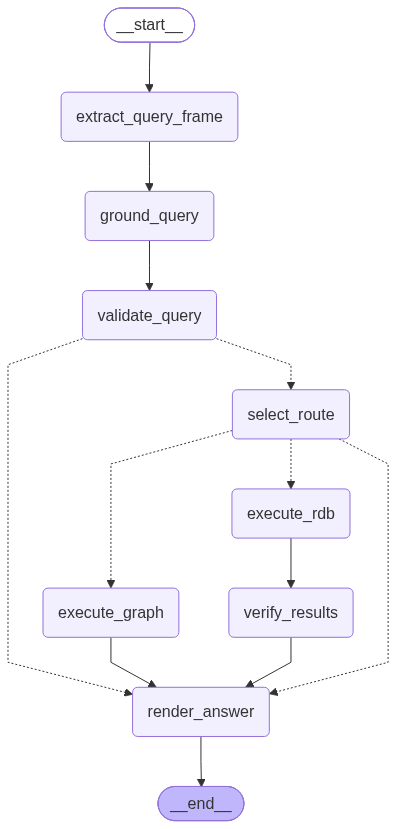

In [29]:
from IPython.display import Image,Markdown, display
from agent.agent_core import APP


# 컴파일된 LangGraph 가져오기
agent_graph = APP.get_graph()


try:
    png_bytes = agent_graph.draw_mermaid_png()

    ## 이미지 출력
    display(Image(png_bytes))

    ## 이미지 저장 (아래 주석 코드 해제하면 graph.png로 저장됨)
    # with open("graph.png", "wb") as f:
    #     f.write(png_bytes)

    # print("graph.png로 저장됨")
except Exception as e:
    print("PNG 렌더링 실패 (인터넷 연결 또는 방화벽 문제일 수 있음):", e)
    print("위쪽의 mermaid 텍스트나 draw_ascii() 결과를 대신 쓰시면 됩니다.")

# 노드별 테스트

- 아래는 LangGraph 를 거치지 않고 노드 함수를 하나씩 실행하는 셀이다.
- 위의 모듈 셀을 수정했다면 해당 셀 → `agent.nodes` 셀 → 여기 순서로 재실행한다.

그래프 흐름: 
- extract_query_frame → ground_query → validate_query →(abstain 이면 render_answer) → select_route → execute_rdb 또는 execute_graph(route 에 따라) → verify_results → render_answer


In [30]:
from agent import nodes as N

TEST_QUESTION = "에코프로와 연결된 자회사 관계를 알려줘. 관계 기준일과 출처도 함께 보여줘"  
TEST_QUESTION = "KODEX200이 국내 ETF 데이터와 공모펀드 데이터에 모두 나타나는 이유를 설명해줘. 동일 운용상품, 상장 클래스, 별도 상품 중 무엇인지 상품번호·대표종목번호·상장 여부 관계를 근거로 판정해줘." 
# TEST_QUESTION = "캠브리콘이 실제 편입된 중국 반도체 ETF를 찾아줘. ETF→편입증권→기업 경로를 사용하고, ETF명·티커·편입비중·편입기준일·편입내역 문서명과 근거 문장을 제시해줘."  


## 최초 state class 정의
state = {"question_id" : "test" , 
         "question": TEST_QUESTION,
         "intent": {}, # extract_query_frame 노드
         "metadata_context": {}, # ground_query 노드 - (1)
         "plan": {},   # ground_query 노드 - (2)
         "route": {},   # select_route 노드
         "results": {},  # execute_rdb / execute_graph 노드 - (1)
         "evidence": [], # execute_rdb / execute_graph 노드 - (2)
         "abstain": None, # validate_query 노드 - state["abstain"] 이 있으면 이후는 render_answer 로 직행
         "trace": [], # 노드가 남기는 관측 기록 -  주최측 규격의 think_trace
         "answer": ""} # render_answer 노드 - 최종 답변

In [31]:
out = N.extract_query_frame(state); state.update(out); out

{'intent': {'domain_candidates': ['etf_kr', 'fund_pub'],
  'task': 'explanation',
  'targets': [{'text': '국내 ETF'}, {'text': '공모펀드'}],
  'entities': [{'text': 'KODEX200', 'role': 'product', 'match_mode': 'exact'}],
  'requested_fields': [{'text': '상품번호'},
   {'text': '대표종목번호'},
   {'text': '상장 여부'}],
  'constraints': [],
  'relations': [],
  'ordering': [],
  'limit': None,
  'temporal': {'kind': 'latest_snapshot',
   'raw': None,
   'as_of_text': None,
   'window_text': None},
  'computation': [],
  'evidence_requirements': ['상품번호', '대표종목번호', '상장 여부'],
  'ambiguity': [],
  'validation_targets': [],
  '_guard': [],
  '_raw': {'domain_candidates': ['etf_kr', 'fund_pub'],
   'task': 'explanation',
   'targets': [{'text': '국내 ETF'}, {'text': '공모펀드'}],
   'entities': [{'text': 'KODEX200',
     'role': 'product',
     'match_mode': 'exact'}],
   'requested_fields': [{'text': '상품번호'},
    {'text': '대표종목번호'},
    {'text': '상장 여부'}],
   'constraints': [],
   'relations': [],
   'ordering': [],

In [32]:
out = N.ground_query(state); state.update(out); out

{'metadata_context': {'engine': 'graph',
  'domain': None,
  'unresolved': [],
  'concepts': [],
  'entities': [{'text': 'KODEX200',
    'role': 'product',
    'match_mode': 'exact'}]},
 'plan': {'engine': 'graph',
  'domain': None,
  'unresolved': [],
  'concepts': [],
  'entities': [{'text': 'KODEX200',
    'role': 'product',
    'match_mode': 'exact'}]},
 'trace': ["intent: task=explanation domain=['etf_kr', 'fund_pub'] entities=1 constraints=0",
  'grounding: domain=None concepts=[] unresolved=0']}

In [33]:
out = N.validate_query(state); state.update(out); out
# state["abstain"] 이 있으면 이후는 render_answer 로 직행하는 경로다

{'abstain': None,
 'trace': ["intent: task=explanation domain=['etf_kr', 'fund_pub'] entities=1 constraints=0",
  'grounding: domain=None concepts=[] unresolved=0',
  'validation: PASS']}

In [34]:
out = N.select_route(state); state.update(out); out

{'route': {'query_type': 'graph_only',
  'execution_plan': [{'id': 'G1',
    'engine': 'graph',
    'operation': 'generic_text2sparql',
    'mode': 'schema_grounded',
    'depends_on': []}],
  'reason': 'non-subsidiary relation request; schema-grounded Text2SPARQL'},
 'abstain': None,
 'trace': ["intent: task=explanation domain=['etf_kr', 'fund_pub'] entities=1 constraints=0",
  'grounding: domain=None concepts=[] unresolved=0',
  'validation: PASS',
  'route: graph_only steps=1 — non-subsidiary relation request; schema-grounded Text2SPARQL']}

In [35]:
out = N.execute_graph(state); state.update(out); out
# route 가 graph_only / graph_then_rdb 일 때만 의미 있음

{'results': {'status': 'abstain_invalid_graph_plan',
  'rows': [],
  'entity': {'status': 'resolved',
   'text': 'KODEX200',
   'expected_class': 'http://mafest.ai/product#ETF',
   'candidates': [{'uri': 'http://mafest.ai/instance/etfkr-KR7069500007',
     'class_uri': 'http://mafest.ai/product#ETF',
     'canonical_name': 'KODEX 200',
     'names': ('KODEX 200', '삼성 KODEX200 증권상장지수투자신탁[주식]'),
     'codes': ('KR7069500007',)}],
   'uri': 'http://mafest.ai/instance/etfkr-KR7069500007',
   'class_uri': 'http://mafest.ai/product#ETF',
   'canonical_name': 'KODEX 200',
   'names': ('KODEX 200', '삼성 KODEX200 증권상장지수투자신탁[주식]'),
   'codes': ('KR7069500007',),
   'match_mode': 'normalized_literal_exact'},
  'schema_fragment': {'seed_classes': ['http://mafest.ai/product#ETF',
    'http://mafest.ai/product#PublicFund',
    'http://mafest.ai/product#Product',
    'http://mafest.ai/product#Security'],
   'classes': ['http://mafest.ai/product#AssetManager',
    'http://mafest.ai/product#AssetType',


In [ ]:
# out = N.verify_results(state); state.update(out); out

{}

In [36]:
out = N.render_answer(state); state.update(out)
print(state["answer"])

[render_answer] 시작
[render_answer] state keys: ['question_id', 'question', 'intent', 'metadata_context', 'plan', 'route', 'results', 'evidence', 'abstain', 'trace', 'answer']
[render_answer] abstain: {'code': 'ABSTAIN_INVALID_GRAPH_PLAN', 'reason': 'schema: mode=lexical_fallback+explicit classes=18 properties=60 candidate_paths=8'}
[render_answer] route: {'query_type': 'graph_only', 'execution_plan': [{'id': 'G1', 'engine': 'graph', 'operation': 'generic_text2sparql', 'mode': 'schema_grounded', 'depends_on': []}], 'reason': 'non-subsidiary relation request; schema-grounded Text2SPARQL'}
[render_answer] 1. abstain 검사
[render_answer] abstain 응답 생성: {'code': 'ABSTAIN_INVALID_GRAPH_PLAN', 'reason': 'schema: mode=lexical_fallback+explicit classes=18 properties=60 candidate_paths=8'}
확인할 수 없음: schema: mode=lexical_fallback+explicit classes=18 properties=60 candidate_paths=8


# 노드별 테스트

- 아래는 LangGraph 를 거치지 않고 노드 함수를 하나씩 실행하는 셀이다.
- 위의 모듈 셀을 수정했다면 해당 셀 → `agent.nodes` 셀 → 여기 순서로 재실행한다.

그래프 흐름: 
- extract_query_frame → ground_query → validate_query →(abstain 이면 render_answer) → select_route → execute_rdb 또는 execute_graph(route 에 따라) → verify_results → render_answer


In [42]:
from agent import nodes as N

TEST_QUESTION = "에코프로와 연결된 자회사 관계를 알려줘. 관계 기준일과 출처도 함께 보여줘"  
# TEST_QUESTION = "KODEX200이 국내 ETF 데이터와 공모펀드 데이터에 모두 나타나는 이유를 설명해줘. 동일 운용상품, 상장 클래스, 별도 상품 중 무엇인지 상품번호·대표종목번호·상장 여부 관계를 근거로 판정해줘." 
# TEST_QUESTION = "캠브리콘이 실제 편입된 중국 반도체 ETF를 찾아줘. ETF→편입증권→기업 경로를 사용하고, ETF명·티커·편입비중·편입기준일·편입내역 문서명과 근거 문장을 제시해줘."  


## 최초 state class 정의
state = {"question_id" : "test" , 
         "question": TEST_QUESTION,
         "intent": {}, # extract_query_frame 노드
         "metadata_context": {}, # ground_query 노드 - (1)
         "plan": {},   # ground_query 노드 - (2)
         "route": {},   # select_route 노드
         "results": {},  # execute_rdb / execute_graph 노드 - (1)
         "evidence": [], # execute_rdb / execute_graph 노드 - (2)
         "abstain": None, # validate_query 노드 - state["abstain"] 이 있으면 이후는 render_answer 로 직행
         "trace": [], # 노드가 남기는 관측 기록 -  주최측 규격의 think_trace
         "answer": ""} # render_answer 노드 - 최종 답변

In [43]:
out = N.extract_query_frame(state); state.update(out); out

{'intent': {'domain_candidates': ['bond_kr', 'etf_kr', 'etf_gl', 'fund_pub'],
  'task': 'relation',
  'targets': [],
  'entities': [{'text': '에코프로', 'role': 'company', 'match_mode': 'exact'}],
  'requested_fields': [{'text': '관계 기준일'}, {'text': '출처'}],
  'constraints': [],
  'relations': [{'raw': '에코프로와 연결된 자회사 관계', 'path': ['기업', '자회사', '기업']},
   {'raw': '에코프로와 연결된 자회사 관계', 'path': ['기업', '계열사', '기업']}],
  'ordering': [],
  'limit': None,
  'temporal': {'kind': 'as_of',
   'raw': '관계 기준일',
   'as_of_text': '2023-09-01',
   'window_text': None},
  'computation': [],
  'evidence_requirements': ['관계 기준일', '출처'],
  'ambiguity': [],
  'validation_targets': [],
  '_guard': [],
  '_raw': {'domain_candidates': ['bond_kr', 'etf_kr', 'etf_gl', 'fund_pub'],
   'task': 'relation',
   'targets': [],
   'entities': [{'text': '에코프로', 'role': 'company', 'match_mode': 'exact'}],
   'requested_fields': [{'text': '관계 기준일'}, {'text': '출처'}],
   'constraints': [],
   'relations': [{'raw': '에코프로와 연결된 자회사 

In [45]:
out = N.ground_query(state); state.update(out); out

{'metadata_context': {'engine': 'graph',
  'domain': None,
  'unresolved': [],
  'concepts': [],
  'entities': [{'text': '에코프로', 'role': 'company', 'match_mode': 'exact'}]},
 'plan': {'engine': 'graph',
  'domain': None,
  'unresolved': [],
  'concepts': [],
  'entities': [{'text': '에코프로', 'role': 'company', 'match_mode': 'exact'}]},
 'trace': ["intent: task=relation domain=['bond_kr', 'etf_kr', 'etf_gl', 'fund_pub'] entities=1 constraints=0",
  'grounding: domain=None concepts=[] unresolved=0',
  'grounding: domain=None concepts=[] unresolved=0']}

In [46]:
out = N.validate_query(state); state.update(out); out
# state["abstain"] 이 있으면 이후는 render_answer 로 직행하는 경로다

{'abstain': None,
 'trace': ["intent: task=relation domain=['bond_kr', 'etf_kr', 'etf_gl', 'fund_pub'] entities=1 constraints=0",
  'grounding: domain=None concepts=[] unresolved=0',
  'grounding: domain=None concepts=[] unresolved=0',
  'validation: PASS']}

In [47]:
out = N.select_route(state); state.update(out); out

{'route': {'query_type': 'graph_only',
  'execution_plan': [{'id': 'G1',
    'engine': 'graph',
    'operation': 'subsidiaries',
    'mode': 'verified_fast_path',
    'depends_on': []}],
  'reason': 'verified company subsidiary Graph capability'},
 'abstain': None,
 'trace': ["intent: task=relation domain=['bond_kr', 'etf_kr', 'etf_gl', 'fund_pub'] entities=1 constraints=0",
  'grounding: domain=None concepts=[] unresolved=0',
  'grounding: domain=None concepts=[] unresolved=0',
  'validation: PASS',
  'route: graph_only steps=1 — verified company subsidiary Graph capability']}

In [41]:
out = N.execute_graph(state); state.update(out); out
# route 가 graph_only / graph_then_rdb 일 때만 의미 있음

{'results': {'status': 'abstain_invalid_graph_plan',
  'rows': [],
  'entity': {'status': 'resolved',
   'text': 'KODEX200',
   'expected_class': 'http://mafest.ai/product#ETF',
   'candidates': [{'uri': 'http://mafest.ai/instance/etfkr-KR7069500007',
     'class_uri': 'http://mafest.ai/product#ETF',
     'canonical_name': 'KODEX 200',
     'names': ('KODEX 200', '삼성 KODEX200 증권상장지수투자신탁[주식]'),
     'codes': ('KR7069500007',)}],
   'uri': 'http://mafest.ai/instance/etfkr-KR7069500007',
   'class_uri': 'http://mafest.ai/product#ETF',
   'canonical_name': 'KODEX 200',
   'names': ('KODEX 200', '삼성 KODEX200 증권상장지수투자신탁[주식]'),
   'codes': ('KR7069500007',),
   'match_mode': 'normalized_literal_exact'},
  'schema_fragment': {'seed_classes': ['http://mafest.ai/product#ETF',
    'http://mafest.ai/product#PublicFund',
    'http://mafest.ai/product#Security',
    'http://mafest.ai/product#Product'],
   'classes': ['http://mafest.ai/product#AssetManager',
    'http://mafest.ai/product#AssetType',


In [49]:
out = N.verify_results(state); state.update(out); out

{'abstain': None,
 'trace': ["intent: task=relation domain=['bond_kr', 'etf_kr', 'etf_gl', 'fund_pub'] entities=1 constraints=0",
  'grounding: domain=None concepts=[] unresolved=0',
  'grounding: domain=None concepts=[] unresolved=0',
  'validation: PASS',
  'route: graph_only steps=1 — verified company subsidiary Graph capability',
  'verify: PASS']}

In [50]:
out = N.render_answer(state); state.update(out)
print(state["answer"])

[render_answer] 시작
[render_answer] state keys: ['question_id', 'question', 'intent', 'metadata_context', 'plan', 'route', 'results', 'evidence', 'abstain', 'trace', 'answer']
[render_answer] abstain: None
[render_answer] route: {'query_type': 'graph_only', 'execution_plan': [{'id': 'G1', 'engine': 'graph', 'operation': 'subsidiaries', 'mode': 'verified_fast_path', 'depends_on': []}], 'reason': 'verified company subsidiary Graph capability'}
[render_answer] 1. abstain 검사
[render_answer] 2. query_type=graph_only
[render_answer] 3. _render_graph_answer 호출 직전
[render_answer] 4. _render_graph_answer 완료
근거가 완비된 관계를 확인할 수 없습니다.


## 전체 그래프 E2E

### 1. 단일 질문 테스트

In [51]:
from agent.agent_core import ask

resp = ask(TEST_QUESTION)
resp

[render_answer] 시작
[render_answer] state keys: ['question_id', 'question', 'intent', 'metadata_context', 'plan', 'route', 'results', 'evidence', 'abstain', 'trace', 'answer']
[render_answer] abstain: None
[render_answer] route: {'query_type': 'graph_only', 'execution_plan': [{'id': 'G1', 'engine': 'graph', 'operation': 'subsidiaries', 'mode': 'verified_fast_path', 'depends_on': []}], 'reason': 'verified company subsidiary Graph capability'}
[render_answer] 1. abstain 검사
[render_answer] 2. query_type=graph_only
[render_answer] 3. _render_graph_answer 호출 직전
[render_answer] 4. _render_graph_answer 완료


{'question_id': '',
 'question': '에코프로와 연결된 자회사 관계를 알려줘. 관계 기준일과 출처도 함께 보여줘',
 'retrieved_context': [{'row': 0,
   'relation_as_of': '2026-03-18',
   'relation_source': 'DART:otrCprInvstmntSttus',
   'relation_document': 'http://mafest.ai/instance/doc-b6ef81e0e87becc35e69',
   'relation_document_title': '에코프로 2025 사업보고서 타법인 출자현황'},
  {'row': 1,
   'relation_as_of': '2026-03-18',
   'relation_source': 'DART:otrCprInvstmntSttus',
   'relation_document': 'http://mafest.ai/instance/doc-85f526ed9842b4cb469f',
   'relation_document_title': '에코프로 2025 사업보고서 타법인 출자현황'},
  {'row': 2,
   'relation_as_of': '2026-03-18',
   'relation_source': 'DART:otrCprInvstmntSttus',
   'relation_document': 'http://mafest.ai/instance/doc-775811c714b9ca7f75f2',
   'relation_document_title': '에코프로 2025 사업보고서 타법인 출자현황'},
  {'row': 3,
   'relation_as_of': '2026-03-18',
   'relation_source': 'DART:otrCprInvstmntSttus',
   'relation_document': 'http://mafest.ai/instance/doc-db4cba05ee1cfd42a9e7',
   'relation_documen

### 2. 예상 질문 테스트

In [41]:
# Agent Test — 관계검색/시그널검색 E2E 검증
import json
import re
import time
from datetime import date

import pandas as pd
from IPython.display import display, Markdown

DATA_CUTOFF = date.fromisoformat("2026-08-24")
LATENCY_LIMIT_SECONDS = 15.0
RAISE_ON_FAILURE = False


TEST_CASES = [
    {
        "id": "q021",
        "title": "관계검색_상품동일성",
        "question": (
            "KODEX200이 국내 ETF 데이터와 공모펀드 데이터에 모두 나타나는 이유를 설명해줘. "
            "동일 운용상품, 상장 클래스, 별도 상품 중 무엇인지 상품번호·대표종목번호·"
            "상장 여부 관계를 근거로 판정해줘."
        ),
        "expected": "ANSWER",
        # 각 항목에서 토큰 하나 이상이 answer/context/trace에 있어야 통과
        "required_signals": {
            "상품번호": [
                "상품번호", "productCode", "product_code",
                "pd_itm_no", "itm_no", "ksdCode",
            ],
            "대표종목번호": [
                "대표종목번호", "representativeKsdCode",
                "representative_code", "rptt_ksd_itm_no",
                "managerItemCode", "mtco_itm_no",
            ],
            "상장 여부": [
                "상장 여부", "상장", "ETF",
            ],
            "상품 동일성 관계": [
                "sameVehicleAs", "SAME_VEHICLE_AS",
                "hasShareClass", "HAS_SHARE_CLASS",
                "동일 상품", "동일 운용상품",
            ],
        },
    },
    {
        "id": "q022",
        "title": "관계검색_기업ETF편입",
        "question": (
            "캠브리콘이 실제 편입된 중국 반도체 ETF를 찾아줘. "
            "ETF→편입증권→기업 경로를 사용하고, ETF명·티커·편입비중·편입기준일·"
            "편입내역 문서명과 근거 문장을 제시해줘."
        ),
        "expected": "ANSWER",
        "required_signals": {
            "기업 식별자": [
                "corpCode", "corp_code", "기업 식별자",
                "organizationName", "캠브리콘",
            ],
            "ETF→편입증권→기업 경로": [
                "hasHolding", "holdingSecurity", "issuedByCompany",
                "편입증권", "편입종목", "발행기업",
            ],
            "ETF 식별정보": [
                "ETF명", "etf_name", "productShortName",
                "티커", "ticker", "etf_code",
            ],
            "편입비중": [
                "편입비중", "weight",
            ],
            "편입기준일": [
                "편입기준일", "holding_as_of", "asOf", "기준일",
            ],
            "근거 문서": [
                "편입내역 문서명", "documentTitle",
                "document_title", "근거문서",
            ],
            "근거 문장": [
                "documentQuote", "document_quote",
                "근거 문장", "인용문", "quote",
            ],
        },
    },
    {
        "id": "q023",
        "title": "시그널검색_기간테마연결",
        "question": (
            "최근 6개월 동안 우주항공 테마와 연결된 이력이 있는 ETF를 정리해줘. "
            "현재 편입 관계와 단순 뉴스 언급을 구분하고, "
            "ETF→편입기업→산업/테마→근거문서 경로, 사건일, 문서명과 인용 근거를 제시해줘."
        ),
        "expected": "ANSWER",
        "required_signals": {
            "6개월 기준구간": [
                "최근 6개월", "6개월 기준구간",
                "기간 시작", "period", "window",
            ],
            "편입과 언급 구분": [
                "현재 편입", "실제 편입", "단순 뉴스 언급",
                "단순 언급", "relation_vs_mention",
            ],
            "테마 Graph 경로": [
                "hasHolding", "holdingSecurity", "issuedByCompany",
                "relatedToTheme", "belongsToIndustry",
                "우주항공", "테마",
            ],
            "사건일": [
                "사건일", "event_date", "documentPublishedDate",
                "document_date", "published_date",
            ],
            "근거 문서": [
                "문서명", "documentTitle",
                "document_title", "근거문서",
            ],
            "인용 근거": [
                "인용 근거", "인용문", "documentQuote",
                "document_quote", "quote",
            ],
        },
    },
]


ABSTAIN_MARKERS = (
    "확인할 수 없음",
    "확인할 수 없습니다",
    "지원하지",
    "ABSTAIN",
)


def stringify(value):
    """answer, evidence, trace를 검색 가능한 단일 문자열로 변환."""
    return json.dumps(
        value,
        ensure_ascii=False,
        default=str,
        sort_keys=True,
    )


def extract_route(trace):
    """think_trace에서 최종 route 문자열 추출."""
    for item in trace or []:
        text = str(item)
        if text.startswith("route:"):
            return text
    return "route 확인 불가"


def find_future_dates(text):
    """응답에 cutoff 이후 날짜가 섞였는지 검사."""
    future = []
    for raw in re.findall(r"(?<!\d)(20\d{2}-\d{2}-\d{2})(?!\d)", text):
        try:
            parsed = date.fromisoformat(raw)
        except ValueError:
            continue
        if parsed > DATA_CUTOFF:
            future.append(raw)
    return sorted(set(future))


def evaluate_signals(search_text, required_signals):
    checks = {}
    matched_tokens = {}

    for label, alternatives in required_signals.items():
        hits = [
            token for token in alternatives
            if token.casefold() in search_text.casefold()
        ]
        checks[label] = bool(hits)
        matched_tokens[label] = hits

    return checks, matched_tokens


def run_case(case):
    started = time.perf_counter()

    try:
        response = ask(
            case["question"],
            question_id=case["id"],
        )
        error = None
    except Exception as exc:
        response = {
            "question_id": case["id"],
            "question": case["question"],
            "retrieved_context": [],
            "think_trace": [],
            "answer": "",
        }
        error = f"{type(exc).__name__}: {exc}"

    latency = time.perf_counter() - started
    answer = str(response.get("answer") or "")
    context = response.get("retrieved_context") or []
    trace = response.get("think_trace") or []

    combined = stringify({
        "answer": answer,
        "retrieved_context": context,
        "think_trace": trace,
    })

    abstained = (
        error is not None
        or not answer.strip()
        or any(marker.casefold() in combined.casefold()
               for marker in ABSTAIN_MARKERS)
    )
    answered = not abstained

    signal_checks, matched_tokens = evaluate_signals(
        combined,
        case["required_signals"],
    )
    missing_signals = [
        label for label, passed in signal_checks.items()
        if not passed
    ]

    future_dates = find_future_dates(combined)
    behavior_pass = (
        answered if case["expected"] == "ANSWER"
        else abstained
    )
    evidence_pass = all(signal_checks.values())
    latency_pass = latency <= LATENCY_LIMIT_SECONDS
    cutoff_pass = not future_dates

    overall_pass = (
        behavior_pass
        and evidence_pass
        and latency_pass
        and cutoff_pass
        and error is None
    )

    return {
        "id": case["id"],
        "title": case["title"],
        "expected": case["expected"],
        "actual": "ANSWER" if answered else "ABSTAIN",
        "route": extract_route(trace),
        "rows_or_evidence": len(context),
        "latency_sec": round(latency, 3),
        "behavior_pass": behavior_pass,
        "evidence_pass": evidence_pass,
        "latency_pass": latency_pass,
        "cutoff_pass": cutoff_pass,
        "overall_pass": overall_pass,
        "missing_signals": missing_signals,
        "matched_tokens": matched_tokens,
        "future_dates": future_dates,
        "error": error,
        "answer": answer,
        "trace": trace,
        "retrieved_context": context,
    }


results = []

for case in TEST_CASES:
    print(f"\n{'=' * 100}")
    print(f"[{case['id']}] {case['title']}")
    print(case["question"])

    result = run_case(case)
    results.append(result)

    print(f"\nroute   : {result['route']}")
    print(f"actual  : {result['actual']}")
    print(f"latency : {result['latency_sec']:.3f}s")
    print(f"evidence: {'PASS' if result['evidence_pass'] else 'FAIL'}")
    print(f"overall : {'PASS' if result['overall_pass'] else 'FAIL'}")

    if result["missing_signals"]:
        print("누락 근거:", ", ".join(result["missing_signals"]))

    if result["future_dates"]:
        print("cutoff 이후 날짜:", result["future_dates"])

    if result["error"]:
        print("실행 오류:", result["error"])

    display(Markdown("### Answer"))
    print(result["answer"] or "(빈 응답)")

    display(Markdown("### Think Trace"))
    for trace_item in result["trace"]:
        print("-", trace_item)

    display(Markdown("### Retrieved Context"))
    context_preview = stringify(result["retrieved_context"])
    print(context_preview[:5000])
    if len(context_preview) > 5000:
        print("... retrieved_context 출력 생략")


summary = pd.DataFrame([
    {
        "id": result["id"],
        "type": result["title"],
        "expected": result["expected"],
        "actual": result["actual"],
        "route": result["route"],
        "latency_sec": result["latency_sec"],
        "behavior": "PASS" if result["behavior_pass"] else "FAIL",
        "evidence": "PASS" if result["evidence_pass"] else "FAIL",
        "cutoff": "PASS" if result["cutoff_pass"] else "FAIL",
        "overall": "PASS" if result["overall_pass"] else "FAIL",
        "missing": ", ".join(result["missing_signals"]),
        "error": result["error"],
    }
    for result in results
])

display(Markdown("## Agent Test Summary"))
display(summary)

passed = int(summary["overall"].eq("PASS").sum())
print(f"\n최종 결과: {passed}/{len(summary)} PASS")

if RAISE_ON_FAILURE:
    failures = summary[summary["overall"] != "PASS"]
    assert failures.empty, failures[
        ["id", "route", "actual", "missing", "error"]
    ].to_dict("records")


[q021] 관계검색_상품동일성
KODEX200이 국내 ETF 데이터와 공모펀드 데이터에 모두 나타나는 이유를 설명해줘. 동일 운용상품, 상장 클래스, 별도 상품 중 무엇인지 상품번호·대표종목번호·상장 여부 관계를 근거로 판정해줘.

route   : route 확인 불가
actual  : ABSTAIN
latency : 2.766s
evidence: FAIL
overall : FAIL
누락 근거: 상품번호, 대표종목번호, 상품 동일성 관계


### Answer

확인할 수 없음: domain 후보를 하나로 확정할 수 없음: ['fund_pub', 'etf_kr']


### Think Trace

- intent: task=explanation domain=['etf_kr', 'fund_pub'] entities=1 constraints=0
- grounding: domain=None concepts=[] unresolved=1
- validation: ABSTAIN_UNRESOLVED_QUERY


...

### Retrieved Context

[]


## Agent Test Summary

,id,type,expected,actual,route,latency_sec,behavior,evidence,cutoff,overall,missing,error
0,q021,관계검색_상품동일성,ANSWER,ABSTAIN,route 확인 불가,2.766,FAIL,FAIL,PASS,FAIL,"상품번호, 대표종목번호, 상품 동일성 관계",None
1,q022,관계검색_기업ETF편입,ANSWER,ABSTAIN,route: unsupported steps=0 — 검증된 Graph capabil...,3.402,FAIL,FAIL,PASS,FAIL,"기업 식별자, ETF→편입증권→기업 경로, ETF 식별정보, 편입비중, 편입기준일,...",None
2,q023,시그널검색_기간테마연결,ANSWER,ABSTAIN,route 확인 불가,5.085,FAIL,FAIL,PASS,FAIL,"6개월 기준구간, 편입과 언급 구분, 테마 Graph 경로, 사건일, 근거 문서, ...",None



최종 결과: 0/3 PASS


## .py 반영

셀 수정 후 **노트북 저장(Ctrl+S)** → 아래 실행.

In [ ]:
# def sync_to_py(dry_run=True):
#     """노트북의 %%module 셀들을 src/*.py 로 되쓴다. 먼저 노트북을 저장(Ctrl+S)할 것.

#     dry_run=True 면 diff 여부만 보여준다. 실제 반영은 sync_to_py(dry_run=False).
#     """
#     nb = _json.loads(NB_PATH.read_text(encoding="utf-8"))
#     for c in nb["cells"]:
#         src = "".join(c["source"])
#         if c["cell_type"] != "code" or not src.startswith("%%module "):
#             continue
#         first, _, body = src.partition("\n")
#         _, name, relpath = first.split()
#         target = REPO_ROOT / "src" / relpath
#         old = target.read_text(encoding="utf-8")
#         if old == body:
#             print(f"  same: {relpath}")
#         elif dry_run:
#             print(f"CHANGED: {relpath}  (dry_run — 반영하려면 sync_to_py(dry_run=False))")
#         else:
#             target.write_text(body, encoding="utf-8")
#             print(f"WROTE: {relpath}")


# sync_to_py()                # diff 확인
# sync_to_py(dry_run=False)   # 실제 반영